In [1]:
from __future__ import (absolute_import, division,
                        print_function, unicode_literals)

import warnings
warnings.simplefilter('ignore')

# general purpose packages
import pandas as pd
import numpy as np
import os
import json
import time
import re
import csv
import subprocess
import sys

import scipy.stats as stats
import statsmodels.stats as smstats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from multiprocessing import Process, Manager, Pool
import multiprocessing
from functools import partial

from collections import Counter

import seaborn as sns; sns.set()

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.rcParams['backend'] = "Qt5Agg"
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

from IPython.display import display, Image

import builtins
%matplotlib inline

# from statsmodels.regression.quantile_regression import QuantReg

# for working with sam/bam files
import pysam
import HTSeq

# for working with ONT files
import pod5 as p5

# for adjusting text locations
from adjustText import adjust_text

import itertools

In [2]:
# paths to subdirectories
subdirs = {}

subdirs['main_project_dir'] = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/'
subdirs['wf_dir'] = '/scicore/home/zavolan/mirono0000/Projects/Regulation_of_gastrulation/WF/'

subdirs['human_annotation_dir'] = '/scicore/home/zavolan/GROUP/Genomes/homo_sapiens/'
subdirs['mouse_annotation_dir'] = '/scicore/home/zavolan/GROUP/Genomes/mus_musculus/'

# shared project folder 
subdirs['shared_project_dir'] = subdirs['main_project_dir']
subdirs['temp_dir'] = subdirs['shared_project_dir']+'temp_dir/'
subdirs['slurm_dir'] = subdirs['temp_dir']+'slurm/'
subdirs['slurm_scripts_dir'] = subdirs['shared_project_dir']+'scripts/'
subdirs['figures_dir'] = subdirs['shared_project_dir']+'figures/'
subdirs['tables_dir'] = subdirs['shared_project_dir']+'tables/'
subdirs['fastq_dir'] = subdirs['shared_project_dir']+'input_fastq/'
subdirs['toy_dir'] = subdirs['shared_project_dir']+'toy/'
subdirs['pod5_dir'] = subdirs['shared_project_dir']+'input_pod5/'
subdirs['dorado_models_dir'] = subdirs['shared_project_dir']+'dorado/basecalling_models/'
subdirs['metadata_dir'] = subdirs['shared_project_dir']+'metadata/'

subdirs['wf_runs_dir'] = subdirs['shared_project_dir']+'wf_runs/'

subdirs['other_experiments'] = subdirs['main_project_dir']+'other_experiments/'

# paths to files
file_paths = {}
### genome annotation files
file_paths['human_genome_file'] = subdirs['human_annotation_dir']+'GRCh38.primary_assembly.genome.fa'
file_paths['human_genome_fai_file'] = subdirs['human_annotation_dir']+'GRCh38.primary_assembly.genome.fa.fai'
file_paths['human_annotation_file'] = subdirs['human_annotation_dir']+'hg38_v42/gencode.v42.annotation.gtf'
file_paths['human_basic_annotation_file'] = subdirs['human_annotation_dir']+'hg38_v42/gencode.v42.basic.annotation.gtf'
file_paths['human_RNAcentral_annotation_file'] = subdirs['human_annotation_dir']+'hg38_v42/homo_sapiens.GRCh38.gff3.gz'
file_paths['human_enriched_annotation_file'] = subdirs['human_annotation_dir']+'hg38_v42/enriched.gencode.v42.annotation.gtf'
file_paths['human_exonic_segments_gtf'] = subdirs['human_annotation_dir']+'hg38_v42/gencode.v42.exonic_segments.gtf'
file_paths['human_gene_type_segments_gtf'] = subdirs['human_annotation_dir']+'hg38_v42/gencode.v42.gene_type_segments.gtf'

file_paths['mouse_genome_file'] = subdirs['mouse_annotation_dir']+'GRCm38.primary_assembly.genome.fa'
file_paths['mouse_genome_fai_file'] = subdirs['mouse_annotation_dir']+'GRCm38.primary_assembly.genome.fa.fai'
file_paths['mouse_annotation_file'] = subdirs['mouse_annotation_dir']+'gencode.vM25.annotation.gtf'
file_paths['mouse_basic_annotation_file'] = subdirs['mouse_annotation_dir']+'gencode.vM25.basic.annotation.gtf'
file_paths['mouse_exonic_segments_gtf'] = subdirs['mouse_annotation_dir']+'gencode.vM25.exonic_segments.gtf'
file_paths['mouse_gene_type_segments_gtf'] = subdirs['mouse_annotation_dir']+'gencode.vM25.gene_type_segments.gtf'

file_paths['human_polyAsite_atlas'] = subdirs['human_annotation_dir']+'hg38_v42/atlas.clusters.3.0.GRCh38.GENCODE_42.bed.gz'
file_paths['human_tandem_PAS'] = subdirs['human_annotation_dir']+'hg38_v42/atlas.clusters.3.0.GRCh38.GENCODE_42.terminal_exons.bed'

file_paths['mouse_polyAsite_atlas'] = subdirs['mouse_annotation_dir']+'atlas.clusters.3.0.GRCm38.GENCODE_M25.bed.gz'
file_paths['mouse_tandem_PAS'] = subdirs['mouse_annotation_dir']+'atlas.clusters.3.0.GRCm38.GENCODE_M25.terminal_exons.bed'

os.system('mkdir -p '+' '.join(list(subdirs.values()))) # create all subdirs

0

In [3]:
def get_pvalue_star(pval, thr=0.05):
    if thr == 0.05:
        if pval < 0.001:
            return "***"
        elif pval < 0.01:
            return "**"
        elif pval < 0.05:
            return "*"
        else:
            return "NS"
    elif thr == 0.1:
        if pval < 0.001:
            return "***"
        elif pval < 0.01:
            return "**"
        elif pval < 0.1:
            return "*"
        else:
            return "NS"

In [4]:
# mamba create -c conda-forge -c bioconda -n nanopore python=3.12
# mamba activate nanopore
# mamba install bioconda::lib-pod5 conda-forge::ipykernel conda-forge::pandas conda-forge::scipy conda-forge::seaborn conda-forge::scikit-learn bioconda::samtools bioconda::pysam bioconda::htseq bioconda::bedtools -y
# pip install pod5

# Nanopore sequencing playing around

In [6]:
metadata = pd.DataFrame([
    ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b'],    
    ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842'],
    ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e'],
    ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2'],
           ],columns=['sample','bio_id','file_id'])
metadata

,sample,bio_id,file_id
0,Cnot8_KO_1,p32592_o35831_1,20240813_1724_X1_FAZ60491_8451cb8b
1,Cnot8_KO_2,p32592_o35831_2,20240813_1749_X2_FAZ60547_f5851842
2,CTRL_1,p32592_o35831_3,20240813_1749_X3_FAZ60875_f215937e
3,CTRL_2,p32592_o35831_4,20240813_1749_X4_FAZ61052_010889e2


## first, map last 300 nt with STAR to get some candidate reads to play around

In [37]:
###
# get last 300 nt with seqkit
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

command = ''
command = command+'mkdir -p '+general_output_dir+'; '

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    cur_output_dir = general_output_dir+'3ends_of_fastq_reads/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    
    fastq_file = subdirs['fastq_dir']+'nanopore/'+row['file_id']+'.pass.fastq.gz'
    out_file = cur_output_dir+sample+'.fastq.gz'
    command = command+'seqkit seq -m 300 '+fastq_file+' | seqkit subseq -r -300:-1 | seqkit seq --rna2dna | gzip > '+out_file+' & '
        
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/; mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/3ends_of_fastq_reads/; seqkit seq -m 300 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz | seqkit subseq -r -300:-1 | seqkit seq --rna2dna | gzip > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/3ends_of_fastq_reads/Cnot8_KO_1.fastq.gz & '

In [39]:
###
# run FastQC
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

threads = 12
command = ''
command = command+'mkdir -p '+general_output_dir+'; '

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    cur_output_dir = general_output_dir+'fastqc/3ends/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    
    fastq_file = general_output_dir+'3ends_of_fastq_reads/'+sample+'.fastq.gz'
    command = command+'fastqc --outdir '+cur_output_dir+' --threads '+str(threads)+' '+fastq_file+'; '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/; mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/fastqc/3ends/; fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/fastqc/3ends/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/3ends_of_fastq_reads/Cnot8_KO_1.fastq.gz; '

In [ ]:
mv /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/STAR_index /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/STAR_index

In [41]:
###
# Create genome reference for STAR
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

genome_file = file_paths['mouse_genome_file']
gtf_file = file_paths['mouse_annotation_file']
star_index = general_output_dir+'STAR_index'

command = 'STAR \
--runMode genomeGenerate \
--sjdbOverhang 299 \
--genomeDir '+star_index+' \
--genomeFastaFiles '+genome_file+' \
--runThreadN 12 \
--sjdbGTFfile '+gtf_file
command

'STAR --runMode genomeGenerate --sjdbOverhang 299 --genomeDir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/STAR_index --genomeFastaFiles /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa --runThreadN 12 --sjdbGTFfile /scicore/home/zavolan/GROUP/Genomes/mus_musculus/gencode.vM25.annotation.gtf'

In [60]:
###
# map with STAR
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
star_index = general_output_dir+'STAR_index'

threads = 12

command = ''

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    fastq_file = general_output_dir+'3ends_of_fastq_reads/'+sample+'.fastq.gz'
    bam_prefix = general_output_dir+'bam/STAR/'+sample+'_'
    command = command+'mkdir -p '+general_output_dir+'bam/STAR/; '
    bam_file = bam_prefix+'Aligned.sortedByCoord.out.bam'
    bam_uniquely_mapped = bam_prefix+'Aligned.uniquely_mapped.bam'
    command = command+'STAR \
--runMode alignReads \
--alignEndsType Local \
--runThreadN '+str(threads)+' \
--genomeDir '+star_index+' \
--readFilesIn '+fastq_file+' \
--readFilesCommand zcat \
--outFileNamePrefix '+bam_prefix+' \
--genomeLoad NoSharedMemory \
--outSAMtype BAM SortedByCoordinate \
--outFilterType BySJout \
--seedSearchStartLmax 20 \
--seedSearchStartLmaxOverLread 0.15 \
--outFilterMatchNmin 35 \
--outSJfilterOverhangMin 15 15 15 15 \
--alignSJDBoverhangMin 15 \
--alignSJoverhangMin 15 \
--outFilterMismatchNmax 15 \
--outFilterMismatchNoverReadLmax 1 \
--outFilterMatchNminOverLread 0 \
--outFilterScoreMinOverLread 0 \
--twopassMode None \
--outBAMsortingThreadN '+str(threads)+' \
--outFilterMultimapNmax 500000000 \
--outSAMattributes NH HI AS nM MD \
--limitOutSJcollapsed 5000000; '
    command = command+'samtools index -@ '+str(threads)+' '+bam_file+'; '
    command = command+'samtools view -h -q 255 -u -@ '+str(threads)+' '+bam_file+' | \
samtools sort -@ '+str(threads)+' -o '+bam_uniquely_mapped+'; \
samtools index -@ '+str(threads)+' '+bam_uniquely_mapped+'; '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/STAR/; STAR --runMode alignReads --alignEndsType Local --runThreadN 12 --genomeDir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/STAR_index --readFilesIn /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/3ends_of_fastq_reads/Cnot8_KO_1.fastq.gz --readFilesCommand zcat --outFileNamePrefix /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/STAR/Cnot8_KO_1_ --genomeLoad NoSharedMemory --outSAMtype BAM SortedByCoordinate --outFilterType BySJout --seedSearchStartLmax 20 --seedSearchStartLmaxOverLread 0.15 --outFilterMatchNmin 35 --outSJfilterOverhangMin 15 15 15 15 --alignSJDBoverhangMin 15 --alignSJoverhangMin 15 --outFilterMismatchNmax 15 --outFilterMismatchNoverReadLmax 1 --outFilterMatchNminOverLread 0 --outFilterScoreMinOverLread 0 --twopassMode None --outBAMsortingThreadN 12 --outFilterMultimapNmax 500000000 

In [63]:
###
# map with minimap2
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'


threads = 12

command = ''

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    fastq_file = general_output_dir+'3ends_of_fastq_reads/'+sample+'.fastq.gz'
    cur_output_dir = general_output_dir+'bam/minimap2/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    bam_file = general_output_dir+'bam/minimap2/'+sample+'.custom.bam'
    sorted_bam_file = general_output_dir+'bam/minimap2/'+sample+'.custom.sorted.bam'
#     command = command+'minimap2 -t '+str(threads)+' -ax map-ont -L -Q -secondary=no --sam-hit-only '+file_paths['mouse_genome_file']+' '+fastq_file+' | samtools view -@ '+str(threads)+' -b - -o '+bam_file+'; '+\
# 'samtools sort -@ '+str(threads)+' -o '+sorted_bam_file+' '+bam_file+' && samtools index -@ '+str(threads)+' '+sorted_bam_file
    command = command+'minimap2 -t '+str(threads)+' -ax splice -L -Q  -Y -y -2 -secondary=no --sam-hit-only '+file_paths['mouse_genome_file']+' '+fastq_file+' | samtools view -@ '+str(threads)+' -b - -o '+bam_file+'; '+\
'samtools sort -@ '+str(threads)+' -o '+sorted_bam_file+' '+bam_file+' && samtools index -@ '+str(threads)+' '+sorted_bam_file+'; '

command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2/; minimap2 -t 12 -ax splice -L -Q  -Y -y -2 -N 0 -secondary=no --sam-hit-only /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/3ends_of_fastq_reads/Cnot8_KO_1.fastq.gz | samtools view -@ 12 -b - -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2/Cnot8_KO_1.custom.bam; samtools sort -@ 12 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2/Cnot8_KO_1.custom.sorted.bam /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2/Cnot8_KO_1.custom.bam && samtools index -@ 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2/Cnot8_KO_1.custom.sorted.bam; '

In [77]:
###
# map with minimap2 full reads
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'


threads = 12

command = ''

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    fastq_file = subdirs['fastq_dir']+'nanopore/'+row['file_id']+'.pass.fastq.gz'
    cur_output_dir = general_output_dir+'bam/minimap2_full/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    bam_file = general_output_dir+'bam/minimap2_full/'+sample+'.bam'
    sorted_bam_file = general_output_dir+'bam/minimap2_full/'+sample+'.sorted.bam'
    sorted_bam_file_no_secondary = general_output_dir+'bam/minimap2_full/'+sample+'.sorted.no_secondary.bam'
    command = command+'minimap2 -t '+str(threads)+' -ax splice -L -Q  -Y -y -2 -secondary=no --sam-hit-only '+file_paths['mouse_genome_file']+' '+fastq_file+' | samtools view -@ '+str(threads)+' -b - -o '+bam_file+'; '+\
'samtools sort -@ '+str(threads)+' -o '+sorted_bam_file+' '+bam_file+' && samtools index -@ '+str(threads)+' '+sorted_bam_file+'; '
    command = command+'samtools view -@ '+str(threads)+' -q 1 -F 0x100 -b -u '+sorted_bam_file+' | samtools sort -@ '+str(threads)+' -o '+sorted_bam_file_no_secondary+' && samtools index -@ '+str(threads)+' '+sorted_bam_file_no_secondary+'; '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2_full/; samtools view -@ 12 -q 1 -F 0x100 -b -u /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2_full/Cnot8_KO_1.sorted.bam | samtools sort -@ 12 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2_full/Cnot8_KO_1.sorted.no_secondary.bam && samtools index -@ 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2_full/Cnot8_KO_1.sorted.no_secondary.bam; '

In [78]:
###
# fastqc on STAR-mapped and minimap-mapped reads 
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

threads = 12
command = ''
command = command+'mkdir -p '+general_output_dir+'; '

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    cur_output_dir = general_output_dir+'fastqc/STAR_mapped/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    
    # bam_prefix = general_output_dir+'bam/STAR/'+sample+'_'
    # bam_uniquely_mapped = bam_prefix+'Aligned.uniquely_mapped.bam'
    # command = command+'fastqc --outdir '+cur_output_dir+' --threads '+str(threads)+' '+bam_uniquely_mapped+'; '

    # cur_output_dir = general_output_dir+'fastqc/minimap_mapped/'
    # command = command+'mkdir -p '+cur_output_dir+'; '
    # bam_uniquely_mapped = general_output_dir+'bam/minimap2/'+sample+'.custom.sorted.bam'
    # command = command+'fastqc --outdir '+cur_output_dir+' --threads '+str(threads)+' '+bam_uniquely_mapped+'; '
    
    # cur_output_dir = general_output_dir+'fastqc/minimap_full_mapped/'
    # command = command+'mkdir -p '+cur_output_dir+'; '
    # bam_uniquely_mapped = general_output_dir+'bam/minimap2_full/'+sample+'.sorted.bam'
    # command = command+'fastqc --outdir '+cur_output_dir+' --threads '+str(threads)+' '+bam_uniquely_mapped+'; '

    cur_output_dir = general_output_dir+'fastqc/minimap_full_mapped_no_secondary/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    bam_uniquely_mapped = general_output_dir+'bam/minimap2_full/'+sample+'.sorted.no_secondary.bam'
    command = command+'fastqc --outdir '+cur_output_dir+' --threads '+str(threads)+' '+bam_uniquely_mapped+'; '
    
    # cur_output_dir = general_output_dir+'fastqc/input_fastq/'
    # command = command+'mkdir -p '+cur_output_dir+'; '
    # fastq_file = subdirs['fastq_dir']+'nanopore/'+row['file_id']+'.pass.fastq.gz'
    # command = command+'fastqc --outdir '+cur_output_dir+' --threads '+str(threads)+' '+fastq_file+'; '

command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/; mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/fastqc/STAR_mapped/; mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/fastqc/minimap_full_mapped_no_secondary/; fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/fastqc/minimap_full_mapped_no_secondary/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_ONT/output/bam/minimap2_full/Cnot8_KO_1.sorted.no_secondary.bam; '

## make a toy example with one read in fastq and fast5 file

In [ ]:
# check CUDA driver version
# nvidia-smi

In [3]:
command = 'pod5 view '+subdirs['pod5_dir']+'p32592_o35831_1/FAZ60491_8451cb8b_62457446_0.pod5 '+' --include "read_id, channel" --output '+subdirs['pod5_dir']+'summary.test.tsv'
command

'pod5 view /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_pod5/p32592_o35831_1/FAZ60491_8451cb8b_62457446_0.pod5  --include "read_id, channel" --output /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_pod5/summary.test.tsv'

In [5]:
# download HAC and SUP models
# command = 'dorado download --model rna004_130bps_hac@v5.1.0 --models-directory '+subdirs['dorado_models_dir']
# command = 'dorado download --model rna004_130bps_sup@v5.1.0 --models-directory '+subdirs['dorado_models_dir']

'dorado download --model rna004_130bps_sup@v5.1.0 --models-directory /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/dorado/basecalling_models/'

In [8]:
# toy_read = 'c449669f-b002-4b5e-af84-29dabf3ca5e0' # Gapdh
toy_read = '7217c1de-d03f-4222-a97d-25dbb9e64357' # mt-Nd2

f = open(subdirs['toy_dir']+'read_ids.txt', "w")
f.write(toy_read)
f.close()

threads = 12
WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
command = ''
for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']    
    fastq_file = subdirs['fastq_dir']+'nanopore/'+row['file_id']+'.pass.fastq.gz'
    command = command+'seqkit grep -j '+str(threads)+' -f '+subdirs['toy_dir']+'read_ids.txt'+' '+fastq_file+' -o '+subdirs['toy_dir']+'toy.fastq.gz; '
    fastq_file = subdirs['toy_dir']+'toy.fastq.gz'
    sorted_bam_file = subdirs['toy_dir']+'toy.sorted.bam'
    sorted_bam_file_no_secondary = subdirs['toy_dir']+'toy.sorted.no_secondary.bam'
    command = command+'minimap2 -t '+str(threads)+' -ax splice -L -Q  -Y -y -2 -secondary=no --sam-hit-only '+file_paths['mouse_genome_file']+' '+fastq_file+' | samtools view -@ '+str(threads)+' - -b -u | \
samtools sort -@ '+str(threads)+' -o '+sorted_bam_file+' && samtools index -@ '+str(threads)+' '+sorted_bam_file+'; '
    command = command+'samtools view -@ '+str(threads)+' -q 1 -F 0x100 -b -u '+sorted_bam_file+' | samtools sort -@ '+str(threads)+' -o '+sorted_bam_file_no_secondary+' && samtools index -@ '+str(threads)+' '+sorted_bam_file_no_secondary+'; '
    
#     ready_sorted_bam_file_no_secondary = general_output_dir+'bam/minimap2_full/'+sample+'.sorted.no_secondary.bam'
#     command = command+'samtools view -@ '+str(threads)+' --qname-file '+subdirs['toy_dir']+'read_ids.txt'+' -b -u '+ready_sorted_bam_file_no_secondary+' | samtools sort -@ '+str(threads)+' -o '+subdirs['toy_dir']+'toy.extracted.bam && \
# samtools index -@ '+str(threads)+' '+subdirs['toy_dir']+'toy.extracted.bam; '
command

'seqkit grep -j 12 -f /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/read_ids.txt /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.fastq.gz; minimap2 -t 12 -ax splice -L -Q  -Y -y -2 -secondary=no --sam-hit-only /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.fastq.gz | samtools view -@ 12 - -b -u | samtools sort -@ 12 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.bam && samtools index -@ 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.bam; samtools view -@ 12 -q 1 -F 0x100 -b -u /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.bam | samtools sort -@ 12 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.no_secondary.bam && samtools index -@ 12 /

In [10]:
read_ids = {toy_read}
for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    file_path = subdirs['pod5_dir']+row['bio_id']+'.pod5'
    
    reader = p5.Reader(file_path)
    for read_record in reader.reads(read_ids):
        sample_rate = read_record.run_info.sample_rate
        signal = read_record.signal
        time = np.arange(len(signal)) / sample_rate
        raw_signal_df = pd.DataFrame([time,signal]).transpose()
        raw_signal_df.columns = ['time','signal']
        raw_signal_df['index'] = raw_signal_df.index
        break
        print(read_record.read_id)

In [144]:
# HAC model
Stride = 5
moves = [1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
s = 'CCACCACTAACAGGATTCTTACCAAAATGAATTATCATCACAGAACTTATAAAAAACAACTGTCTAATTATAGCAACACTCATAGCAATAATAGCTCTACTAAACCTATTTTTATACTCGCCTAATTTATTCCACTTCACTAACAATATTTCCAACCAACAATAACTCAAAAATAATAACTCACCAAACAAAACTAAACCCAACCTAATATTTCCCTAGCTATCATAAGCACAATAACCCTACCCCTAGCCCCCCAACTAATTACCTAAAAAAAAAAA'

ts = 3150
ns = 14121
pt = 54

a = []+ts*[-1]
for elem in moves:  
    a = a+[elem]*Stride
a=a+(len(raw_signal_df)-ns)*[-1]
a = [-2]*max((len(raw_signal_df)-len(a)),0)+a
if len(a)==len(raw_signal_df):
    raw_signal_df['ann'] = a
else:
    print('smth wrong')

In [145]:
len(a),ns,len(raw_signal_df),len(raw_signal_df.loc[raw_signal_df['ann']==1].reset_index(drop=True))/Stride,len(s)

(14121, 14121, 14121, 278.0, 278)

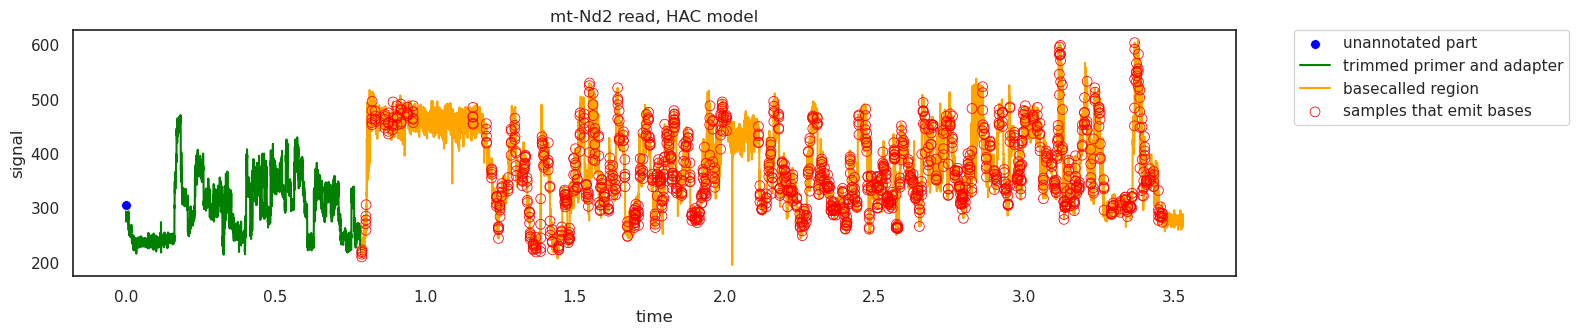

In [146]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=True, figsize=(15,3.2))

x_feature,y_feature = 'time','signal'

ax = sns.scatterplot(data = raw_signal_df.loc[raw_signal_df['ann']==-2].reset_index(drop=True),x=x_feature,y=y_feature,color='blue',label='unannotated part',s=50,zorder=4)
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['ann']==-1].reset_index(drop=True),x=x_feature,y=y_feature,color='green',label='trimmed primer and adapter',zorder=2)
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['ann'].isin([0,1])].reset_index(drop=True),x=x_feature,y=y_feature,color='orange',label='basecalled region',zorder=3)
ax = sns.scatterplot(data = raw_signal_df.loc[raw_signal_df['ann']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='red',label='samples that emit bases',s=50,fc="none",ec='red',zorder=4)

ax.set(title='mt-Nd2 read, HAC model')
# ax.set(xlim=(1.2,1.51))

ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')

In [141]:
# SUP model
Stride = 6
s = 'CCCCACCACTAACAGGATTCTTACCAAAATGAATTATCATCACAGAACTTATAAAAAACAACTGTCTAATTATAGCAACACTCATAGCAATAATAGCTCTACTAAACCTATTCTTTTATACTCGCCTAATTTATTCCACTTCACTAACAATATTTCCAACCAACAATAACTCAAAAATAATAACTCACCAAACAAAAACTAAACCCAACCTAATATTTTCCACCCTAGCTATCATAAGCACAATAACCCTACCCCTAGCCCCCCAACTAATTACC'
moves = [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,1,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,1,1,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0]
ts = 3150
ns = 14121
pt = 56

a = []+ts*[-1]
for elem in moves:  
    a = a+[elem]*Stride
a=a+(len(raw_signal_df)-ns)*[-1]
a = [-2]*max((len(raw_signal_df)-len(a)),0)+a
if len(a)==len(raw_signal_df):
    raw_signal_df['ann'] = a
else:
    print('smth wrong')

In [142]:
len(a),ns,len(raw_signal_df),len(raw_signal_df.loc[raw_signal_df['ann']==1].reset_index(drop=True))/Stride,len(s)

(14121, 14121, 14121, 275.0, 275)

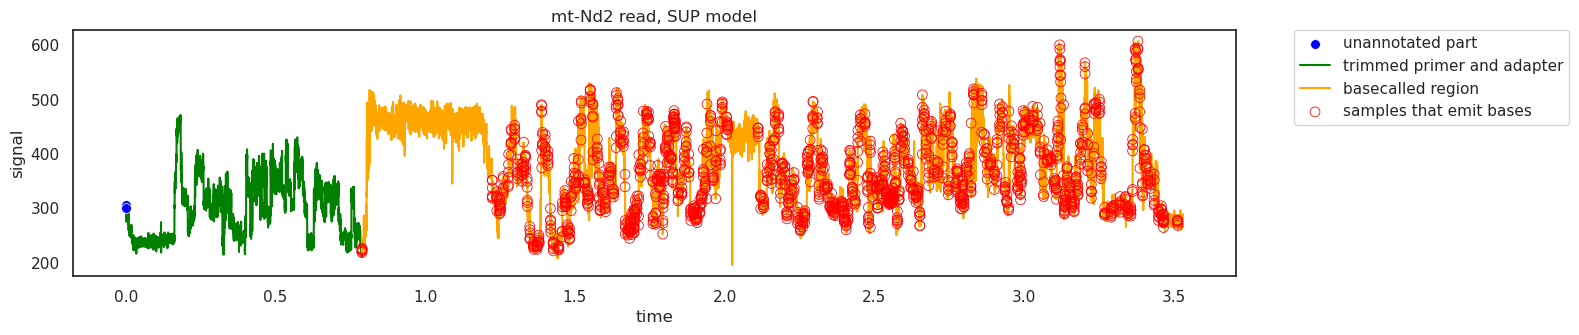

In [143]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=True, figsize=(15,3.2))

x_feature,y_feature = 'time','signal'

ax = sns.scatterplot(data = raw_signal_df.loc[raw_signal_df['ann']==-2].reset_index(drop=True),x=x_feature,y=y_feature,color='blue',label='unannotated part',s=50,zorder=4)
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['ann']==-1].reset_index(drop=True),x=x_feature,y=y_feature,color='green',label='trimmed primer and adapter',zorder=2)
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['ann'].isin([0,1])].reset_index(drop=True),x=x_feature,y=y_feature,color='orange',label='basecalled region',zorder=3)
ax = sns.scatterplot(data = raw_signal_df.loc[raw_signal_df['ann']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='red',label='samples that emit bases',s=50,fc="none",ec='red',zorder=4)

ax.set(title='mt-Nd2 read, SUP model')
# ax.set(xlim=(1.2,1.51))

ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')

In [99]:
command = 'pod5 filter --force-overwrite '+file_path+' --output '+subdirs['toy_dir']+'toy.pod5 --ids '+subdirs['toy_dir']+'read_ids.txt'
command

'pod5 filter --force-overwrite /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_pod5/p32592_o35831_1.pod5 --output /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.pod5 --ids /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/read_ids.txt'

In [129]:
threads = 12
command = 'dorado basecaller '+subdirs['dorado_models_dir']+'rna004_130bps_sup@v5.1.0 '+subdirs['toy_dir']+'toy.pod5'+' --emit-moves --estimate-poly-a --poly-a-config '+subdirs['toy_dir']+'polya_config.toml'+' --mm2-opts "-x splice -Y" --reference '+file_paths['mouse_genome_file']+' > '+subdirs['toy_dir']+'toy.dorado.sup.bam; \
samtools sort -@ '+str(threads)+' -o '+subdirs['toy_dir']+'toy.dorado.sup.sorted.bam'+' '+subdirs['toy_dir']+'toy.dorado.sup.bam'+' && samtools index -@ '+str(threads)+' '+subdirs['toy_dir']+'toy.dorado.sup.sorted.bam'+'; '

command

'dorado basecaller /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/dorado/basecalling_models/rna004_130bps_sup@v5.1.0 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.pod5 --emit-moves --estimate-poly-a --poly-a-config /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/polya_config.toml --mm2-opts "-x splice -Y" --reference /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.dorado.sup.bam; samtools sort -@ 12 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.dorado.sup.sorted.bam /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.dorado.sup.bam && samtools index -@ 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.dorado.sup.sorted.bam; '

In [101]:
threads = 12
command = 'pod5 convert to_fast5 --force-overwrite --file-read-count 5000000 -t '+str(threads)+' '+subdirs['toy_dir']+'toy.pod5 --output '+subdirs['toy_dir']+'fast5/'
command

'pod5 convert to_fast5 --force-overwrite --file-read-count 5000000 -t 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.pod5 --output /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/fast5/'

In [102]:
# command = 'nanopolish index -v --directory='+subdirs['toy_dir']+'fast5'+' --sequencing-summary='+subdirs['toy_dir']+'toy.sequencing_summary.txt '+subdirs['toy_dir']+'toy.fastq'
command = 'nanopolish index -v --directory='+subdirs['toy_dir']+'fast5/'+' '+subdirs['toy_dir']+'toy.fastq.gz'
command

'nanopolish index -v --directory=/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/fast5/ /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.fastq.gz'

In [103]:
threads = 12
command = ''
# command = command+'cp '+file_paths['mouse_genome_file']+' '+file_paths['mouse_genome_file']+'.fai'+' '+subdirs['toy_dir']
genome_file_name = file_paths['mouse_genome_file'].split('/')[-1]

command = command+'nanopolish polya --threads='+str(threads)+' --reads='+subdirs['toy_dir']+'toy.fastq.gz'+' --bam='+subdirs['toy_dir']+'toy.sorted.no_secondary.bam'+' --genome='+subdirs['toy_dir']+genome_file_name+' > '+subdirs['toy_dir']+'polya_results.tsv; '
command

'nanopolish polya --threads=12 --reads=/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.fastq.gz --bam=/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.no_secondary.bam --genome=/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/GRCm38.primary_assembly.genome.fa > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/polya_results.tsv; '

In [147]:
polya_results = pd.read_csv(subdirs['toy_dir']+'polya_results.tsv',delimiter="\t",index_col=None,header=0)
read_results = polya_results.loc[polya_results['readname']==toy_read].iloc[0]

raw_signal_df['seq_adapter'] = ((raw_signal_df['index']>=read_results['leader_start'])&(raw_signal_df['index']<read_results['adapter_start'])).astype('int')
raw_signal_df['RT_adapter'] = ((raw_signal_df['index']>=read_results['adapter_start'])&(raw_signal_df['index']<read_results['polya_start'])).astype('int')
raw_signal_df['polyA'] = ((raw_signal_df['index']>=read_results['polya_start'])&(raw_signal_df['index']<read_results['transcript_start'])).astype('int')
raw_signal_df['transcript'] = ((raw_signal_df['index']>=read_results['transcript_start'])).astype('int')

In [136]:
read_results

readname            7217c1de-d03f-4222-a97d-25dbb9e64357
contig                                              chrM
position                                            4675
leader_start                                         2.0
adapter_start                                        3.0
polya_start                                       3238.0
transcript_start                                  4823.0
read_rate                                         142.86
polya_length                                       51.57
qc_tag                                              PASS
Name: 0, dtype: object

In [148]:
polyA_time_span = (raw_signal_df.loc[raw_signal_df['polyA']==1]['time'].max()-raw_signal_df.loc[raw_signal_df['polyA']==1]['time'].min())
transcript_time_span = (raw_signal_df.loc[raw_signal_df['transcript']==1]['time'].max()-raw_signal_df.loc[raw_signal_df['polyA']==1]['time'].min())
283*polyA_time_span/transcript_time_span,read_results['polya_length']

(np.float64(41.19389818048153), np.float64(51.57))

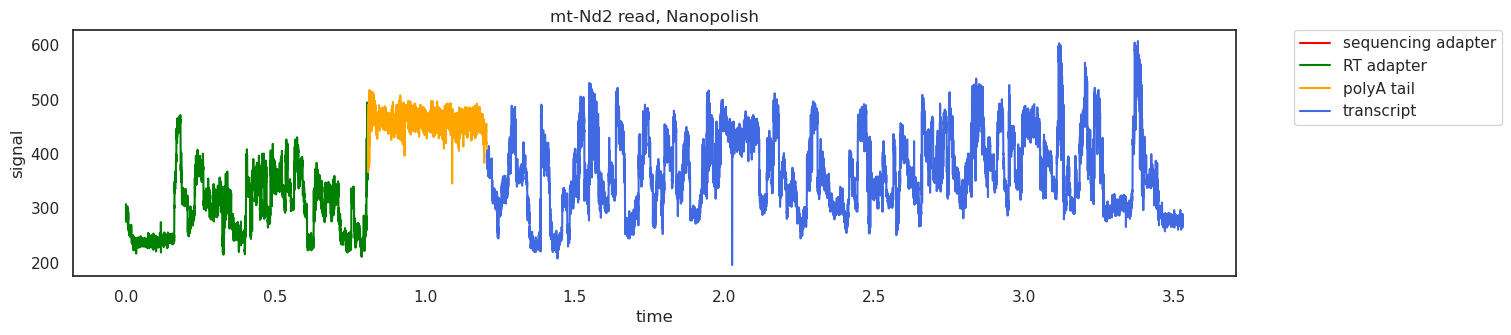

In [150]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(15,3.2))

x_feature,y_feature = 'time','signal'

ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['seq_adapter']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='red',label='sequencing adapter')
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['RT_adapter']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='green',label='RT adapter')
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['polyA']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='orange',label='polyA tail')
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['transcript']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='royalblue',label='transcript')
ax.set(title='mt-Nd2 read, Nanopolish')

ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')

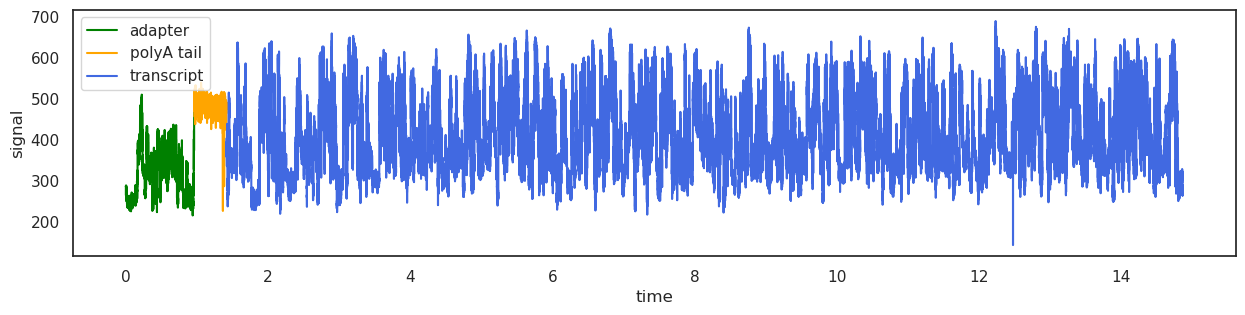

In [122]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(15,3.2))

x_feature,y_feature = 'time','signal'

ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['adapter']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='green',label='adapter')
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['polyA']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='orange',label='polyA tail')
ax = sns.lineplot(data = raw_signal_df.loc[raw_signal_df['transcript']==1].reset_index(drop=True),x=x_feature,y=y_feature,color='royalblue',label='transcript')
ax.set(title='Gapdh read')

ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')
# ax.vlines(x=0.65,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='red',lw=1.5)
# ax.vlines(x=1.45,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='red',lw=1.5)

'GRCm38.primary_assembly.genome.fa'

In [32]:
command = 'cp '+file_paths['mouse_genome_file']+' '+file_paths['mouse_genome_file']+'.fai'+' '+subdirs['toy_dir']
genome_file_name = file_paths['mouse_genome_file'].split('/')[-1]


command = 'minimap2 -ax splice -L -k14 -secondary=no --sam-hit-only '+subdirs['toy_dir']+genome_file_name+' '+subdirs['toy_dir']+'toy.fastq'+' | samtools view -b - -o '+subdirs['toy_dir']+'toy.bam; '+\
'samtools sort -o '+subdirs['toy_dir']+'toy.sorted.bam'+' '+subdirs['toy_dir']+'toy.bam'+' && samtools index '+subdirs['toy_dir']+'toy.sorted.bam'

# threads = 12

# input_samples = [
# '20240813_1724_X1_FAZ60491_8451cb8b.pass',
# '20240813_1749_X2_FAZ60547_f5851842.pass',
# '20240813_1749_X3_FAZ60875_f215937e.pass',
# '20240813_1749_X4_FAZ61052_010889e2.pass',
# 'SRR11550233',
# 'SRR11550261'
# ]

# command = ''
# command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/; '
# for sample in input_samples:
#     fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.rc_full.fastq.gz'
#     bam_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/'+sample+'.rc_300.minimap2.sorted.bam'
#     command = command+'minimap2 -ax splice -L -k14 -secondary=no --sam-hit-only '+genome_file+' '+fastq_file+' | samtools sort -@ '+str(threads)+' -O bam > '+bam_file
#     command = command+' && samtools index -@ '+str(threads)+' '+bam_file+'; '
command

'minimap2 -ax splice -L -k14 -secondary=no --sam-hit-only /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/GRCm38.primary_assembly.genome.fa /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.fastq | samtools view -b - -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.bam; samtools sort -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.bam /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.bam && samtools index /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/toy/toy.sorted.bam'

In [7]:
called_string = 'CCAGAUGGCUCAGUGGUUAAGAGUGCCGACUGCUCUCCUAAGGGGUCCCUAGUUCAAAUCCAGCAACCACAUGGUGGCUCACAACCAUCCGUAAUGAGAUCUGAUGCCCUUCUGGAGUAUUUGAGGACAGCUACAGUGUACUUACAUAUAAUAAAUAAAUAAAUCUUUAAAAAAAUC'

In [8]:
len(called_string)

177

In [20]:
(1.45-0.65)/(tmp['time'].max()-1.45)*len(called_string)

np.float64(84.19800802735246)

In [38]:
len(tmp.loc[tmp['time']>1.45])

6727

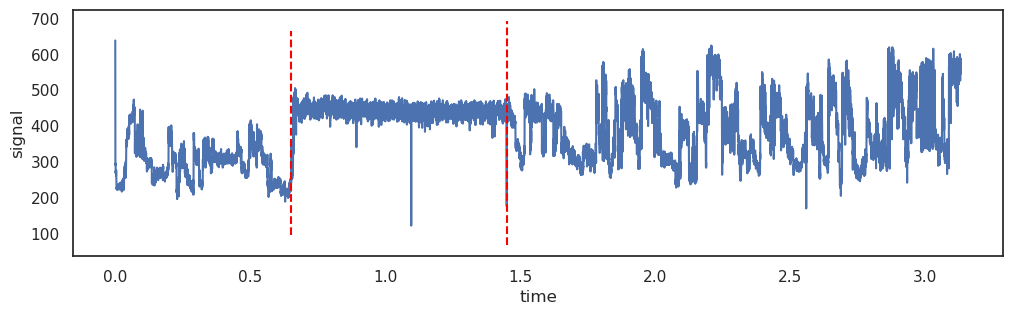

In [19]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(12,3.2))

ax = sns.lineplot(data = tmp,x='time',y='signal')
ax.vlines(x=0.65,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='red',lw=1.5)
ax.vlines(x=1.45,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='red',lw=1.5)

# Run Dorado for all samples

In [7]:
# check CUDA driver version
# nvidia-smi

In [8]:
# each small file in an individual computational job

In [9]:
metadata = pd.DataFrame([
    ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b'],    
    ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842'],
    ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e'],
    ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2'],
           ],columns=['sample','bio_id','file_id'])
metadata

,sample,bio_id,file_id
0,Cnot8_KO_1,p32592_o35831_1,20240813_1724_X1_FAZ60491_8451cb8b
1,Cnot8_KO_2,p32592_o35831_2,20240813_1749_X2_FAZ60547_f5851842
2,CTRL_1,p32592_o35831_3,20240813_1749_X3_FAZ60875_f215937e
3,CTRL_2,p32592_o35831_4,20240813_1749_X4_FAZ61052_010889e2


In [10]:
# srun --nodes=1 --cpus-per-task=12 --mem=80G --qos=gpu6hours --partition=a100 --time=5:59:00 --gres=gpu:1 --pty bash

In [11]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
bam_output = general_output_dir+'bam_small_files/'

os.system('mkdir -p '+bam_output) # create all subdirs

a = []
for index, row in metadata.iterrows():
    dir_to_search = subdirs['pod5_dir']+row['bio_id']+'/'
    os.system("""find """+dir_to_search+""" -name '*.pod5' > """+subdirs['temp_dir']+row['bio_id']+"""_small_pod5_files.tsv""")
    tmp_files_df = pd.read_csv(subdirs['temp_dir']+row['bio_id']+"""_small_pod5_files.tsv""",delimiter="\t",index_col=None,header=None)
    tmp_files_df.columns = ['path']
    tmp_files_df['bio_id'] = row['bio_id']
    tmp_files_df['sample'] = row['sample']
    a.append(tmp_files_df)
small_pod5_files_df = pd.concat(a).reset_index(drop=True)

small_pod5_files_df['small_file_id'] = small_pod5_files_df.apply(lambda x: x['path'].split('/')[-1].split('.pod5')[0],1)
small_pod5_files_df['id'] = small_pod5_files_df.index+1
small_pod5_files_df['out_sorted_bam'] = bam_output+small_pod5_files_df['sample']+'.'+small_pod5_files_df['small_file_id']+'.sorted.bam'

table_of_all_small_pod5_files = subdirs['temp_dir']+'all_small_pod5_files.tsv'
small_pod5_files_df[['id','path','out_sorted_bam']].to_csv(table_of_all_small_pod5_files, sep=str('\t'),header=False,index=None)

threads,RAM = 6,40

sbatch_script_path = subdirs['slurm_scripts_dir']+'Dorado_SUP_basecall.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=dorado_SUP
#SBATCH --time=0:29:00
#SBATCH --qos=gpu30min
#SBATCH --partition=a100
#SBATCH --gres=gpu:1
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(small_pod5_files_df))+"""%150

source ~/.bashrc
module load CUDA
conda activate nanopore
"""
f.write(preambula+'\n')
f.write("""pod5=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_all_small_pod5_files+')\n')
f.write("""out_sorted_bam=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_all_small_pod5_files+')\n')
f.write("""echo $out_bam"""+'\n')

command = 'dorado basecaller '+\
subdirs['dorado_models_dir']+'rna004_130bps_sup@v5.1.0 '+\
'$pod5'+\
' --estimate-poly-a --poly-a-config '+subdirs['toy_dir']+'polya_config.toml'+\
' --mm2-opts "-x splice -Y" --reference '+file_paths['mouse_genome_file']+\
' | '+\
'samtools sort -@ '+str(threads)+' -o $out_sorted_bam && samtools index -@ '+str(threads)+' $out_sorted_bam'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/Dorado_SUP_basecall.sbatch


In [12]:
# merge small bam files into sample-level files

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
merged_bam_output = general_output_dir+'bam_merged/'

os.system('mkdir -p '+merged_bam_output) # create all subdirs

merged_df = pd.concat([small_pod5_files_df['sample'],small_pod5_files_df[['sample','out_sorted_bam']].groupby('sample')['out_sorted_bam'].transform(lambda x: ' '.join(x))],axis=1).drop_duplicates().reset_index(drop=True)
merged_df = merged_df.rename(columns = {'out_sorted_bam':'input_bam_files'})
merged_df['out_merged_sorted_bam'] = merged_bam_output+merged_df['sample']+'.sorted.bam'
merged_df['out_merged_unique_mappers_bam'] = merged_bam_output+merged_df['sample']+'.sorted.uniquely_mapped.bam'
merged_df['id'] = merged_df.index+1

table_of_small_bam_files = subdirs['temp_dir']+'small_bam_files.tsv'
merged_df[['id','input_bam_files','out_merged_sorted_bam','out_merged_unique_mappers_bam']].to_csv(table_of_small_bam_files, sep=str('\t'),header=False,index=None)

threads,RAM = 12,40

sbatch_script_path = subdirs['slurm_scripts_dir']+'samtools_merge_and_filter_small_bam_files.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=samtools_merge_and_filter_small_bam_files
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --partition=scicore
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(merged_df))+"""%150

source ~/.bashrc
conda activate nanopore
"""
f.write(preambula+'\n')
f.write("""input_bam_files=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_small_bam_files+')\n')
f.write("""out_merged_sorted_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_small_bam_files+')\n')
f.write("""out_merged_unique_mappers_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_small_bam_files+')\n')
f.write("""echo $out_merged_sorted_bam"""+'\n')

command = 'samtools merge -u -@ '+str(threads)+' -o - $input_bam_files | \
samtools sort -@ '+str(threads)+' -o $out_merged_sorted_bam && \
samtools index -@ '+str(threads)+' $out_merged_sorted_bam; \
samtools view -@ '+str(threads)+' -q 1 -F 0x100 --tag pt -u $out_merged_sorted_bam | \
samtools sort -@ '+str(threads)+' -o $out_merged_unique_mappers_bam && \
samtools index -@ '+str(threads)+' $out_merged_unique_mappers_bam'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/samtools_merge_and_filter_small_bam_files.sbatch


In [13]:
# separate reads by chromosome

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
bam_over_chromosomes_output = general_output_dir+'bam_over_chromosomes/'

os.system('mkdir -p '+bam_over_chromosomes_output) # create all subdirs

input_df = merged_df[['sample','out_merged_unique_mappers_bam']].drop_duplicates().reset_index(drop=True)
input_df.columns = ['sample','input_bam']
input_df['t'] = 1

genome_fai = pd.read_csv(file_paths['mouse_genome_fai_file'],delimiter="\t",index_col=None,header=None)
genome_fai = genome_fai[[0]]
genome_fai.columns = ['chrom']
genome_fai['t']=1

input_df = pd.merge(input_df,genome_fai,how='inner',on='t') # make a cartesian product
input_df['output_bam'] = bam_over_chromosomes_output+input_df['sample']+'.'+input_df['chrom']+'.sorted.bam'
input_df['id'] = input_df.index+1

table_of_over_chrom_bam_files = subdirs['temp_dir']+'over_chrom_bam_files.tsv'
input_df[['id','input_bam','output_bam','chrom']].to_csv(table_of_over_chrom_bam_files, sep=str('\t'),header=False,index=None)

threads,RAM = 4,20

sbatch_script_path = subdirs['slurm_scripts_dir']+'samtools_split_bams_by_chromosomes.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=samtools_split_bams_by_chromosomes
#SBATCH --time=00:29:00
#SBATCH --qos=30min
#SBATCH --partition=scicore
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(input_df))+"""%150

source ~/.bashrc
conda activate nanopore
"""
f.write(preambula+'\n')
f.write("""input_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_over_chrom_bam_files+')\n')
f.write("""output_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_over_chrom_bam_files+')\n')
f.write("""chrom=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_over_chrom_bam_files+')\n')
f.write("""echo $input_bam"""+'\n')

command = '\
samtools view -@ '+str(threads)+' --with-header -u $input_bam $chrom | \
samtools sort -@ '+str(threads)+' -o $output_bam; \
samtools index -@ '+str(threads)+' $output_bam;'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/samtools_split_bams_by_chromosomes.sbatch


In [14]:
# separate GTF by chromosome

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
gtf_over_chromosomes_output = general_output_dir+'gtf_over_chromosomes/'

os.system('mkdir -p '+gtf_over_chromosomes_output) # create all subdirs

genome_fai = pd.read_csv(file_paths['mouse_genome_fai_file'],delimiter="\t",index_col=None,header=None)

# get annotation file and extract annotated transcript isoforms in the same manner as observed ones

gtf = pd.read_csv(file_paths['mouse_annotation_file'],delimiter="\t",index_col=None,header=None,skiprows=5)

for chrom in list(genome_fai[0]):
    gtf.loc[gtf[0]==chrom].to_csv(gtf_over_chromosomes_output+chrom+'.gtf', sep=str('\t'),header=False,index=None)

In [15]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
bam_over_chromosomes_output = general_output_dir+'bam_over_chromosomes/'
lists_of_files_dir = bam_over_chromosomes_output+'lists_of_files/'
gtf_over_chromosomes_dir = general_output_dir+'gtf_over_chromosomes/'
read_assignment_dir = general_output_dir+'read_assignment_over_chromosomes/'
os.system('mkdir -p '+read_assignment_dir) # create all subdirs

genome_fai = pd.read_csv(file_paths['mouse_genome_fai_file'],delimiter="\t",index_col=None,header=None)
a = []
for chrom in list(genome_fai[0]):
    input_bam_files_file = lists_of_files_dir+chrom+'.txt'
    input_gtf_file = gtf_over_chromosomes_dir+chrom+'.gtf'
    tmp_dir = subdirs['temp_dir']+'read_assignment_'+chrom+'/'
    os.system('mkdir -p '+tmp_dir) # create all subdirs
    out_reads = read_assignment_dir+chrom+'.assigned_reads.tsv'
    out_isoforms = read_assignment_dir+chrom+'.isoforms.tsv'
    input_df[input_df['chrom']==chrom][['output_bam']].to_csv(input_bam_files_file, sep=str('\t'),header=False,index=None)
    a.append([input_bam_files_file,input_gtf_file,tmp_dir,out_reads,out_isoforms,chrom])
    
input_specification_df = pd.DataFrame(a,columns = ['input_bam_files','input_gtf_file','tmp_dir','out_reads','out_isoforms','chrom'])
cols = list(input_specification_df.columns)

# temporary
# input_specification_df = input_specification_df.loc[input_specification_df['chrom']=='chrM'].reset_index(drop=True)

input_specification_df['id'] = input_specification_df.index+1
input_specification_df = input_specification_df[['id']+cols]

specification_table = subdirs['temp_dir']+'read_assignment_specification.tsv'
input_specification_df[['id']+cols[:-1]].to_csv(specification_table, sep=str('\t'),header=False,index=None)

threads,RAM = 4,60

sbatch_script_path = subdirs['slurm_scripts_dir']+'assign_ONT_reads_to_isoforms.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=assign_ONT_reads_to_isoforms
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --partition=scicore
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(input_specification_df))+"""%150

source ~/.bashrc
conda activate nanopore
"""
f.write(preambula+'\n')
f.write("""input_bam_files=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+specification_table+')\n')
f.write("""input_gtf_file=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+specification_table+')\n')
f.write("""tmp_dir=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+specification_table+')\n')
f.write("""out_reads=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $5} }' """+specification_table+')\n')
f.write("""out_isoforms=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $6} }' """+specification_table+')\n')
f.write("""echo $input_bam_files"""+'\n')

command = 'python '+subdirs['wf_dir']+'scripts/assign_ONT_reads_to_isoforms.py \
--input_bam_files $input_bam_files \
--input_gtf_file $input_gtf_file \
--tmp_dir $tmp_dir \
--out_reads $out_reads \
--out_isoforms $out_isoforms \
--gtf_skip_rows 0'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/assign_ONT_reads_to_isoforms.sbatch


In [163]:
# append polyA tails to reads

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
bam_over_chromosomes_output = general_output_dir+'bam_over_chromosomes/'

os.system('mkdir -p '+bam_over_chromosomes_output) # create all subdirs

input_df['modified_bam'] = bam_over_chromosomes_output+input_df['sample']+'.'+input_df['chrom']+'.sorted.appended_pAtails.bam'

table_of_over_chrom_bam_files = subdirs['temp_dir']+'bam_files_to_modify.tsv'
input_df[['id','output_bam','modified_bam','chrom']].to_csv(table_of_over_chrom_bam_files, sep=str('\t'),header=False,index=None)

threads,RAM = 2,30

sbatch_script_path = subdirs['slurm_scripts_dir']+'append_polyA_tails.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=append_polyA_tails
#SBATCH --time=02:29:00
#SBATCH --qos=6hours
#SBATCH --partition=scicore
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(input_df))+"""%150

source ~/.bashrc
conda activate nanopore
"""
f.write(preambula+'\n')
f.write("""input_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_over_chrom_bam_files+')\n')
f.write("""output_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_over_chrom_bam_files+')\n')
f.write("""echo $input_bam"""+'\n')

command = 'python '+subdirs['wf_dir']+'scripts/append_polyA_tails.py \
--input_bam_file $input_bam \
--output_bam_file $output_bam'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/append_polyA_tails.sbatch


In [253]:
input_df.head()

,sample,input_bam,t,chrom,output_bam,id,modified_bam
0,Cnot8_KO_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1,chr1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1,/scicore/home/zavolan/GROUP/Regulation_of_gast...
1,Cnot8_KO_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1,chr2,/scicore/home/zavolan/GROUP/Regulation_of_gast...,2,/scicore/home/zavolan/GROUP/Regulation_of_gast...
2,Cnot8_KO_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1,chr3,/scicore/home/zavolan/GROUP/Regulation_of_gast...,3,/scicore/home/zavolan/GROUP/Regulation_of_gast...
3,Cnot8_KO_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1,chr4,/scicore/home/zavolan/GROUP/Regulation_of_gast...,4,/scicore/home/zavolan/GROUP/Regulation_of_gast...
4,Cnot8_KO_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1,chr5,/scicore/home/zavolan/GROUP/Regulation_of_gast...,5,/scicore/home/zavolan/GROUP/Regulation_of_gast...


In [256]:
input_df[['sample','modified_bam']].groupby('sample')['modified_bam'].transform(lambda x: ' '.join(x))

0      /scicore/home/zavolan/GROUP/Regulation_of_gast...
1      /scicore/home/zavolan/GROUP/Regulation_of_gast...
2      /scicore/home/zavolan/GROUP/Regulation_of_gast...
3      /scicore/home/zavolan/GROUP/Regulation_of_gast...
4      /scicore/home/zavolan/GROUP/Regulation_of_gast...
                             ...                        
259    /scicore/home/zavolan/GROUP/Regulation_of_gast...
260    /scicore/home/zavolan/GROUP/Regulation_of_gast...
261    /scicore/home/zavolan/GROUP/Regulation_of_gast...
262    /scicore/home/zavolan/GROUP/Regulation_of_gast...
263    /scicore/home/zavolan/GROUP/Regulation_of_gast...
Name: modified_bam, Length: 264, dtype: object

In [257]:
# merge small MODIFIED bam files into sample-level files

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
merged_bam_output = general_output_dir+'bam_merged_appended_polyAtails/'

os.system('mkdir -p '+merged_bam_output) # create all subdirs

merged_df = pd.concat([input_df['sample'],input_df[['sample','modified_bam']].groupby('sample')['modified_bam'].transform(lambda x: ' '.join(x))],axis=1).drop_duplicates().reset_index(drop=True)
merged_df = merged_df.rename(columns = {'modified_bam':'input_bam_files'})
merged_df['out_merged_sorted_bam'] = merged_bam_output+merged_df['sample']+'.sorted.bam'
merged_df['out_merged_unique_mappers_bam'] = merged_bam_output+merged_df['sample']+'.sorted.uniquely_mapped.bam'
merged_df['id'] = merged_df.index+1

table_of_small_bam_files = subdirs['temp_dir']+'small_bam_files.tsv'
merged_df[['id','input_bam_files','out_merged_sorted_bam','out_merged_unique_mappers_bam']].to_csv(table_of_small_bam_files, sep=str('\t'),header=False,index=None)

threads,RAM = 12,40

sbatch_script_path = subdirs['slurm_scripts_dir']+'samtools_merge_and_filter_small_MODIFIED_bam_files.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=samtools_merge_and_filter_small_MODIFIED_bam_files
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --partition=scicore
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(merged_df))+"""%150

source ~/.bashrc
conda activate nanopore
"""
f.write(preambula+'\n')
f.write("""input_bam_files=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_small_bam_files+')\n')
f.write("""out_merged_sorted_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_small_bam_files+')\n')
f.write("""out_merged_unique_mappers_bam=$(awk -F '\t' -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_small_bam_files+')\n')
f.write("""echo $out_merged_sorted_bam"""+'\n')

command = 'samtools merge -u -@ '+str(threads)+' -o - $input_bam_files | \
samtools sort -@ '+str(threads)+' -o $out_merged_sorted_bam && \
samtools index -@ '+str(threads)+' $out_merged_sorted_bam; \
samtools view -@ '+str(threads)+' -q 1 -F 0x100 --tag pt -u $out_merged_sorted_bam | \
samtools sort -@ '+str(threads)+' -o $out_merged_unique_mappers_bam && \
samtools index -@ '+str(threads)+' $out_merged_unique_mappers_bam'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/samtools_merge_and_filter_small_MODIFIED_bam_files.sbatch


In [260]:
merged_df.head()

,sample,input_bam_files,out_merged_sorted_bam,out_merged_unique_mappers_bam,id
0,Cnot8_KO_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,1
1,Cnot8_KO_2,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,2
2,CTRL_1,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,3
3,CTRL_2,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,/scicore/home/zavolan/GROUP/Regulation_of_gast...,4


In [262]:
merged_df.iloc[0]['out_merged_unique_mappers_bam']

'/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged_appended_polyAtails/Cnot8_KO_1.sorted.uniquely_mapped.bam'

In [233]:
command

'python /scicore/home/zavolan/mirono0000/Projects/Regulation_of_gastrulation/WF/scripts/append_polyA_tails.py --input_bam_file $input_bam --output_bam_file $output_bam'

In [251]:
## pysam-based

input_bam_file_path = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chr1.sorted.bam'
output_bam_file_path = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chr1.sorted.appended_pAtails.bam'

almnt_file = pysam.AlignmentFile(input_bam_file_path, "rb")
bam_writer = pysam.AlignmentFile(output_bam_file_path, "wb", header=almnt_file.header)

min_A_content = 0.9

# all .iv elements follow bed format
j,k=0,0
total_number_of_reads,number_of_nonmodified_reads = 0,0
for almnt in almnt_file:
    j=j+1
    pt = almnt.get_tag('pt')
    if almnt.is_forward:
        read_seq = almnt.query_sequence
        read_qualstr = almnt.query_qualities
        cigar = almnt.cigar
    else:
        read_seq = almnt.get_forward_sequence()
        read_qualstr = almnt.query_qualities[::-1]
        cigar = almnt.cigar[::-1]
        
    # find presumbale position of the cleavage site in the read - how many nt from 3'end to trim
    n = len(read_seq)
    Acount = 0
    suffix_len = 0
    prev_char = ''
    nonA_stretch_len = 0
    for i in range(n - 1, -1, -1):
        new_char = read_seq[i:i+1]
        suffix_len +=1
        if new_char.upper() == "A":
            Acount += 1
        else:
            if prev_char=="A":
                nonA_stretch_len = 1
            else:
                nonA_stretch_len += 1
            Aprop = Acount/suffix_len
            if Aprop<min_A_content:
                break
        prev_char = new_char
    trim_len = suffix_len-nonA_stretch_len

    # modify sequence, qualseq and cigar
    if trim_len<pt:
        # define new read sequence
        new_read_seq = read_seq[:(-trim_len if trim_len>0 else None)]+"A"*pt

        # define new quality string
        quality_val = int(np.round(np.mean(read_qualstr[(-trim_len if trim_len>0 else -(min(5,len(read_seq)))):]),0)) # take the average of read qualities at trimmed part as a proxy read quality for added sequence
        new_read_qualstr = read_qualstr[:(-trim_len if trim_len>0 else None)]
        new_read_qualstr.extend([quality_val]*pt)

        # add some basic quality checks
        if len(new_read_seq)!=len(new_read_qualstr):
            print("[WARNING] modified read seq and read quality string have different length: "+str(almnt.query_name)+"; read is skipped")
            continue          
        
        # define new cigar string
        l=0 # position in cigar, backwards
        i = 0
        success = False
        for elem in cigar[::-1]:
            i=i+1
            if elem[0] in [0,1,4,5]:
                l = l+elem[1]            
                if l>trim_len: # we reached the right element
                    last_cigar_elem = elem
                    if last_cigar_elem[0]==4: # if soft-clip then extend soft-clip
                        cigar = cigar[:-i] # cigar until previous element will be untouched
                        cigar.append((4,last_cigar_elem[1]-trim_len+pt))
                        success=True
                    elif last_cigar_elem[0]==0: # if match then append soft-clip
                        cigar = cigar[:(-i+1 if -i+1<0 else None)]
                        cigar.append((4,(l-last_cigar_elem[1])+pt-trim_len))
                        success=True
                    else:
                        # this is undefined situation
                        # skip such read
                        success = False
                    break
        if not success:
            print("[WARNING] CIGAR string of read couldn't be modified: "+str(almnt.query_name)+"; read is skipped")
            continue
        if len(new_read_seq)!=np.sum([elem[1] for elem in cigar if elem[0] in [0,1,4,5]]):
            print("[WARNING] modified CIGAR and read seq have different lengths: "+str(almnt.query_name)+"; read is skipped")
            continue            
            
        if almnt.is_forward:
            almnt.query_sequence = new_read_seq
            almnt.query_qualities = new_read_qualstr
            almnt.cigar = cigar
        else:
            new_read_seq = HTSeq.Sequence( str.encode(new_read_seq), "seq" )
            almnt.query_sequence = new_read_seq.get_reverse_complement().seq.decode("utf-8")
            almnt.query_qualities = new_read_qualstr[::-1]
            almnt.cigar = cigar[::-1]
            
        # add a tag specifying that the read was modifed
        almnt.set_tag('pa',1,'i')
        
    else:
        # not clear how many to trim
        # leave reads as they are then
        number_of_nonmodified_reads +=1
        almnt.set_tag('pa',0,'i')
    
    bam_writer.write( almnt )
    k=k+1

total_number_of_processed_reads = k
total_number_of_input_reads = j
print("[INFO] total number of non-modified reads: "+str(number_of_nonmodified_reads))
print("[INFO] total number of input reads: "+str(total_number_of_input_reads))
print("[INFO] total number of successfully processed reads: "+str(total_number_of_processed_reads))
bam_writer.close()

[WARNING] CIGAR string of read couldn't be modified: d28fec23-75e0-4468-890a-22fd1c763518; read is skipped
[WARNING] CIGAR string of read couldn't be modified: da561d8a-6e4c-4170-8c1a-0475bb5cbe02; read is skipped
[WARNING] CIGAR string of read couldn't be modified: 10a96ce9-a86a-4fdd-83c2-a0d21ba16c5d; read is skipped
[WARNING] CIGAR string of read couldn't be modified: 6cef13ba-cce5-4d34-93c4-e813c0c76fb6; read is skipped
[WARNING] CIGAR string of read couldn't be modified: b2e664b0-8884-4425-878a-c91a0761a6d3; read is skipped
[WARNING] CIGAR string of read couldn't be modified: c5f912a2-f9ad-4457-ac98-87da6025ef91; read is skipped
[WARNING] CIGAR string of read couldn't be modified: edb340d5-9015-455a-a4b5-405bd17c52e9; read is skipped
[WARNING] CIGAR string of read couldn't be modified: 5125d98e-b1bc-4e9d-ac59-c7632e144f29; read is skipped
[WARNING] CIGAR string of read couldn't be modified: 18fc499a-f1f5-4533-bb25-dd74f1446efc; read is skipped
[WARNING] CIGAR string of read couldn

In [241]:
len(new_read_seq),np.sum([elem[1] for elem in cigar if elem[0] in [0,1,4,5]])

(452, 402)

In [249]:
almnt.is_forward

True

In [250]:
success

True

In [248]:
almnt.cigar

[(4, 1), (0, 287), (2, 1), (0, 79), (1, 2), (0, 32), (4, 1)]

In [247]:
cigar

[(4, 1), (0, 287), (2, 1), (0, 79), (1, 2), (0, 32), (4, 1)]

In [239]:
trim_len,pt

(33, 83)

In [ ]:
ci

In [235]:
np.sum([elem[1] for elem in cigar]),len(new_read_seq)

(403, 452)

In [183]:
trim_len

0

In [202]:
len(read_seq),len(almnt.query_sequence),len(almnt.query_sequence)

(287, 489)

In [179]:
len(read_seq),6+197+84

(287, 287)

In [181]:
len(new_read_seq),6+197+286

(202, 489)

In [200]:
cigar

[(4, 6), (0, 197), (4, 286)]

In [173]:
almnt.query_name

'5f8276f5-1153-46dc-b469-d6841e07fb1f'

In [ ]:
5f8276f5-1153-46dc-b469-d6841e07fb1f

In [161]:
new_read_qualstr

array('B', [6, 6, 10, 15, 18, 22, 13, 13, 13, 13, 12, 13, 17, 28, 11, 11, 11, 9, 13, 10, 6, 7, 9, 13, 18, 19, 32, 30, 31, 32, 32, 31, 32, 35, 35, 34, 34, 34, 34, 34, 37, 35, 34, 35, 34, 34, 33, 34, 33, 34, 28, 27, 27, 27, 27, 32, 32, 32, 33, 35, 34, 34, 34, 35, 36, 39, 40, 39, 39, 39, 38, 38, 38, 38, 38, 39, 36, 34, 32, 32, 32, 35, 36, 37, 37, 37, 36, 36, 35, 35, 36, 35, 35, 35, 34, 34, 34, 34, 33, 30, 30, 29, 28, 27, 27, 27, 25, 19, 19, 18, 18, 18, 18, 18, 18, 18, 18, 18, 21, 21, 20, 20, 19, 19, 19, 19, 18, 17, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14])

In [146]:
almnt.cigar

[(4, 62)]

In [122]:
cigar.append((4,4))
cigar

[(4, 20), (0, 4), (2, 1), (0, 111), (4, 4), (4, 4)]

In [71]:
input_bam_file_path = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chr1.sorted.bam'
out_bam_file_path = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chr1.sorted.appended_pAtails.bam'

almnt_file = HTSeq.SAM_Reader( input_bam_file_path )
bam_writer = HTSeq.BAM_Writer.from_BAM_Reader( out_bam_file_path, almnt_file )

min_A_content = 0.9

# all .iv elements follow bed format
j=0
total_number_of_reads,number_of_nonmodified_reads = 0,0
for almnt in almnt_file:
    pt = almnt.optional_field("pt")
    read_seq = almnt.read.seq.decode("utf-8")
    read_qualstr = almnt.read.qualstr.decode("utf-8")
    
    # find presumbale position of the cleavage site in the read - how many nt from 3'end to trim
    n = len(read_seq)
    Acount = 0
    suffix_len = 0
    prev_char = ''
    nonA_stretch_len = 0
    for i in range(n - 1, -1, -1):
        new_char = read_seq[i:i+1]
        suffix_len +=1
        if new_char.upper() == "A":
            Acount += 1
        else:
            if prev_char=="A":
                nonA_stretch_len = 1
            else:
                nonA_stretch_len += 1
            Aprop = Acount/suffix_len
            if Aprop<min_A_content:
                break
        prev_char = new_char
    trim_len = suffix_len-nonA_stretch_len

    # modify sequence, qualseq and cigar
    if trim_len<pt:
        new_read_seq = read_seq[:-trim_len]+"A"*pt
        new_read_qualstr = read_qualstr[:-trim_len]+"A"*pt

        almnt.read.seq = str.encode(new_read_seq)
        # almnt.read.qualstr = str.encode(new_read_qualstr)
        
        # add a tag specifying that the read was modifed
        optional_fields = almnt.optional_fields
        optional_fields.append(('pa',1))
        almnt.optional_fields = optional_fields
        
        # define new cigar string
        
        
    else:
        # not clear how many to trim
        # leave reads as they are then
        number_of_nonmodified_reads +=1

        optional_fields = almnt.optional_fields
        optional_fields.append(('pa',0))
        almnt.optional_fields = optional_fields
        
    #     bam_writer.write( almnt )
    # bam_writer.write( almnt )
    j=j+1
    if j>1:
        break

total_number_of_reads = j
print("[INFO] total number of non-modified reads: "+str(number_of_nonmodified_reads)+", total number of processed reads: "+str(total_number_of_reads))
bam_writer.close()

[INFO] total number of non-modified reads: 0, total number of processed reads: 2


In [52]:
almnt.read = HTSeq.SequenceWithQualities( str.encode(new_read_seq), "seq", str.encode(new_read_qualstr), "phred" )

AttributeError: attribute 'read' of 'HTSeq._HTSeq.AlignmentWithSequenceReversal' objects is not writable

In [72]:
?almnt.read

Type:           SequenceWithQualities
String form:    CAGAAGGACACTCTGTTCTGTCTTTCTGGAAGCTTCAGAGTTTTTGGACATTGTCTTCCAGTTGGCATTTGTTTGAAATTGTATTGAAACAATTTAATGAAAACATTAAATACTTGGTTTTAAACTCCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA
Length:         181
File:           ~/miniforge3_Dec2024/envs/nanopore/lib/python3.12/site-packages/HTSeq/_HTSeq.cpython-312-x86_64-linux-gnu.so
Docstring:     
A Sequence with base-call quality scores.
It now has property  'qual', an integer NumPy array of Sanger/Phred
quality scores of the  base calls.
Init docstring:
Construct a SequenceWithQuality object.

seq       - The actual sequence.
name      - The sequence name or ID
qualstr   - The quality string. Must have the same length as seq
qualscale - The encoding scale of the quality string. Must be one of
              "phred", "solexa", "solexa-old", or "noquals" )

In [38]:
almnt.optional_fields = [(('NH',cur_NH) if elem[0]=='NH' else elem) for elem in alignment.optional_fields]

[< CigarOperation: 4 base(s) soft-clipped on ref iv chr1:[3630787,3630787)/-, query iv [0,4) >,
 < CigarOperation: 111 base(s) matched on ref iv chr1:[3630787,3630898)/-, query iv [4,115) >,
 < CigarOperation: 1 base(s) deleted on ref iv chr1:[3630898,3630899)/-, query iv [115,115) >,
 < CigarOperation: 4 base(s) matched on ref iv chr1:[3630899,3630903)/-, query iv [115,119) >,
 < CigarOperation: 20 base(s) soft-clipped on ref iv chr1:[3630903,3630903)/-, query iv [119,139) >]

In [73]:
read_seq,new_read_seq

('CAGAAGGACACTCTGTTCTGTCTTTCTGGAAGCTTCAGAGTTTTTGGACATTGTCTTCCAGTTGGCATTTGTTTGAAATTGTATTGAAACAATTTAATGAAAACATTAAATACTTGGTTTTAAACTCCAAAAAAAAAAA',
 'CAGAAGGACACTCTGTTCTGTCTTTCTGGAAGCTTCAGAGTTTTTGGACATTGTCTTCCAGTTGGCATTTGTTTGAAATTGTATTGAAACAATTTAATGAAAACATTAAATACTTGGTTTTAAACTCCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA')

In [15]:
suffix

'A'

1413

In [73]:
n = len(read_seq)

for i in range(n - 1, -1, -1):
    suffix = read_seq[i:]
    suffix_length = len(suffix)
    
    
    break
    # if suffix_length == 0: # Should not happen with range(n), but as a safeguard
    #     continue
    
    # a_count_in_suffix = suffix.count('A')
    
    # if a_count_in_suffix / suffix_length >= min_a_percentage:
    #     return i -1 # The poly-A rich region *starts* at index i, so we return the position *before* it

In [77]:
suffix_length

1

In [31]:
# loading and analyzing the outputs from different chromosomes
# now, the unique ID of reads will be chr+read_id
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

sample_metadata,isoforms_all,reads_all,transcripts_all = [],[],[],[]

for index, row in input_specification_df.iterrows():
    if row['chrom'].startswith('chr'): # focus on canonical chromosomes only
        bam_files_df = pd.read_csv(lists_of_files_dir+row['chrom']+'.txt',delimiter="\t",index_col=None,header=None)
        bam_files_df.columns = ['path']
        bam_files_df['sample'] = bam_files_df.apply(lambda x:x['path'].split('/')[-1].split('.chr')[0],1)
        bam_files_df['sample_index'] = bam_files_df.index
        bam_files_df['chr'] = row['chrom']
        sample_metadata.append(bam_files_df)
        
        reads_df = pd.read_csv(row['out_reads'],delimiter="\t",index_col=None,header=0)
        reads_all.append(reads_df)
        isoforms_df = pd.read_csv(row['out_isoforms'],delimiter="\t",index_col=None,header=0)
        isoforms_all.append(isoforms_df)
        
        gtf = pd.read_csv(row['input_gtf_file'],delimiter="\t",index_col=None,header=None)
        transcripts = gtf.loc[gtf[2]=='transcript'].reset_index(drop=True)
        transcripts['transcript_id'] = transcripts[8].str.split('transcript_id "',expand=True)[1].str.split('";',expand=True)[0]
        transcripts['gene_id'] = transcripts[8].str.split('gene_id "',expand=True)[1].str.split('";',expand=True)[0]
        transcripts['gene_name'] = transcripts[8].str.split('gene_name "',expand=True)[1].str.split('";',expand=True)[0]
        transcripts['gene_type'] = transcripts[8].str.split('gene_type "',expand=True)[1].str.split('";',expand=True)[0]
        
        transcripts_all.append(transcripts[['transcript_id','gene_id','gene_name','gene_type']])
        print(row['chrom']+' loaded')

chr1 loaded
chr2 loaded
chr3 loaded
chr4 loaded
chr5 loaded
chr6 loaded
chr7 loaded
chr8 loaded
chr9 loaded
chr10 loaded
chr11 loaded
chr12 loaded
chr13 loaded
chr14 loaded
chr15 loaded
chr16 loaded
chr17 loaded
chr18 loaded
chr19 loaded
chrX loaded
chrY loaded
chrM loaded


In [32]:
reads_all_df = pd.concat(reads_all).reset_index(drop=True)
transcripts_all_df = pd.concat(transcripts_all).reset_index(drop=True)
isoforms_all_df = pd.concat(isoforms_all).reset_index(drop=True)
sample_metadata_df = pd.concat(sample_metadata).reset_index(drop=True)

In [45]:
sample_metadata_df[['sample','sample_index']].drop_duplicates() # so, sample indices are the same across chromosomes

,sample,sample_index
0,Cnot8_KO_1,0
1,Cnot8_KO_2,1
2,CTRL_1,2
3,CTRL_2,3


In [46]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
final_read_assignment_dir = general_output_dir+'final_read_assignment/'

os.system('mkdir -p '+final_read_assignment_dir) # create all subdirs

reads_all_df.to_csv(final_read_assignment_dir+'reads_all_df.tsv', sep=str('\t'),header=True,index=None)
isoforms_all_df.to_csv(final_read_assignment_dir+'isoforms_all_df.tsv', sep=str('\t'),header=True,index=None)
transcripts_all_df.to_csv(final_read_assignment_dir+'transcripts_all_df.tsv', sep=str('\t'),header=True,index=None)
sample_metadata_df.to_csv(final_read_assignment_dir+'sample_metadata_df.tsv', sep=str('\t'),header=True,index=None)

# Mapping and quantifying gene expression from bulk RNA-seq

In [ ]:
# We will use STAR because minimap2 is not designed for short split reads

In [9]:
metadata = pd.DataFrame([
    ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b','Gast_123_C8'],
    ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842','Gast_125_C8'],
    ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e','Gast_123_CTRL'],
    ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2','Gast_125_CTRL'],
           ],columns=['sample','bio_id','file_id','illumina_sample'])
metadata

,sample,bio_id,file_id,illumina_sample
0,Cnot8_KO_1,p32592_o35831_1,20240813_1724_X1_FAZ60491_8451cb8b,Gast_123_C8
1,Cnot8_KO_2,p32592_o35831_2,20240813_1749_X2_FAZ60547_f5851842,Gast_125_C8
2,CTRL_1,p32592_o35831_3,20240813_1749_X3_FAZ60875_f215937e,Gast_123_CTRL
3,CTRL_2,p32592_o35831_4,20240813_1749_X4_FAZ61052_010889e2,Gast_125_CTRL


In [4]:
# srun --nodes=1 --cpus-per-task=12 --mem=80G --qos=gpu6hours --partition=a100 --time=5:59:00 --gres=gpu:1 --pty bash

In [22]:
WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
bam_output = general_output_dir+'bam/'

os.system('mkdir -p '+bam_output) # create all subdirs

dir_to_search = subdirs['fastq_dir']+'illumina_bulk_rnaseq'+'/'
os.system("""find """+dir_to_search+""" -name '*.fastq.gz' > """+subdirs['temp_dir']+"""illumina_fastq_files.tsv""")
tmp_files_df = pd.read_csv(subdirs['temp_dir']+"""illumina_fastq_files.tsv""",delimiter="\t",index_col=None,header=None)
tmp_files_df.columns = ['path']
tmp_files_df['file_name'] = tmp_files_df.apply(lambda x:x['path'].split('/')[-1],1)
tmp_files_df['illumina_sample'] = tmp_files_df.apply(lambda x:'_'.join(x['file_name'].split('_')[:3]),1)
tmp_files_df['mate'] = tmp_files_df.apply(lambda x:'R'+(x['file_name'].split('_R')[1].split('_')[0]),1)
tmp_files_df = pd.merge(tmp_files_df.loc[tmp_files_df['mate']=='R1'][['illumina_sample','path']].rename(columns={'path':'fq1'}),
                        tmp_files_df.loc[tmp_files_df['mate']=='R2'][['illumina_sample','path']].rename(columns={'path':'fq2'}),
                        how='inner',on='illumina_sample')

In [27]:
###
# Run Fastqc on input
###

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
fastqc_output = general_output_dir+'fastqc/input/'

tmp_files_df['out_prefix'] = fastqc_output
tmp_files_df['id'] = tmp_files_df.index+1

table_of_fastq_files = subdirs['temp_dir']+'fastq_file_paths_for_fastqc.tsv'
    
tmp_files_df[['id','fq1','fq2','out_prefix']].to_csv(table_of_fastq_files, sep=str('\t'),header=False,index=None)

# create slurm script for fastqc
sbatch_script_path = subdirs['slurm_scripts_dir']+'fastqc_input.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=fastqc_input
#SBATCH --time=0:50:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task=4    #Number of cores to reserve
#SBATCH --mem=10G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(tmp_files_df))+"""%150

source ~/.bashrc
conda activate fastqc
"""
f.write(preambula+'\n')
f.write("""fq1=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_fastq_files+')\n')
f.write("""fq2=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_fastq_files+')\n')
f.write("""out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_fastq_files+')\n')
f.write("""echo $fq1"""+'\n')
f.write("""mkdir -p $out_prefix"""+'\n')
f.write("""fastqc --outdir $out_prefix --threads 4 $fq1; fastqc --outdir $out_prefix --threads 4 $fq2;""")
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/fastqc_input.sbatch


In [32]:
###
# trim adapters
###

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
fastq_output = general_output_dir+'fastq/1.adapter_trim/'

tmp_files_df['out_prefix'] = fastq_output
tmp_files_df['id'] = tmp_files_df.index+1
tmp_files_df['adapters_3_R1'] = 'AGATCGGAAGAG'
tmp_files_df['adapters_3_R2'] = 'AGATCGGAAGAG'
tmp_files_df['out_fq1'] = fastq_output+tmp_files_df['illumina_sample']+'.R1.fastq.gz'
tmp_files_df['out_fq2'] = fastq_output+tmp_files_df['illumina_sample']+'.R2.fastq.gz'

table_of_fastq_files = subdirs['temp_dir']+'fastq_file_paths_for_cutadapt.tsv'
    
tmp_files_df[['id','fq1','fq2','out_prefix','adapters_3_R1','adapters_3_R2','out_fq1','out_fq2']].to_csv(table_of_fastq_files, sep=str('\t'),header=False,index=None)

threads,RAM = 8,50

# create slurm script for cutadapt
sbatch_script_path = subdirs['slurm_scripts_dir']+'cutadapt_adapter_trim.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=cutadapt_adapter_trim
#SBATCH --time=0:50:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(tmp_files_df))+"""%150

source ~/.bashrc
conda activate cutadapt
"""
f.write(preambula+'\n')
f.write("""fq1=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_fastq_files+')\n')
f.write("""fq2=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_fastq_files+')\n')
f.write("""out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_fastq_files+')\n')
f.write("""adapters_3_R1=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $5} }' """+table_of_fastq_files+')\n')
f.write("""adapters_3_R2=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $6} }' """+table_of_fastq_files+')\n')
f.write("""out_fq1=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $7} }' """+table_of_fastq_files+')\n')
f.write("""out_fq2=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $8} }' """+table_of_fastq_files+')\n')


f.write("""echo $fq1"""+'\n')
f.write("""mkdir -p $out_prefix"""+'\n')

command = 'cutadapt -m 1 -j '+str(threads)+' -a $adapters_3_R1 -A $adapters_3_R2 -o $out_fq1 -p $out_fq2 $fq1 $fq2\n'
f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/cutadapt_adapter_trim.sbatch


In [33]:
###
# Run Fastqc on trimmed
###

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
fastqc_output = general_output_dir+'fastqc/adapter_trimmed/'

tmp_files_df['out_prefix'] = fastqc_output
tmp_files_df['id'] = tmp_files_df.index+1

table_of_fastq_files = subdirs['temp_dir']+'fastq_file_paths_for_fastqc.tsv'
    
tmp_files_df[['id','out_fq1','out_fq2','out_prefix']].to_csv(table_of_fastq_files, sep=str('\t'),header=False,index=None)

# create slurm script for fastqc
sbatch_script_path = subdirs['slurm_scripts_dir']+'fastqc_adapter_trimmed.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=fastqc_adapter_trimmed
#SBATCH --time=0:50:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task=4    #Number of cores to reserve
#SBATCH --mem=10G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(tmp_files_df))+"""%150

source ~/.bashrc
conda activate fastqc
"""
f.write(preambula+'\n')
f.write("""fq1=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_fastq_files+')\n')
f.write("""fq2=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_fastq_files+')\n')
f.write("""out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_fastq_files+')\n')
f.write("""echo $fq1"""+'\n')
f.write("""mkdir -p $out_prefix"""+'\n')
f.write("""fastqc --outdir $out_prefix --threads 4 $fq1; fastqc --outdir $out_prefix --threads 4 $fq2;""")
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/fastqc_adapter_trimmed.sbatch


In [39]:
###
# Create genome reference for STAR
###

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

genome_file = file_paths['mouse_genome_file']
gtf_file = file_paths['mouse_annotation_file']
star_index = general_output_dir+'STAR_index'

# create slurm script for fastqc
sbatch_script_path = subdirs['slurm_scripts_dir']+'create_STAR_index.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=create_STAR_index
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""create_STAR_index.out
#SBATCH --error="""+subdirs['slurm_dir']+"""create_STAR_index.err
#SBATCH --cpus-per-task=16    #Number of cores to reserve
#SBATCH --mem=70G     #Amount of RAM/core to reserve

source ~/.bashrc
conda activate STAR
"""
f.write(preambula+'\n')

command = 'STAR \
--runMode genomeGenerate \
--sjdbOverhang 150 \
--genomeDir '+star_index+' \
--genomeFastaFiles '+genome_file+' \
--runThreadN 16 \
--sjdbGTFfile '+gtf_file
f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/create_STAR_index.sbatch


In [54]:
###
# map with STAR
###

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
bam_output = general_output_dir+'bam/'
star_index = general_output_dir+'STAR_index'

os.system('mkdir -p '+bam_output) # create all subdirs

tmp_files_df['out_prefix'] = bam_output
tmp_files_df['star_out_prefix'] = bam_output+tmp_files_df['illumina_sample']+'_'
tmp_files_df['star_out'] = bam_output+tmp_files_df['illumina_sample']+'_Aligned.sortedByCoord.out.bam' # expected output file name
tmp_files_df['uniquely_mapped_out'] = bam_output+tmp_files_df['illumina_sample']+'.uniquely_mapped.bam'
tmp_files_df['id'] = tmp_files_df.index+1

table_of_fastq_files = subdirs['temp_dir']+'fastq_file_paths_for_STAR.tsv'
    
tmp_files_df[['id','out_fq1','out_fq2','out_prefix','star_out_prefix','star_out','uniquely_mapped_out']].to_csv(table_of_fastq_files, sep=str('\t'),header=False,index=None)

threads,RAM = 12,50

# create slurm script for minimap
sbatch_script_path = subdirs['slurm_scripts_dir']+'STAR_map_bulk.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=STAR_map_bulk
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(tmp_files_df))+"""%150

source ~/.bashrc
conda activate STAR
"""
f.write(preambula+'\n')
f.write("""fq1=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_fastq_files+')\n')
f.write("""fq2=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_fastq_files+')\n')
f.write("""out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_fastq_files+')\n')
f.write("""star_out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $5} }' """+table_of_fastq_files+')\n')
f.write("""star_out=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $6} }' """+table_of_fastq_files+')\n')
f.write("""uniquely_mapped_out=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $7} }' """+table_of_fastq_files+')\n')
f.write("""echo $fq1"""+'\n')
f.write("""mkdir -p $out_prefix"""+'\n')

command = 'STAR \
--runMode alignReads \
--alignEndsType Local \
--runThreadN '+str(threads)+' \
--genomeDir '+star_index+' \
--readFilesIn $fq1 $fq2 \
--readFilesCommand zcat \
--outFileNamePrefix $star_out_prefix \
--genomeLoad NoSharedMemory \
--outSAMtype BAM SortedByCoordinate \
--outFilterType BySJout \
--twopassMode Basic \
--outBAMsortingThreadN '+str(threads)+' \
--outFilterMultimapNmax 500000000 \
--outSAMattributes NH HI AS nM MD \
--limitOutSJcollapsed 5000000; '
command = command+'samtools index -@ '+str(threads)+' $star_out; '
command = command+'samtools view -h -q 255 -u -@ '+str(threads)+' $star_out | \
samtools sort -@ '+str(threads)+' -o $uniquely_mapped_out; \
samtools index -@ '+str(threads)+' $uniquely_mapped_out; '

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/STAR_map_bulk.sbatch


In [41]:
###
# extract exons from annotation for quantification with FeatureCounts
###

gtf = pd.read_csv(file_paths['mouse_annotation_file'],delimiter="\t",index_col=None,header=None,skiprows=5)

# extract exon elements
exons = gtf.loc[gtf[2]=='exon'].reset_index(drop=True)
exons['gene_name'] = exons[8].str.split('gene_name "',expand=True)[1].str.split('";',expand=True)[0]
exons = exons[[0,3,4,6,'gene_name']].drop_duplicates().reset_index(drop=True)
exons_df = pd.concat([exons[[0,3,4,6]],exons.groupby([0,3,4,6])['gene_name'].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True) # obtain unique exonic elements
exons_df.columns = ['chr','start','end','strand','gene_name']
exons_df['t']=1
exons_df['t'] = exons_df[['gene_name','t']].groupby('gene_name').cumsum()

# make custom gtf
exons_df[0] = exons_df['chr']
exons_df[1] = 'CUSTOM'
exons_df[3] = exons_df['start']
exons_df[4] = exons_df['end']
exons_df[5] = '.'
exons_df[6] = exons_df['strand']
exons_df[7] = '.'

exons_df['new_gene_id'] = exons_df['gene_name']+'.'+exons_df['t'].astype('str')
exons_df['new_gene_name'] = exons_df['new_gene_id']
exons_df['new_gene_type'] = 'C'

exons_df[2] = 'exon'
exons_df[8] = 'gene_id "'+exons_df['new_gene_id']+'"; transcript_id "'+exons_df['new_gene_id']+':tr";'+\
' gene_type "'+exons_df['new_gene_type']+'"; gene_name "'+exons_df['new_gene_name']+'"; transcript_type "'+exons_df['new_gene_type']+'"; transcript_name "'+exons_df['new_gene_name']+':tr"; '+\
'exon_number 1'+'; exon_id "'+exons_df['new_gene_id']+':ex"'
exons_df['order'] = 3
custom_gtf_exons = exons_df[list(range(0,9))+['new_gene_id','order']].copy()

custom_gtf_transcripts = exons_df.groupby([0,1,2,5,6,7,'new_gene_id','new_gene_name','new_gene_type']).agg({3:min,4:max}).reset_index()
custom_gtf_transcripts[2] = 'transcript'
custom_gtf_transcripts[8] = 'gene_id "'+custom_gtf_transcripts['new_gene_id']+'"; transcript_id "'+custom_gtf_transcripts['new_gene_id']+':tr";'+\
' gene_type "'+custom_gtf_transcripts['new_gene_type']+'"; gene_name "'+custom_gtf_transcripts['new_gene_name']+'"; transcript_type "'+custom_gtf_transcripts['new_gene_type']+\
'"; transcript_name "'+custom_gtf_transcripts['new_gene_name']+':tr"'

custom_gtf_transcripts['order'] = 2
custom_gtf_transcripts = custom_gtf_transcripts[list(range(0,9))+['new_gene_id','order']]

custom_gtf_genes = exons_df.groupby([0,1,2,5,6,7,'new_gene_id','new_gene_name','new_gene_type']).agg({3:min,4:max}).reset_index()
custom_gtf_genes[2] = 'gene'
custom_gtf_genes[8] = 'gene_id "'+custom_gtf_genes['new_gene_id']+'"; gene_type "'+custom_gtf_genes['new_gene_type']+'"; gene_name "'+custom_gtf_genes['new_gene_name']+'"'
custom_gtf_genes['order'] = 1
custom_gtf_genes = custom_gtf_genes[list(range(0,9))+['new_gene_id','order']]

custom_gtf = pd.concat([custom_gtf_genes,custom_gtf_transcripts,custom_gtf_exons]).sort_values(['new_gene_id','order']).drop(['new_gene_id','order'],axis=1)
custom_gtf = custom_gtf.reset_index(drop=True)


WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
annotation_dir = expression_quantification_dir+'custom_annotations/'

os.system('mkdir -p '+expression_quantification_dir+' '+annotation_dir) # create all subdirs

custom_gtf.to_csv(annotation_dir+'exons.gtf', sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

In [76]:
###
# quantify exons with FeatureCounts for bulk Illumina
###

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

annotation_dir = expression_quantification_dir+'custom_annotations/'

os.system('mkdir -p '+exon_quantification_dir) # create all subdirs

tmp_files_df['out_prefix'] = exon_quantification_dir
tmp_files_df['out_file'] = exon_quantification_dir+tmp_files_df['illumina_sample']+'.txt'
tmp_files_df['id'] = tmp_files_df.index+1

table_of_bam_files = subdirs['temp_dir']+'bam_file_paths_for_FeatureCounts.tsv'
    
tmp_files_df[['id','out_prefix','uniquely_mapped_out','out_file']].to_csv(table_of_bam_files, sep=str('\t'),header=False,index=None)

threads,RAM = 8,50

# create slurm script for minimap
sbatch_script_path = subdirs['slurm_scripts_dir']+'exon_quantify_featureCounts.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=exon_quantify_featureCounts
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(tmp_files_df))+"""%150

source ~/.bashrc
conda activate featureCounts
"""
f.write(preambula+'\n')
f.write("""out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_bam_files+')\n')
f.write("""input_bam=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_bam_files+')\n')
f.write("""out_file=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_bam_files+')\n')
f.write("""echo $uniquely_mapped_out"""+'\n')
f.write("""mkdir -p $out_prefix"""+'\n')

# reversely stranded data
command = 'featureCounts -p --countReadPairs -M -O --fraction -s 2 -B -C -P -d 0 -D 10000000000000 -T '+str(threads)+' -t exon -g gene_id \
-a '+annotation_dir+'exons.gtf'+' -o $out_file $input_bam'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/exon_quantify_featureCounts.sbatch


# quantify ONT data with FeatureCounts similarly to bulk Illumina

In [144]:
WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

annotation_dir = expression_quantification_dir+'custom_annotations/'
path_to_created_custom_annotation = annotation_dir+'exons.gtf'
##### we needed to define the path

##### now, define relevant path for ONT data
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
merged_bam_dir = general_output_dir+'bam_merged/'

expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'
annotation_dir = expression_quantification_dir+'custom_annotations/'
os.system('mkdir -p '+annotation_dir) # create all subdirs
os.system('ln -f -s '+path_to_created_custom_annotation+' '+annotation_dir+'exons.gtf') # make symbolic link

os.system("""find """+merged_bam_dir+""" -name '*.sorted.uniquely_mapped.bam' > """+subdirs['temp_dir']+"""ONT_bam_files.tsv""")
ONT_bam_files = pd.read_csv(subdirs['temp_dir']+"""ONT_bam_files.tsv""",delimiter="\t",index_col=None,header=None)
ONT_bam_files.columns = ['path']
ONT_bam_files['sample'] = ONT_bam_files.apply(lambda x:x['path'].split('/')[-1].replace('.sorted.uniquely_mapped.bam',''),1)

ONT_bam_files = ONT_bam_files.rename(columns={'path':'input_bam'})
ONT_bam_files['id'] = ONT_bam_files.index+1

###
# quantify exons with FeatureCounts for ONT
###

ONT_bam_files['out_prefix'] = exon_quantification_dir
ONT_bam_files['out_file'] = exon_quantification_dir+ONT_bam_files['sample']+'.txt'

table_of_bam_files = subdirs['temp_dir']+'ONT_bam_file_paths_for_FeatureCounts.tsv'
    
ONT_bam_files[['id','out_prefix','input_bam','out_file']].to_csv(table_of_bam_files, sep=str('\t'),header=False,index=None)

threads,RAM = 8,50

# create slurm script for minimap
sbatch_script_path = subdirs['slurm_scripts_dir']+'ONT_exon_quantify_featureCounts.sbatch'
f = open(sbatch_script_path,'w')
preambula = \
"""#!/bin/bash

#SBATCH --job-name=ONT_exon_quantify_featureCounts
#SBATCH --time=05:59:00
#SBATCH --qos=6hours
#SBATCH --output="""+subdirs['slurm_dir']+"""%A_%a.out
#SBATCH --error="""+subdirs['slurm_dir']+"""%A_%a.err
#SBATCH --cpus-per-task="""+str(threads)+"""    #Number of cores to reserve
#SBATCH --mem="""+str(RAM)+"""G     #Amount of RAM/core to reserve
#SBATCH --array=1-"""+str(len(tmp_files_df))+"""%150

source ~/.bashrc
conda activate featureCounts
"""
f.write(preambula+'\n')
f.write("""out_prefix=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $2} }' """+table_of_bam_files+')\n')
f.write("""input_bam=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $3} }' """+table_of_bam_files+')\n')
f.write("""out_file=$(awk -v i=$SLURM_ARRAY_TASK_ID '{ if ($1 == i) { print $4} }' """+table_of_bam_files+')\n')
f.write("""echo $uniquely_mapped_out"""+'\n')
f.write("""mkdir -p $out_prefix"""+'\n')

# reversely stranded data
command = 'featureCounts --maxMOp 1000 -M -O --fraction -s 1 -T '+str(threads)+' -t exon -g gene_id \
-a '+annotation_dir+'exons.gtf'+' -o $out_file $input_bam'

f.write(command)
f.close()

print('sbatch '+sbatch_script_path)

sbatch /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/scripts/ONT_exon_quantify_featureCounts.sbatch


# Run Deseq2 for Illumina and ONT

In [41]:
metadata_df = pd.DataFrame([
    ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b','Gast_123_C8'],
    ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842','Gast_125_C8'],
    ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e','Gast_123_CTRL'],
    ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2','Gast_125_CTRL'],
           ],columns=['sample','bio_id','file_id','illumina_sample'])

# metadata_df = pd.DataFrame([
#     ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b','Gast_123_C8'],
#     ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842','Gast_125_C8'],
#     ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e','Gast_123_CTRL'],
#     ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2','Gast_125_CTRL'],
#            ],columns=['sample','bio_id','file_id','illumina_sample'])

metadata_df['condition'] = metadata_df.apply(lambda x: '_'.join(x['sample'].split('_')[:-1]),1)
metadata_df['replicate'] = metadata_df.apply(lambda x: 'R'+str(x['sample'].split('_')[-1]),1)
metadata_df['color'] = ['orangered','orangered','grey','grey']
dict_relabel = {'Cnot8_KO_1':'Cnot8-KO R1','Cnot8_KO_2':'Cnot8-KO R2','CTRL_1':'CTRL R1','CTRL_2':'CTRL R2'}
metadata_df['sample_label'] = metadata_df['sample'].map(dict_relabel).astype('category')

In [44]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

os.system("""find """+exon_quantification_dir+""" -name '*.txt' > """+subdirs['temp_dir']+"""exon_quantific_FeatureCounts.files.txt""")
exon_quantific_FeatureCounts_files = pd.read_csv(subdirs['temp_dir']+'exon_quantific_FeatureCounts.files.txt',delimiter="\t",
                                   index_col=None,header=None)

exon_quantific_FeatureCounts_files.columns = ['path']
exon_quantific_FeatureCounts_files['sample'] = exon_quantific_FeatureCounts_files.apply(lambda x:x[0].split('/')[-1].replace('.txt',''),1)

i=0
a = []
for index,row in exon_quantific_FeatureCounts_files.iterrows():
    if i==0:
        row_names = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[0,1,2,3,4,5])
    tmp = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[6])
    
    a.append(tmp[6]) # take advantage of the fact that the order is the same
    print(str(i)+' done')
    i=i+1

a = np.matrix(a).transpose()
res = pd.DataFrame(a,columns = list(exon_quantific_FeatureCounts_files['sample']))

row_names.columns = ['gene_id','chr','start','end','strand','gene_length']

res_df = pd.concat([row_names,res],axis=1)

rename_dict = {}
for index,row in metadata_df.iterrows():
    rename_dict[row['sample']] = row['sample']
res_df = res_df.rename(columns=rename_dict)

0 done
1 done
2 done
3 done


In [45]:
metadata_df['EXP_CTL'] = metadata_df.apply(lambda x:('EXP' if x['condition']=='Cnot8_KO' else 'CTL'),1)

sample_cols = list(metadata_df['sample'])
counts_df = res_df[['gene_id']+sample_cols]
counts_df[sample_cols] = np.round(counts_df[sample_cols],0).astype('int')
counts_df = counts_df.loc[counts_df[sample_cols].min(axis=1)>=1].reset_index(drop=True)

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'
deseq_dir = exon_quantification_dir+'deseq/'

out = subprocess.check_output('mkdir -p '+deseq_dir, shell=True)

counts_file_path = deseq_dir+'counts.tsv'
metadata_file_path = deseq_dir+'metadata.tsv'
outdir_path = deseq_dir

counts_df.to_csv(counts_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)
metadata_df[['sample','EXP_CTL']].to_csv(metadata_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

command = """Rscript """+subdirs['wf_dir']+'scripts/run_deseq2.r'+' '+counts_file_path+' '+metadata_file_path+' EXP '+outdir_path+' fake_gene; '
command

'Rscript /scicore/home/zavolan/mirono0000/Projects/Regulation_of_gastrulation/WF/scripts/run_deseq2.r /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/expression_quantification/exon_quantification/deseq/counts.tsv /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/expression_quantification/exon_quantification/deseq/metadata.tsv EXP /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/expression_quantification/exon_quantification/deseq/ fake_gene; '

In [52]:
WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

os.system("""find """+exon_quantification_dir+""" -name '*.txt' > """+subdirs['temp_dir']+"""exon_quantific_FeatureCounts.files.txt""")
exon_quantific_FeatureCounts_files = pd.read_csv(subdirs['temp_dir']+'exon_quantific_FeatureCounts.files.txt',delimiter="\t",
                                   index_col=None,header=None)

exon_quantific_FeatureCounts_files.columns = ['path']
exon_quantific_FeatureCounts_files['sample'] = exon_quantific_FeatureCounts_files.apply(lambda x:x[0].split('/')[-1].replace('.txt',''),1)

i=0
a = []
for index,row in exon_quantific_FeatureCounts_files.iterrows():
    if i==0:
        row_names = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[0,1,2,3,4,5])
    tmp = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[6])
    
    a.append(tmp[6]) # take advantage of the fact that the order is the same
    print(str(i)+' done')
    i=i+1

a = np.matrix(a).transpose()
res = pd.DataFrame(a,columns = list(exon_quantific_FeatureCounts_files['sample']))

row_names.columns = ['gene_id','chr','start','end','strand','gene_length']

res_df = pd.concat([row_names,res],axis=1)

rename_dict = {}
for index,row in metadata_df.iterrows():
    rename_dict[row['illumina_sample']] = row['sample']
res_df = res_df.rename(columns=rename_dict)

0 done
1 done
2 done
3 done


In [54]:
metadata_df['EXP_CTL'] = metadata_df.apply(lambda x:('EXP' if x['condition']=='Cnot8_KO' else 'CTL'),1)

sample_cols = list(metadata_df['sample'])
counts_df = res_df[['gene_id']+sample_cols]
counts_df[sample_cols] = np.round(counts_df[sample_cols],0).astype('int')
counts_df = counts_df.loc[counts_df[sample_cols].min(axis=1)>=1].reset_index(drop=True)

WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'
deseq_dir = exon_quantification_dir+'deseq/'

out = subprocess.check_output('mkdir -p '+deseq_dir, shell=True)

counts_file_path = deseq_dir+'counts.tsv'
metadata_file_path = deseq_dir+'metadata.tsv'
outdir_path = deseq_dir

counts_df.to_csv(counts_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)
metadata_df[['sample','EXP_CTL']].to_csv(metadata_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

command = """Rscript """+subdirs['wf_dir']+'scripts/run_deseq2.r'+' '+counts_file_path+' '+metadata_file_path+' EXP '+outdir_path+' fake_gene; '
command

'Rscript /scicore/home/zavolan/mirono0000/Projects/Regulation_of_gastrulation/WF/scripts/run_deseq2.r /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_bulk/output/expression_quantification/exon_quantification/deseq/counts.tsv /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_bulk/output/expression_quantification/exon_quantification/deseq/metadata.tsv EXP /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v1_bulk/output/expression_quantification/exon_quantification/deseq/ fake_gene; '

# Analysis and Plots

In [4]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
final_read_assignment_dir = general_output_dir+'final_read_assignment/'

reads_all_df = pd.read_csv(final_read_assignment_dir+'reads_all_df.tsv',delimiter="\t",index_col=None,header=0)
isoforms_all_df = pd.read_csv(final_read_assignment_dir+'isoforms_all_df.tsv',delimiter="\t",index_col=None,header=0)
transcripts_all_df = pd.read_csv(final_read_assignment_dir+'transcripts_all_df.tsv',delimiter="\t",index_col=None,header=0)
sample_metadata_df = pd.read_csv(final_read_assignment_dir+'sample_metadata_df.tsv',delimiter="\t",index_col=None,header=0)

In [5]:
isoforms_all_df.loc[~isoforms_all_df['annotated_transcript_id'].isna()].head()

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id
9,chr1,+,"10066426,10065421,10065323,10064413,10064333,1...",279,10039773,10067976,11_+,12,2162,ENSMUST00000118263.7
22,chr1,+,"10135934,10134230,10134092,10133273,10133164,1...",297,10038217,10136768,24_+,58,4355,ENSMUST00000071087.11
41,chr1,+,"105456785,105456783",3831,105455971,105458829,43_+,2,2858,ENSMUST00000086725.5
51,chr1,+,"105753503,105751043,105750973,105750410,105750...",3851,105663883,105754081,53_+,56,4334,ENSMUST00000039173.12
58,chr1,+,"105753503,105751043,105750973,105750410,105750...",3853,105663913,105755191,61_+,56,5414,ENSMUST00000086721.9


In [6]:
reads_all_df['sample_index'] = reads_all_df['read_id'].str.split(';',expand=True)[0].astype('int')

In [7]:
metadata_df = sample_metadata_df[['sample','sample_index']].drop_duplicates().reset_index(drop=True)

In [ ]:
metadata_df['condition'] = metadata_df.apply(lambda x: '_'.join(x['sample'].split('_')[:-1]),1)
metadata_df['replicate'] = metadata_df.apply(lambda x: 'R'+str(x['sample'].split('_')[-1]),1)
metadata_df['color'] = ['orangered','orangered','grey','grey']
dict_relabel = {'Cnot8_KO_1':'Cnot8-KO R1','Cnot8_KO_2':'Cnot8-KO R2','CTRL_1':'CTRL R1','CTRL_2':'CTRL R2'}
metadata_df['sample_label'] = metadata_df['sample'].map(dict_relabel).astype('category')

In [ ]:
if 'sample_label' in list(reads_all_df.columns):
    reads_all_df = reads_all_df.drop(['sample_label'],axis=1)
reads_all_df = pd.merge(reads_all_df,metadata_df[['sample_index','sample_label']],how='left',on='sample_index')

## PolyA-tail lengths

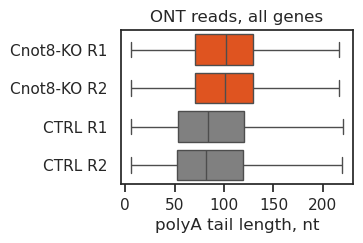

In [152]:
def get_iqr(x):
    iqr = x.quantile(0.75)-x.quantile(0.25)
    return iqr   

x_feature,x_feature_label = 'pt','polyA tail length, nt'
y_feature,y_feature_label = 'sample_label',''
order = list(metadata_df['sample_label'])
palette = list(metadata_df['color'])

comparisons = [(0,1),(2,3),(0,2),(1,3)]

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=True, figsize=(3,2))

data = reads_all_df

ax = sns.boxplot(data = data,x=x_feature,y=y_feature,palette=palette,order=order,showfliers=False)

# prev_point = 0
# for comparison in comparisons:
#     a = data.loc[data[y_feature]==order[comparison[0]]][x_feature]
#     b = data.loc[data[y_feature]==order[comparison[1]]][x_feature]
#     pval = stats.mannwhitneyu(a,b)[1]
#     star = get_pvalue_star(pval)
#     h = 0.2*get_iqr(data[x_feature].astype('float'))
#     BP_top_a = a.quantile(0.75)+1.6*get_iqr(a)
#     BP_top_b = b.quantile(0.75)+1.6*get_iqr(b)
#     start_point = max(BP_top_b,BP_top_a,prev_point)+h*3.5*int(prev_point>0)
#     cat_pos_1 = min(comparison)
#     cat_pos_2 = max(comparison)
#     ax.plot([start_point, start_point+h, start_point+h, start_point],[cat_pos_1, cat_pos_1, cat_pos_2, cat_pos_2], lw=0.5,color='black')
#     ax.text(start_point+1.3*h,0.5*(cat_pos_1+cat_pos_2), star, ha='left', va='center', color='black',size=7)
#     prev_point = start_point
#     break
ax.set(xlabel=x_feature_label,ylabel=y_feature_label,title='ONT reads, all genes')
ax.tick_params(bottom=True)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'PolyA_tail_lengths/', shell=True)
fig.savefig(subdirs['figures_dir']+'PolyA_tail_lengths/1.boxplots_with_pt.all_genes.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'PolyA_tail_lengths/1.boxplots_with_pt.all_genes.pdf',bbox_inches='tight',dpi=600)

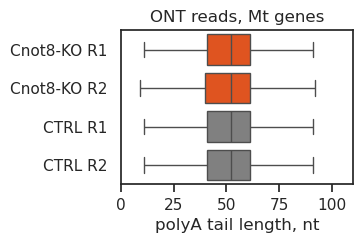

In [151]:
def get_iqr(x):
    iqr = x.quantile(0.75)-x.quantile(0.25)
    return iqr   

x_feature,x_feature_label = 'pt','polyA tail length, nt'
y_feature,y_feature_label = 'sample_label',''
order = list(metadata_df['sample_label'])
palette = list(metadata_df['color'])

comparisons = [(0,1),(2,3),(0,2),(1,3)]

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=True, figsize=(3,2))

data = reads_all_df.loc[reads_all_df['chr']=='chrM'].reset_index(drop=True)

ax = sns.boxplot(data = data,x=x_feature,y=y_feature,palette=palette,order=order,showfliers=False)

# prev_point = 0
# for comparison in comparisons:
#     a = data.loc[data[y_feature]==order[comparison[0]]][x_feature]
#     b = data.loc[data[y_feature]==order[comparison[1]]][x_feature]
#     pval = stats.mannwhitneyu(a,b)[1]
#     star = get_pvalue_star(pval)
#     h = 0.2*get_iqr(data[x_feature].astype('float'))
#     BP_top_a = a.quantile(0.75)+1.6*get_iqr(a)
#     BP_top_b = b.quantile(0.75)+1.6*get_iqr(b)
#     start_point = max(BP_top_b,BP_top_a,prev_point)+h*3.5*int(prev_point>0)
#     cat_pos_1 = min(comparison)
#     cat_pos_2 = max(comparison)
#     ax.plot([start_point, start_point+h, start_point+h, start_point],[cat_pos_1, cat_pos_1, cat_pos_2, cat_pos_2], lw=0.5,color='black')
#     ax.text(start_point+1.3*h,0.5*(cat_pos_1+cat_pos_2), star, ha='left', va='center', color='black',size=7)
#     prev_point = start_point
#     break
ax.set(xlabel=x_feature_label,ylabel=y_feature_label,title='ONT reads, Mt genes',xlim=(0,110))
ax.tick_params(bottom=True)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'PolyA_tail_lengths/', shell=True)
fig.savefig(subdirs['figures_dir']+'PolyA_tail_lengths/2.boxplots_with_pt.Mt_genes.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'PolyA_tail_lengths/2.boxplots_with_pt.Mt_genes.pdf',bbox_inches='tight',dpi=600)

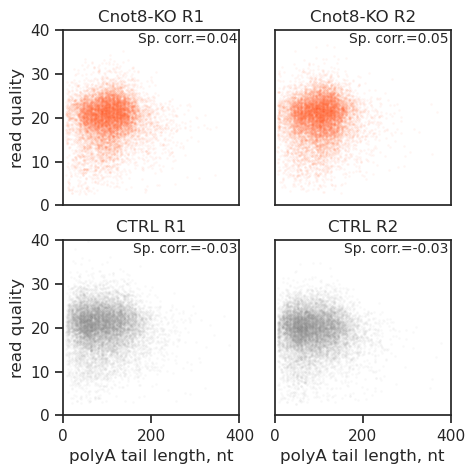

In [298]:
x_feature,x_feature_label = 'pt','polyA tail length, nt'
y_feature,y_feature_label = 'qs','read quality'
order = list(metadata_df['sample_label'])
subplot_locations = [(0,0),(0,1),(1,0),(1,1)]
palette = list(metadata_df['color'])

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(2, 2, sharey=True, sharex=True, figsize=(5,5))

k=0
for sample_label in order:
    data = reads_all_df.loc[reads_all_df['sample_label']==sample_label].sample(10000).reset_index(drop=True)
    ax = sns.scatterplot(ax=axes[subplot_locations[k][0]][subplot_locations[k][1]],
                         data = data,
                         x=x_feature,y=y_feature,
                         color=palette[k],s=3,alpha=0.05)
    spearmanrho = np.round(stats.spearmanr(data[x_feature],data[y_feature])[0],2)
    ax.set(xlim=(0,400),ylim=(0,40),title=sample_label,xlabel=x_feature_label,ylabel=y_feature_label)
    ax.text(ax.get_xlim()[1]*0.99,ax.get_ylim()[1]*0.99,r'Sp. corr.='+str(spearmanrho),size=10,ha='right',va='top')
    if k in [0,2]:
        ax.tick_params(left=True)
    if k in [2,3]:
        ax.tick_params(bottom=True)
    k=k+1

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'PolyA_tail_lengths/', shell=True)
fig.savefig(subdirs['figures_dir']+'PolyA_tail_lengths/3.PolyTLength_vs_ReadQuality.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'PolyA_tail_lengths/3.PolyTLength_vs_ReadQuality.pdf',bbox_inches='tight',dpi=600)

## PCA exression for ONT reads

In [193]:
reads_all_df['isoform_full_id'] = (reads_all_df['chr']+'_'+reads_all_df['isoform_id']).astype('category')

In [239]:
reads_all_df['t']=1
expr_matrix = pd.pivot_table(reads_all_df[['isoform_full_id','sample_label','t']],index='isoform_full_id',columns='sample_label',aggfunc=sum).reset_index()
expr_matrix.columns = expr_matrix.columns.droplevel(0)
expr_matrix = expr_matrix.rename(columns={'':'isoform_full_id'})

samples=list(metadata_df['sample_label'])
expr_matrix[samples] = expr_matrix[samples]+1 # pseudocount

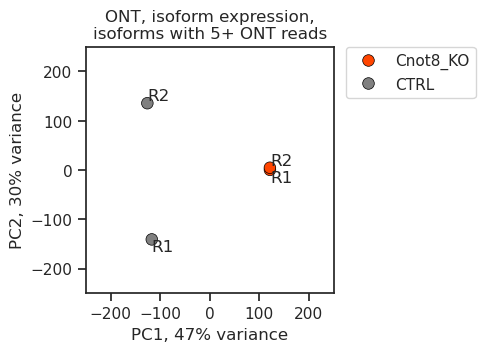

In [299]:
expr_matrix['mean']=expr_matrix[samples].mean(1)
for_SF = expr_matrix.loc[expr_matrix['mean']>expr_matrix['mean'].quantile(0.9)].reset_index(drop=True)
SFs = list(for_SF[samples].div(list(for_SF['mean']),axis=0).median(axis=0))

norm_expr_matrix = pd.concat([expr_matrix['isoform_full_id'],expr_matrix[samples].div(SFs,axis=1)],axis=1)
norm_expr_matrix['mean_raw_norm'] = norm_expr_matrix[samples].mean(1)
norm_expr_matrix['std_raw_norm'] = norm_expr_matrix[samples].std(1)

norm_expr_matrix[samples] = np.log2(norm_expr_matrix[samples]) # convert to log2

thres = 5
PCA_UMAP_subset = norm_expr_matrix.loc[norm_expr_matrix['mean_raw_norm']>thres].reset_index(drop=True)

len(PCA_UMAP_subset)
x = (PCA_UMAP_subset[samples].values).transpose()
x = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])
principalDf['sample_label'] = samples

principalDf = pd.merge(principalDf,metadata_df[['sample_label','condition','replicate']],how='left',on='sample_label')

hue='condition'
hue_order = ['Cnot8_KO', 'CTRL']
palette = ['orangered','grey']

bw_adjust = 1.75
alpha_param, s_param = 1, 70
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3.2,3.2))

# PCA and UMAP
x_feature,y_feature = 'PC1','PC2'
ax = sns.scatterplot(data = principalDf,x=x_feature,y=y_feature,s=s_param,alpha=alpha_param,edgecolor='black',linewidth=0.5,
                     hue=hue,hue_order = hue_order, palette = palette)

ax.set(xlabel = 'PC1, '+str(int(np.round(pca.explained_variance_ratio_[0]*100,0)))+'% variance')
ax.set(ylabel = 'PC2, '+str(int(np.round(pca.explained_variance_ratio_[1]*100,0)))+'% variance')

k=0
for index,row in principalDf.iterrows():
    ax.text(row[x_feature],row[y_feature],row['replicate'],va=('top' if k%2==0 else 'bottom'))
    k=k+1
ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')
ax.set(xlim=(-250,250),ylim=(-250,250),title='ONT, isoform expression,\nisoforms with '+str(thres)+'+ ONT reads')

ax.tick_params(left=True,bottom=True)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'ONT_expression/', shell=True)
fig.savefig(subdirs['figures_dir']+'ONT_expression/4.PCA_isoform_expression.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'ONT_expression/4.PCA_isoform_expression.pdf',bbox_inches='tight',dpi=600)

## PCA for illumina bulk RNA-seq

In [10]:
WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

os.system("""find """+exon_quantification_dir+""" -name '*.txt' > """+subdirs['temp_dir']+"""exon_quantific_FeatureCounts.files.txt""")
exon_quantific_FeatureCounts_files = pd.read_csv(subdirs['temp_dir']+'exon_quantific_FeatureCounts.files.txt',delimiter="\t",
                                   index_col=None,header=None)

exon_quantific_FeatureCounts_files.columns = ['path']
exon_quantific_FeatureCounts_files['sample'] = exon_quantific_FeatureCounts_files.apply(lambda x:x[0].split('/')[-1].replace('.txt',''),1)

In [11]:
i=0
a = []
for index,row in exon_quantific_FeatureCounts_files.iterrows():
    if i==0:
        row_names = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[0,1,2,3,4,5])
    tmp = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[6])
    
    a.append(tmp[6]) # take advantage of the fact that the order is the same
    print(str(i)+' done')
    i=i+1

a = np.matrix(a).transpose()
res = pd.DataFrame(a,columns = list(exon_quantific_FeatureCounts_files['sample']))

row_names.columns = ['gene_id','chr','start','end','strand','gene_length']

res_df = pd.concat([row_names,res],axis=1)

0 done
1 done
2 done
3 done


In [12]:
metadata_df = pd.DataFrame([
    ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b','Gast_123_C8'],
    ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842','Gast_125_C8'],
    ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e','Gast_123_CTRL'],
    ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2','Gast_125_CTRL'],
           ],columns=['sample','bio_id','file_id','illumina_sample'])
metadata_df['condition'] = metadata_df.apply(lambda x: '_'.join(x['sample'].split('_')[:-1]),1)
metadata_df['replicate'] = metadata_df.apply(lambda x: 'R'+str(x['sample'].split('_')[-1]),1)
metadata_df['color'] = ['orangered','orangered','grey','grey']
dict_relabel = {'Cnot8_KO_1':'Cnot8-KO R1','Cnot8_KO_2':'Cnot8-KO R2','CTRL_1':'CTRL R1','CTRL_2':'CTRL R2'}
metadata_df['sample_label'] = metadata_df['sample'].map(dict_relabel).astype('category')

In [13]:
rename_dict = {}
for index,row in metadata_df.iterrows():
    rename_dict[row['illumina_sample']] = row['sample_label']
res_df = res_df.rename(columns=rename_dict)

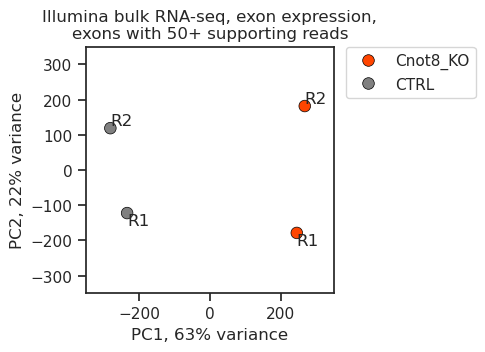

In [14]:
samples=list(metadata_df['sample_label'])

expr_matrix = res_df.copy()
expr_matrix['min'] = expr_matrix[samples].min(1)
pseudocount = expr_matrix.loc[expr_matrix['min']>0]['min'].min()
expr_matrix[samples] = expr_matrix[samples]+pseudocount # pseudocount

expr_matrix['mean']=expr_matrix[samples].mean(1)
for_SF = expr_matrix.loc[expr_matrix['mean']>expr_matrix['mean'].quantile(0.9)].reset_index(drop=True)
SFs = list(for_SF[samples].div(list(for_SF['mean']),axis=0).median(axis=0))

norm_expr_matrix = pd.concat([expr_matrix['gene_id'],expr_matrix[samples].div(SFs,axis=1)],axis=1)
norm_expr_matrix['mean_raw_norm'] = norm_expr_matrix[samples].mean(1)
norm_expr_matrix['std_raw_norm'] = norm_expr_matrix[samples].std(1)

norm_expr_matrix[samples] = np.log2(norm_expr_matrix[samples]) # convert to log2

thres = 50
PCA_UMAP_subset = norm_expr_matrix.loc[norm_expr_matrix['mean_raw_norm']>thres].reset_index(drop=True)

len(PCA_UMAP_subset)
x = (PCA_UMAP_subset[samples].values).transpose()
x = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])
principalDf['sample_label'] = samples

principalDf = pd.merge(principalDf,metadata_df[['sample_label','condition','replicate']],how='left',on='sample_label')

hue='condition'
hue_order = ['Cnot8_KO', 'CTRL']
palette = ['orangered','grey']

bw_adjust = 1.75
alpha_param, s_param = 1, 70
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3.2,3.2))

# PCA and UMAP
x_feature,y_feature = 'PC1','PC2'
ax = sns.scatterplot(data = principalDf,x=x_feature,y=y_feature,s=s_param,alpha=alpha_param,edgecolor='black',linewidth=0.5,
                     hue=hue,hue_order = hue_order, palette = palette)

ax.set(xlabel = 'PC1, '+str(int(np.round(pca.explained_variance_ratio_[0]*100,0)))+'% variance')
ax.set(ylabel = 'PC2, '+str(int(np.round(pca.explained_variance_ratio_[1]*100,0)))+'% variance')

k=0
for index,row in principalDf.iterrows():
    ax.text(row[x_feature],row[y_feature],row['replicate'],va=('top' if k%2==0 else 'bottom'))
    k=k+1
ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')
ax.set(xlim=(-350,350),ylim=(-350,350),title='Illumina bulk RNA-seq, exon expression,\nexons with '+str(thres)+'+ supporting reads')

ax.tick_params(left=True,bottom=True)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'Illumina_vs_ONT/', shell=True)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/6.Illumina.PCA_exon_expression.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/6.Illumina.PCA_exon_expression.pdf',bbox_inches='tight',dpi=600)

## Compare exon expression between Illumina and ONT

In [5]:
metadata_df = pd.DataFrame([
    ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b','Gast_123_C8'],
    ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842','Gast_125_C8'],
    ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e','Gast_123_CTRL'],
    ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2','Gast_125_CTRL'],
           ],columns=['sample','bio_id','file_id','illumina_sample'])

# metadata_df = pd.DataFrame([
#     ['Cnot8_KO_1','p32592_o35831_1','20240813_1724_X1_FAZ60491_8451cb8b','Gast_123_C8'],
#     ['Cnot8_KO_2','p32592_o35831_2','20240813_1749_X2_FAZ60547_f5851842','Gast_125_C8'],
#     ['CTRL_1','p32592_o35831_3','20240813_1749_X3_FAZ60875_f215937e','Gast_123_CTRL'],
#     ['CTRL_2','p32592_o35831_4','20240813_1749_X4_FAZ61052_010889e2','Gast_125_CTRL'],
#            ],columns=['sample','bio_id','file_id','illumina_sample'])

metadata_df['condition'] = metadata_df.apply(lambda x: '_'.join(x['sample'].split('_')[:-1]),1)
metadata_df['replicate'] = metadata_df.apply(lambda x: 'R'+str(x['sample'].split('_')[-1]),1)
metadata_df['color'] = ['orangered','orangered','grey','grey']
dict_relabel = {'Cnot8_KO_1':'Cnot8-KO R1','Cnot8_KO_2':'Cnot8-KO R2','CTRL_1':'CTRL R1','CTRL_2':'CTRL R2'}
metadata_df['sample_label'] = metadata_df['sample'].map(dict_relabel).astype('category')

In [6]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

os.system("""find """+exon_quantification_dir+""" -name '*.txt' > """+subdirs['temp_dir']+"""exon_quantific_FeatureCounts.files.txt""")
exon_quantific_FeatureCounts_files = pd.read_csv(subdirs['temp_dir']+'exon_quantific_FeatureCounts.files.txt',delimiter="\t",
                                   index_col=None,header=None)

exon_quantific_FeatureCounts_files.columns = ['path']
exon_quantific_FeatureCounts_files['sample'] = exon_quantific_FeatureCounts_files.apply(lambda x:x[0].split('/')[-1].replace('.txt',''),1)

i=0
a = []
for index,row in exon_quantific_FeatureCounts_files.iterrows():
    if i==0:
        row_names = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[0,1,2,3,4,5])
    tmp = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[6])
    
    a.append(tmp[6]) # take advantage of the fact that the order is the same
    print(str(i)+' done')
    i=i+1

a = np.matrix(a).transpose()
res = pd.DataFrame(a,columns = list(exon_quantific_FeatureCounts_files['sample']))

row_names.columns = ['gene_id','chr','start','end','strand','gene_length']

res_df = pd.concat([row_names,res],axis=1)

rename_dict = {}
for index,row in metadata_df.iterrows():
    rename_dict[row['sample']] = 'ONT:'+row['sample_label']
res_df_ONT = res_df.rename(columns=rename_dict)

0 done
1 done
2 done
3 done


In [7]:
WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'

os.system("""find """+exon_quantification_dir+""" -name '*.txt' > """+subdirs['temp_dir']+"""exon_quantific_FeatureCounts.files.txt""")
exon_quantific_FeatureCounts_files = pd.read_csv(subdirs['temp_dir']+'exon_quantific_FeatureCounts.files.txt',delimiter="\t",
                                   index_col=None,header=None)

exon_quantific_FeatureCounts_files.columns = ['path']
exon_quantific_FeatureCounts_files['sample'] = exon_quantific_FeatureCounts_files.apply(lambda x:x[0].split('/')[-1].replace('.txt',''),1)

i=0
a = []
for index,row in exon_quantific_FeatureCounts_files.iterrows():
    if i==0:
        row_names = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[0,1,2,3,4,5])
    tmp = pd.read_csv(row['path'],delimiter="\t",index_col=None,header=None,skiprows=2,usecols=[6])
    
    a.append(tmp[6]) # take advantage of the fact that the order is the same
    print(str(i)+' done')
    i=i+1

a = np.matrix(a).transpose()
res = pd.DataFrame(a,columns = list(exon_quantific_FeatureCounts_files['sample']))

row_names.columns = ['gene_id','chr','start','end','strand','gene_length']

res_df = pd.concat([row_names,res],axis=1)

rename_dict = {}
for index,row in metadata_df.iterrows():
    rename_dict[row['illumina_sample']] = 'Illumina:'+row['sample_label']
res_df_Illumina = res_df.rename(columns=rename_dict)

0 done
1 done
2 done
3 done


In [8]:
res_df = pd.merge(res_df_ONT,res_df_Illumina,how='outer',on=['gene_id', 'chr', 'start', 'end', 'strand', 'gene_length'])

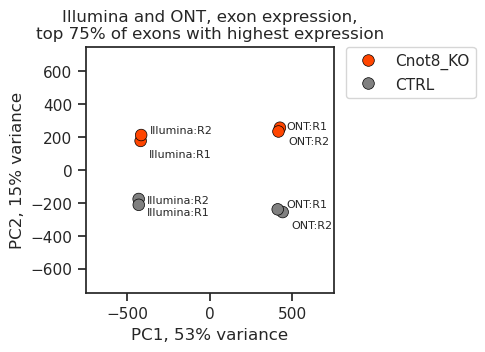

In [9]:
samples=list(res_df.columns[6:])

illumina_samples = [elem for elem in samples if elem.startswith('Illumina:')]

expr_matrix = res_df.copy()
expr_matrix['min'] = expr_matrix[samples].min(1)
pseudocount = expr_matrix.loc[expr_matrix['min']>0]['min'].min()
expr_matrix[samples] = expr_matrix[samples]+pseudocount # minimum positive pseudocount

expr_matrix['mean']=expr_matrix[illumina_samples].mean(1)
for_SF = expr_matrix.loc[expr_matrix['mean']>expr_matrix['mean'].quantile(0.9)].reset_index(drop=True)
for_SF['mean']=for_SF[samples].mean(1)
SFs = list(for_SF[samples].div(list(for_SF['mean']),axis=0).median(axis=0))

norm_expr_matrix = pd.concat([expr_matrix['gene_id'],expr_matrix[samples].div(SFs,axis=1)],axis=1)
norm_expr_matrix['mean_raw_norm'] = norm_expr_matrix[samples].mean(1)
norm_expr_matrix['std_raw_norm'] = norm_expr_matrix[samples].std(1)

norm_expr_matrix[samples] = np.log2(norm_expr_matrix[samples]) # convert to log2

PCA_UMAP_subset = norm_expr_matrix.loc[norm_expr_matrix['mean_raw_norm']>norm_expr_matrix['mean_raw_norm'].quantile(0.25)].reset_index(drop=True)

len(PCA_UMAP_subset)
x = (PCA_UMAP_subset[samples].values).transpose()
x = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])
principalDf['sample_mod'] = samples

principalDf['sample_label'] = principalDf.apply(lambda x:x['sample_mod'].split(':')[1],1)
principalDf['assay'] = principalDf.apply(lambda x:x['sample_mod'].split(':')[0],1)
principalDf = pd.merge(principalDf,metadata_df[['sample_label','condition','replicate']],how='left',on='sample_label')

hue='condition'
hue_order = ['Cnot8_KO', 'CTRL']
palette = ['orangered','grey']

bw_adjust = 1.75
alpha_param, s_param = 1, 70
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3.2,3.2))

# PCA and UMAP
x_feature,y_feature = 'PC1','PC2'
ax = sns.scatterplot(data = principalDf,x=x_feature,y=y_feature,s=s_param,alpha=alpha_param,edgecolor='black',linewidth=0.5,
                     hue=hue,hue_order = hue_order, palette = palette)

ax.set(xlabel = 'PC1, '+str(int(np.round(pca.explained_variance_ratio_[0]*100,0)))+'% variance')
ax.set(ylabel = 'PC2, '+str(int(np.round(pca.explained_variance_ratio_[1]*100,0)))+'% variance')

k=0
for index,row in principalDf.iterrows():
    ax.text(row[x_feature]+50,row[y_feature]-(50 if k%2==0 else 0),row['assay']+':'+row['replicate'],va=('top' if k%2==0 else 'bottom'),size=8)
    k=k+1
ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='')
ax.set(xlim=(-750,750),ylim=(-750,750),title='Illumina and ONT, exon expression,\ntop 75% of exons with highest expression')

ax.tick_params(left=True,bottom=True)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'Illumina_vs_ONT/', shell=True)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/7.Illumina_and_ONT.PCA_exon_expression.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/7.Illumina_and_ONT.PCA_exon_expression.pdf',bbox_inches='tight',dpi=600)

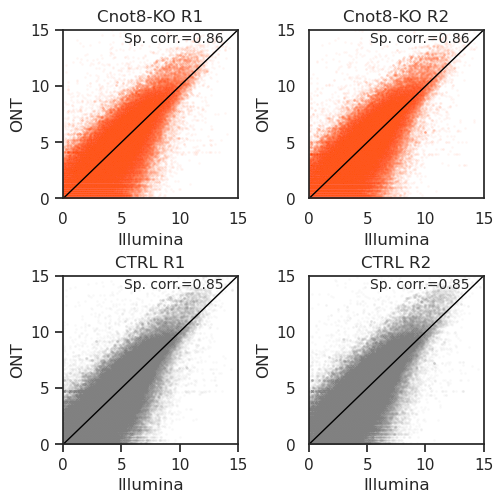

In [10]:
# make scatterplots for every sample
metadata_df['sample_label_Illumina'] = 'Illumina:'+metadata_df['sample_label'].astype('str')
metadata_df['sample_label_ONT'] = 'ONT:'+metadata_df['sample_label'].astype('str')

subplot_locations = [(0,0),(0,1),(1,0),(1,1)]
palette = list(metadata_df['color'])

lims = (0,15)
diag_df = pd.DataFrame([lims,lims]).transpose()

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(2, 2, sharey=False, sharex=False, figsize=(5,5))

k=0
for index,row in metadata_df.iterrows():
    
    x_feature = row['sample_label_Illumina']
    y_feature = row['sample_label_ONT']
    data = norm_expr_matrix
    ax = sns.scatterplot(ax=axes[subplot_locations[k][0]][subplot_locations[k][1]],
                         data = data,
                         x=x_feature,y=y_feature,
                         color=palette[k],s=3,alpha=0.05)
    

    diag_df.columns = [x_feature,y_feature]
    ax = sns.lineplot(ax=axes[subplot_locations[k][0]][subplot_locations[k][1]],
                         data = diag_df,
                         x=x_feature,y=y_feature,
                         color='black',linewidth=1)    
    ax.set(xlim=lims,ylim=lims,title=row['sample_label'],xlabel='Illumina',ylabel='ONT')
    spearmanrho = np.round(stats.spearmanr(data[x_feature],data[y_feature])[0],2)
    ax.text(ax.get_xlim()[1]*0.92,ax.get_ylim()[1]*0.99,r'Sp. corr.='+str(spearmanrho),size=10,ha='right',va='top')
    if k in [0,2]:
        ax.tick_params(left=True)
    if k in [2,3]:
        ax.tick_params(bottom=True)
    
    
    k=k+1
fig.tight_layout(pad=0.5)
out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'Illumina_vs_ONT/', shell=True)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/8.Illumina_and_ONT.pairwise_scatterplots.log2_normalized_exon_expression.png',bbox_inches='tight',dpi=600)
# fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/8.Illumina_and_ONT.pairwise_scatterplots.pdf',bbox_inches='tight',dpi=600) # pdf is too large

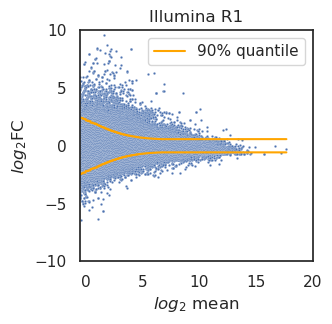

In [11]:
# do differential analysis

conditions = ['Cnot8_KO','CTRL']
replicates = ['R1','R2']
assays = ['Illumina','ONT']

data = norm_expr_matrix.loc[norm_expr_matrix['mean_raw_norm']>0].reset_index(drop=True)

# rolling window estimation
def get_rolling_estimate(data):

    data = data.sort_values('log2_mean').reset_index(drop=True)
    
    def rolling_func(x):
        return np.quantile(x,q=0.9)
    
    window = int(len(data)*0.05)
    step = int(len(data)*0.01)
    data_vals = list(data['lfc_abs'])
    a = []
    for i in range(window,len(data)-window,step):
        val = rolling_func(data_vals[i-window:i+window])
        for k in range(i,min(i+step,len(data)-window)):
            a.append(val)
    
    
    # make linear interference for start
    first_change = a[0]-a[1]
    anchor_point = a[0]
    a_start = []
    for i in range(step,window,step):
        val = anchor_point+first_change*(window-i)
        for k in range(i-step,i):
            a_start.append(val)
    if i<window:
        val = anchor_point+first_change*(window-i)
        for k in range(i,window):
            a_start.append(val)
        
    # make linear interference for end
    first_change = a[-1]-a[-2]
    anchor_point = a[-1]
    a_end = []
    for i in range(len(data)-window,len(data),step):
        val = anchor_point+first_change*(i-(len(data)-window))
        for k in range(i,min(i+step,len(data))):
            a_end.append(val)
    data['rolling_func_val'] = a_start+a+a_end
    return data

a = []
new_features = []
k=0
for assay in assays:
    for replicate in replicates:
        sample_EXP = metadata_df.loc[(metadata_df['replicate']==replicate)&(metadata_df['condition']==conditions[0])]['sample_label_'+assay].iloc[0]
        sample_CTL = metadata_df.loc[(metadata_df['replicate']==replicate)&(metadata_df['condition']==conditions[1])]['sample_label_'+assay].iloc[0]
        data['lfc'] = data[sample_EXP]-data[sample_CTL]
        data['log2_mean'] = 0.5*(data[sample_EXP]+data[sample_CTL])
        data['lfc_abs'] = abs(data['lfc'])
        data = get_rolling_estimate(data)
        feature_name = assay+':DE '+str(replicate)
        data[feature_name] = (data['lfc_abs']>data['rolling_func_val']).astype('int')*((data['lfc']>0).astype('int')*2-1)
        new_features.append(feature_name)
        if k==0:
            indices_sampling = list(range(0,len(data),100))+[len(data)-1]
            sns.set(font_scale=1)
            sns.set_style("white")
            fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3,3))
            
            ax = sns.scatterplot(data = data,x='log2_mean',y='lfc',s=3,)
            ax = sns.lineplot(data = data.iloc[indices_sampling],x='log2_mean',y='rolling_func_val',color='orange',label='90% quantile')
            data['rolling_func_val'] = data['rolling_func_val']*(-1)
            ax = sns.lineplot(data = data.iloc[indices_sampling],x='log2_mean',y='rolling_func_val',color='orange')
            data['rolling_func_val'] = data['rolling_func_val']*(-1) # revert back
            
            ax.set(xlim=(-0.5,20),ylim=(-10,10),xlabel='$log_2$ mean',ylabel='$log_2$FC',title=assay+' '+str(replicate))
            out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'Illumina_vs_ONT/', shell=True)
            fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/9.MA_plot_within_replicate.example.png',bbox_inches='tight',dpi=600)
        k=k+1

In [190]:
len(data.loc[data['Illumina:DE R1']!=0]),len(data.loc[data['Illumina:DE R2']!=0]),len(data.loc[data['ONT:DE R1']!=0]),len(data.loc[data['ONT:DE R2']!=0])

(30610, 30028, 22267, 23716)

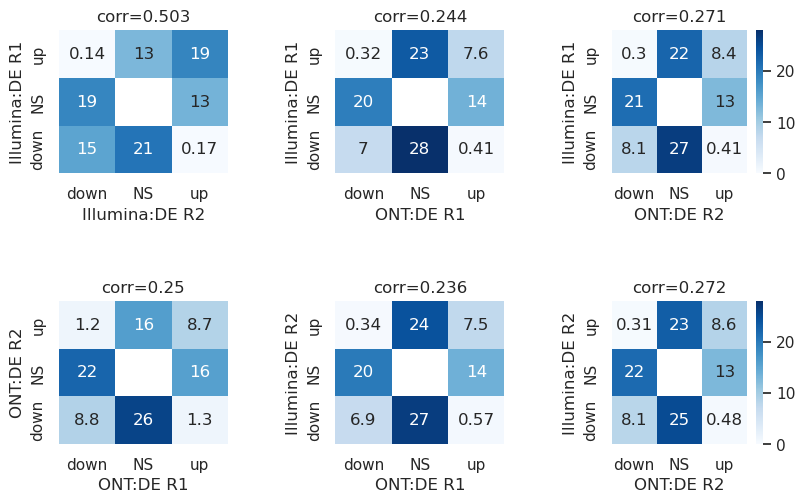

In [17]:
data['t']=1

feature_pairs = [[['Illumina:DE R1','Illumina:DE R2'],['Illumina:DE R1','ONT:DE R1'],['Illumina:DE R1','ONT:DE R2']],
                 [['ONT:DE R2','ONT:DE R1'],['Illumina:DE R2','ONT:DE R1'],['Illumina:DE R2','ONT:DE R2']]
                ]

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(2, 3, sharey=False, sharex=False, figsize=(9,6))

i=0
for feature_pair_list in feature_pairs:
    j=0
    for feature_pair in feature_pair_list:
    
        gr = data.groupby(feature_pair).agg({'t':sum}).reset_index()
        gr = gr.loc[~((gr[feature_pair].sum(axis=1)==0)&(gr[feature_pair].prod(axis=1)==0))]
        
        pivot = pd.pivot_table(gr,index=feature_pair[1],columns=feature_pair[0])
        pivot.columns = pivot.columns.droplevel(0)
        pivot = (pivot/pivot.sum().sum()).transpose().sort_index(ascending=False)
        pivot = np.round(pivot*100,2)

        corr = np.round(stats.spearmanr(data[feature_pair[0]],data[feature_pair[1]])[0],3)
        
        ax = sns.heatmap(ax=axes[i][j],data = pivot, annot=True, cmap=sns.color_palette("Blues", as_cmap=True),
                         vmin=0,vmax=28,
                        cbar = (True if j==2 else False))
        ax.set(title='corr='+str(corr),xticklabels=['down','NS','up'],yticklabels=['up','NS','down'])
        j=j+1
    i=i+1
fig.tight_layout(pad=3.5)
out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'Illumina_vs_ONT/', shell=True)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/10.Outlier_correlations.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/10.Outlier_correlations.pdf',bbox_inches='tight',dpi=600)

## Analyze Deseq2 results (exon quantification) for ONT and Illumina, to identify bad and good exons 

In [57]:
fdr_thr = 0.05

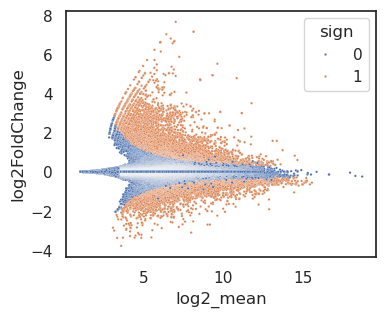

In [67]:
WF_version = 'v1_bulk'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'
deseq_dir = exon_quantification_dir+'deseq/'
DE_table_path = deseq_dir+'DE_table.tsv'

DE_table = pd.read_csv(DE_table_path,delimiter="\t",index_col=None,header=0)
DE_table = DE_table.rename(columns={'gene_name':'gene_id'})
DE_table['log2FoldChange'] = DE_table['log2FoldChange'].fillna(0)
DE_table['pvalue'] = DE_table['pvalue'].fillna(1)
DE_table['fdr'] = multipletests(DE_table['pvalue'],method='fdr_bh')[1]
DE_table['log2_mean'] = np.log2(DE_table['baseMean']+1)
# DE_table['sign'] = ((DE_table['fdr']<fdr_thr)&(~((abs(DE_table['log2_mean'])<7)&(abs(DE_table['log2FoldChange'])<1)))).astype('int')
DE_table['sign'] = ((DE_table['fdr']<fdr_thr)).astype('int')
DE_table['DGE_Illumina'] = (DE_table['sign']==1).astype('int')*((DE_table['log2FoldChange']>0).astype('int')*2-1)

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

ax = sns.scatterplot(data = DE_table,x='log2_mean',y='log2FoldChange',hue='sign',s=3)

DE_table_Illumina = DE_table.copy()

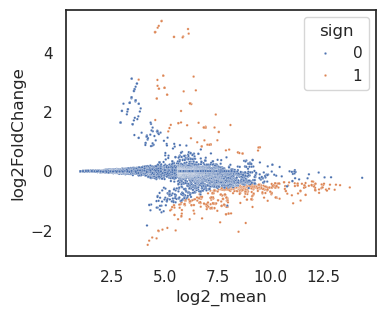

In [68]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
exon_quantification_dir = expression_quantification_dir+'exon_quantification/'
deseq_dir = exon_quantification_dir+'deseq/'
DE_table_path = deseq_dir+'DE_table.tsv'

DE_table = pd.read_csv(DE_table_path,delimiter="\t",index_col=None,header=0)
DE_table = DE_table.rename(columns={'gene_name':'gene_id'})
DE_table['log2FoldChange'] = DE_table['log2FoldChange'].fillna(0)
DE_table['pvalue'] = DE_table['pvalue'].fillna(1)
DE_table['fdr'] = multipletests(DE_table['pvalue'],method='fdr_bh')[1]
DE_table['log2_mean'] = np.log2(DE_table['baseMean']+1)
# DE_table['sign'] = ((DE_table['fdr']<fdr_thr)&(~((abs(DE_table['log2_mean'])<7)&(abs(DE_table['log2FoldChange'])<1)))).astype('int')
DE_table['sign'] = ((DE_table['fdr']<fdr_thr)).astype('int')
DE_table['DGE_ONT'] = (DE_table['sign']==1).astype('int')*((DE_table['log2FoldChange']>0).astype('int')*2-1)

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

ax = sns.scatterplot(data = DE_table,x='log2_mean',y='log2FoldChange',hue='sign',s=3)

DE_table_ONT = DE_table.copy()

In [71]:
DGE_exons = pd.merge(DE_table_ONT[['gene_id','DGE_ONT']],DE_table_Illumina[['gene_id','DGE_Illumina']],how='outer',on='gene_id')

In [73]:
DGE_exons[['DGE_ONT','DGE_Illumina']] = DGE_exons[['DGE_ONT','DGE_Illumina']].fillna(0).astype('int')

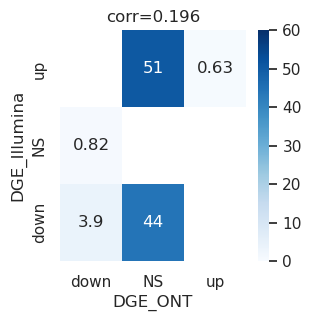

In [82]:
data = DGE_exons.copy()
data['t']=1
feature_pair = ['DGE_Illumina','DGE_ONT']
gr = data.groupby(feature_pair).agg({'t':sum}).reset_index()

gr = gr.loc[~((gr[feature_pair].sum(axis=1)==0)&(gr[feature_pair].prod(axis=1)==0))]

pivot = pd.pivot_table(gr,index=feature_pair[1],columns=feature_pair[0])
pivot.columns = pivot.columns.droplevel(0)
pivot = (pivot/pivot.sum().sum()).transpose().sort_index(ascending=False)
pivot = np.round(pivot*100,5)

corr = np.round(stats.spearmanr(data[feature_pair[0]],data[feature_pair[1]])[0],3)

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3,3))

ax = sns.heatmap(data = pivot, annot=True, cmap=sns.color_palette("Blues", as_cmap=True),
             vmin=0,vmax=60,
            cbar = True)
ax.set(title='corr='+str(corr),xticklabels=['down','NS','up'],yticklabels=['up','NS','down'])
out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'Illumina_vs_ONT/', shell=True)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/11.Deseq_exonDGE_comparison.png',bbox_inches='tight',dpi=600)
fig.savefig(subdirs['figures_dir']+'Illumina_vs_ONT/11.Deseq_exonDGE_comparison.pdf',bbox_inches='tight',dpi=600)

In [ ]:
# so, no bad exons with opposite direction of effects

## Quantify ONT-derived differential isoform expression

In [11]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
final_read_assignment_dir = general_output_dir+'final_read_assignment/'

reads_all_df = pd.read_csv(final_read_assignment_dir+'reads_all_df.tsv',delimiter="\t",index_col=None,header=0)
isoforms_all_df = pd.read_csv(final_read_assignment_dir+'isoforms_all_df.tsv',delimiter="\t",index_col=None,header=0)
transcripts_all_df = pd.read_csv(final_read_assignment_dir+'transcripts_all_df.tsv',delimiter="\t",index_col=None,header=0)
transcripts_all_df = transcripts_all_df.rename(columns={'transcript_id':'annotated_transcript_id'})
sample_metadata_df = pd.read_csv(final_read_assignment_dir+'sample_metadata_df.tsv',delimiter="\t",index_col=None,header=0)

In [12]:
isoforms_all_df.loc[~isoforms_all_df['annotated_transcript_id'].isna()].head()

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id
9,chr1,+,"10066426,10065421,10065323,10064413,10064333,1...",279,10039773,10067976,11_+,12,2162,ENSMUST00000118263.7
22,chr1,+,"10135934,10134230,10134092,10133273,10133164,1...",297,10038217,10136768,24_+,58,4355,ENSMUST00000071087.11
41,chr1,+,"105456785,105456783",3831,105455971,105458829,43_+,2,2858,ENSMUST00000086725.5
51,chr1,+,"105753503,105751043,105750973,105750410,105750...",3851,105663883,105754081,53_+,56,4334,ENSMUST00000039173.12
58,chr1,+,"105753503,105751043,105750973,105750410,105750...",3853,105663913,105755191,61_+,56,5414,ENSMUST00000086721.9


In [75]:
gtf = pd.read_csv(file_paths['mouse_annotation_file'],delimiter="\t",index_col=None,header=None,skiprows=5)

# extract gene elements
genes = gtf.loc[gtf[2]=='gene'].reset_index(drop=True)
genes['gene_name'] = genes[8].str.split('gene_name "',expand=True)[1].str.split('";',expand=True)[0]

In [98]:
# For CNOT8, observed transcripts are not compatible with any of the annotated ones.
# So, we'll additionally do a dirty assignment of isoforms to gene loci
isoforms_all_df['t']=1
isoforms_all_df_bed = isoforms_all_df[['chr','isoform_start','isoform_end','isoform_id','t','strand']]
isoforms_all_df_bed['isoform_start'] = isoforms_all_df_bed['isoform_start']-1
isoforms_all_df_bed.to_csv(subdirs['temp_dir']+'isoforms_all_df.bed',sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

genes['t']=1
genes_bed = genes[[0,3,4,'gene_name','t',6]]
genes_bed.to_csv(subdirs['temp_dir']+'genes.bed',sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

temp_dir_path = subdirs['temp_dir']

command = 'bedtools sort -i '+temp_dir_path+'isoforms_all_df.bed'+' > '+temp_dir_path+'isoforms_all_df.sorted.bed'
out = subprocess.check_output(command, shell=True)

command = 'bedtools sort -i '+temp_dir_path+'genes.bed'+' > '+temp_dir_path+'genes.sorted.bed'
out = subprocess.check_output(command, shell=True)

command = 'bedtools intersect -s -sorted -wa -wb -a '+temp_dir_path+'isoforms_all_df.sorted.bed'+' -b '+temp_dir_path+'genes.sorted.bed > '+temp_dir_path+'isoform_gene_intersected.bed'
out = subprocess.check_output(command, shell=True)

isoform_gene_intersected = pd.read_csv(temp_dir_path+'isoform_gene_intersected.bed',delimiter="\t",index_col=None,header=None)
isoform_gene_intersected = isoform_gene_intersected[[0,3,9]]

dirty_gene_assignment = pd.concat([isoform_gene_intersected[[0,3]],isoform_gene_intersected.groupby([0,3])[9].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True)
dirty_gene_assignment.columns = ['chr','isoform_id','dirty_gene_name']

In [100]:
if 'dirty_gene_name' in list(isoforms_all_df.columns):
    isoforms_all_df = isoforms_all_df.drop(['dirty_gene_name'],axis=1)

isoforms_all_df = pd.merge(isoforms_all_df,dirty_gene_assignment,how='left',on=['chr','isoform_id'])
isoforms_all_df['dirty_gene_name'] = isoforms_all_df['dirty_gene_name'].fillna('')

In [13]:
reads_all_df['sample_index'] = reads_all_df['read_id'].str.split(';',expand=True)[0].astype('int')

In [ ]:
reads_all_df['isoform_full_id'] = (reads_all_df['chr']+'_'+reads_all_df['isoform_id']).astype('category')
isoforms_all_df['isoform_full_id'] = (isoforms_all_df['chr']+'_'+isoforms_all_df['isoform_id']).astype('category')

In [14]:
metadata_df = sample_metadata_df[['sample','sample_index']].drop_duplicates().reset_index(drop=True)

In [15]:
metadata_df['condition'] = metadata_df.apply(lambda x: '_'.join(x['sample'].split('_')[:-1]),1)
metadata_df['replicate'] = metadata_df.apply(lambda x: 'R'+str(x['sample'].split('_')[-1]),1)
metadata_df['color'] = ['orangered','orangered','grey','grey']
dict_relabel = {'Cnot8_KO_1':'Cnot8-KO R1','Cnot8_KO_2':'Cnot8-KO R2','CTRL_1':'CTRL R1','CTRL_2':'CTRL R2'}
metadata_df['sample_label'] = metadata_df['sample'].map(dict_relabel).astype('category')

In [22]:
if 'sample_label' in list(reads_all_df.columns):
    reads_all_df = reads_all_df.drop(['sample_label'],axis=1)
if 'sample' in list(reads_all_df.columns):
    reads_all_df = reads_all_df.drop(['sample'],axis=1)
reads_all_df = pd.merge(reads_all_df,metadata_df[['sample_index','sample','sample_label']],how='left',on='sample_index')

In [182]:
reads_all_df['t']=1
expr_matrix = pd.pivot_table(reads_all_df[['isoform_full_id','sample','t']],index='isoform_full_id',columns='sample',aggfunc=sum).reset_index()
expr_matrix.columns = expr_matrix.columns.droplevel(0)
expr_matrix = expr_matrix.rename(columns={'':'isoform_full_id'})

sample_cols=list(metadata_df['sample'])

metadata_df['EXP_CTL'] = metadata_df.apply(lambda x:('EXP' if x['condition']=='Cnot8_KO' else 'CTL'),1)

counts_df = expr_matrix[['isoform_full_id']+sample_cols]
counts_df[sample_cols] = np.round(counts_df[sample_cols],0).astype('int')
counts_df = counts_df.loc[counts_df[sample_cols].min(axis=1)>=1].reset_index(drop=True)

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
quantification_dir = expression_quantification_dir+'full_isoform_quantification/'
deseq_dir = quantification_dir+'deseq/'

out = subprocess.check_output('mkdir -p '+deseq_dir, shell=True)

counts_file_path = deseq_dir+'counts.tsv'
metadata_file_path = deseq_dir+'metadata.tsv'
outdir_path = deseq_dir

counts_df.to_csv(counts_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)
metadata_df[['sample','EXP_CTL']].to_csv(metadata_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

command = """Rscript """+subdirs['wf_dir']+'scripts/run_deseq2.r'+' '+counts_file_path+' '+metadata_file_path+' EXP '+outdir_path+' fake_gene; '
command

'Rscript /scicore/home/zavolan/mirono0000/Projects/Regulation_of_gastrulation/WF/scripts/run_deseq2.r /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/expression_quantification/full_isoform_quantification/deseq/counts.tsv /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/expression_quantification/full_isoform_quantification/deseq/metadata.tsv EXP /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/expression_quantification/full_isoform_quantification/deseq/ fake_gene; '

In [215]:
DE_table_path = deseq_dir+'DE_table.tsv'
fdr_thr = 0.05

DE_table = pd.read_csv(DE_table_path,delimiter="\t",index_col=None,header=0)
DE_table = DE_table.rename(columns={'gene_name':'isoform_full_id'})
DE_table['log2FoldChange'] = DE_table['log2FoldChange'].fillna(0)
DE_table['pvalue'] = DE_table['pvalue'].fillna(1)
DE_table['fdr'] = multipletests(DE_table['pvalue'],method='fdr_bh')[1]
DE_table['log2_mean'] = np.log2(DE_table['baseMean']+1)
# DE_table['sign'] = ((DE_table['fdr']<fdr_thr)&(~((abs(DE_table['log2_mean'])<7)&(abs(DE_table['log2FoldChange'])<1)))).astype('int')
DE_table['sign'] = ((DE_table['fdr']<fdr_thr)).astype('int')
DE_table['sign_label'] = DE_table['sign'].astype('str').str.replace('1','FDR<'+str(fdr_thr)).replace('0','NS').astype('category')
DE_table['DGE'] = (DE_table['sign']==1).astype('int')*((DE_table['log2FoldChange']>0).astype('int')*2-1)
map_dict = {-1:'down',0:'NS',1:'up'}
DE_table['DGE_label'] = DE_table['DGE'].map(map_dict)

DE_table['isoform_full_id'] = DE_table['isoform_full_id'].astype('category')
DE_table = pd.merge(DE_table,isoforms_all_df[['isoform_full_id','annotated_transcript_id','dirty_gene_name']],how='left',on='isoform_full_id')
DE_table = pd.merge(DE_table,transcripts_all_df[['annotated_transcript_id','gene_name']],how='left',on='annotated_transcript_id')

In [216]:
DE_table.loc[DE_table['dirty_gene_name'].str.contains('|'.join(['Cnot8']))]

,isoform_full_id,baseMean,log2FoldChange,pvalue,padj,fdr,log2_mean,sign,sign_label,DGE,DGE_label,annotated_transcript_id,dirty_gene_name,gene_name
1063,chr11_6714_+,20.156984,-0.764308,0.009071,0.098041,0.361571,4.403062,0,NS,0,NS,NaN,Cnot8,NaN
15493,chr11_6711_+,3.071340,-0.025076,0.468597,NaN,0.998682,2.025504,0,NS,0,NS,NaN,Cnot8,NaN
15495,chr11_6716_+,11.434155,-3.154724,0.000113,NaN,0.014513,3.636237,1,FDR<0.05,-1,down,NaN,Cnot8,NaN
15496,chr11_6717_+,15.078685,-1.131902,0.005405,NaN,0.260085,4.007078,0,NS,0,NS,NaN,Cnot8,NaN
15499,chr11_6720_+,6.714167,-0.153241,0.008969,NaN,0.360111,2.947510,0,NS,0,NS,NaN,Cnot8,NaN


In [217]:
isoforms_all_df.loc[isoforms_all_df['isoform_full_id']=='chr11_6716_+']

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id,isoform_full_id,t,dirty_gene_name
224186,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2505,58103992,58117847,6716_+,12,1449,NaN,chr11_6716_+,1,Cnot8


CPU times: user 121 ms, sys: 0 ns, total: 121 ms
Wall time: 121 ms


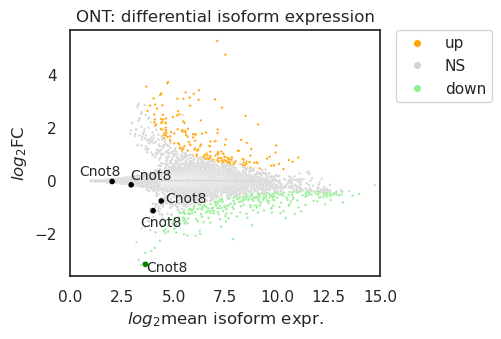

In [221]:
genes_to_show = ['Cnot8']
x_feature,y_feature,hue_feature = 'log2_mean','log2FoldChange','DGE_label'
hue_order = ['up','NS','down']
palette = ['orange','lightgrey','lightgreen']
data = DE_table.copy()

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

ax = sns.scatterplot(data = data,x=x_feature,y=y_feature,hue=hue_feature,hue_order = hue_order,s=3,palette=palette)

data_sel = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_to_show))].reset_index(drop=True)
ax = sns.scatterplot(data = data_sel,x=x_feature,y=y_feature,hue=hue_feature,hue_order = hue_order,s=20,palette=['orangered','black','green'],legend=False)
ax.set(xlim=(0,15))
texts = []
for index,row in data_sel.iterrows():
    texts.append(ax.annotate(row['dirty_gene_name'],(row[x_feature],row[y_feature]),ha='center',va='center',size=10))
%time adjust_text(texts,arrowprops=dict(arrowstyle='-', color='black'),ax=ax,force_points=(3,3),min_arrow_len=15)

ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='',markerscale=3)
ax.set(ylabel='$log_2$FC',xlabel='$log_2$mean isoform expr.',title='ONT: differential isoform expression')

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis/', shell=True)
fig.savefig(subdirs['figures_dir']+'differential_analysis/12.Deseq_ONT_isoform_expression.png',bbox_inches='tight',dpi=600)
# fig.savefig(subdirs['figures_dir']+'differential_analysis/12.Deseq_ONT_isoform_expression.pdf',bbox_inches='tight',dpi=600)

In [222]:
# differential polyA tail lengths

reads_all_df['pt']=reads_all_df['pt'].astype('float')
gr = reads_all_df.groupby(['isoform_full_id','sample']).agg({'pt':np.mean}).reset_index()
gr['pt'] = gr['pt'].fillna(-1) # we have NA when there is no read for that isoform in a sample

length_matrix = pd.pivot_table(gr[['isoform_full_id','sample','pt']],index='isoform_full_id',columns='sample',aggfunc=sum).reset_index()
length_matrix.columns = length_matrix.columns.droplevel(0)
length_matrix = length_matrix.rename(columns={'':'isoform_full_id'})

length_matrix = length_matrix.loc[length_matrix[sample_cols].min(axis=1)>=0].reset_index(drop=True)
length_matrix['delta_pt'] = length_matrix[['Cnot8_KO_1','Cnot8_KO_2']].mean(axis=1)-length_matrix[['CTRL_1','CTRL_2']].mean(axis=1)
length_matrix['CTRL_pt'] = length_matrix[['CTRL_1','CTRL_2']].mean(axis=1)

CPU times: user 45.3 ms, sys: 44 μs, total: 45.4 ms
Wall time: 45.4 ms


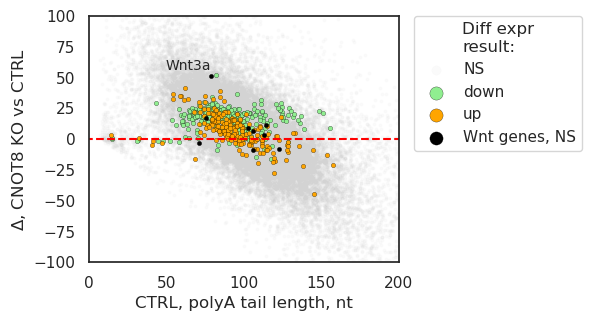

In [275]:
data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')

x_feature,y_feature,hue_feature = 'CTRL_pt','delta_pt','DGE_label'
hue_order = ['NS','down','up']
palette = ['lightgrey','lightgreen','orange']

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

k=0
for val in hue_order:
    ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,s=(5 if val=='NS' else 10),label=val,color=palette[k],alpha=(0.1 if val=='NS' else 1),edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

genes_of_interest = 'Wnt1, Wnt2, Wnt2B, Wnt3, Wnt3A, Wnt4, Wnt5A, Wnt5B, Wnt6, Wnt7A, Wnt7B, Wnt8A, Wnt8B, Wnt9A, Wnt9B, Wnt10A, Wnt10B, Wnt11, Wnt16'
genes_of_interest = genes_of_interest.split(', ')

data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')
data = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_of_interest))].reset_index()

x_feature,y_feature,hue_feature = 'CTRL_pt','delta_pt','DGE_label'
hue_order = ['NS','down','up']
palette = ['black','green','orangered']

k=0
for val in hue_order:
    ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,s=(10 if val=='NS' else 10),label='Wnt genes, '+val,color=palette[k],alpha=(1 if val=='NS' else 1),edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)
ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='Diff expr\nresult:',markerscale=3)
ax.set(ylim=(-100,100),xlim=(0,200),xlabel='CTRL, polyA tail length, nt',ylabel='$\Delta$, CNOT8 KO vs CTRL')

texts = []
for index,row in data.loc[abs(data['delta_pt'])>25].iterrows():
    texts.append(ax.annotate(row['dirty_gene_name'],(row[x_feature],row[y_feature]),ha='right',va='bottom',size=10))
%time adjust_text(texts,arrowprops=dict(arrowstyle='-', color='black'),ax=ax,min_arrow_len=15)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis/', shell=True)
fig.savefig(subdirs['figures_dir']+'differential_analysis/13.PolyA_tail_length_vs_expr.scatter.png',bbox_inches='tight',dpi=600)

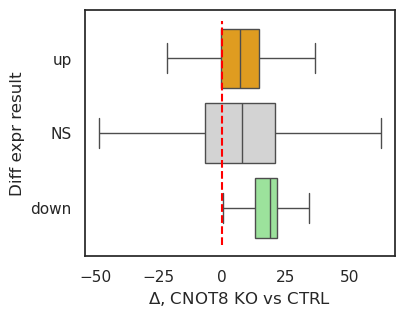

In [282]:
data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')

x_feature,y_feature,hue_feature = 'CTRL_pt','delta_pt','DGE_label'
hue_order = ['up','NS','down']
palette = ['orange','lightgrey','lightgreen']

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

ax = sns.boxplot(data = data,x=y_feature,y=hue_feature,order=hue_order,palette=palette,showfliers=False)
ax.vlines(x=0,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='red',lw=1.5)
ax.set(xlabel='$\Delta$, CNOT8 KO vs CTRL',ylabel='Diff expr result')

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis/', shell=True)
fig.savefig(subdirs['figures_dir']+'differential_analysis/14.PolyA_tail_length_vs_expr.boxplot.png',bbox_inches='tight',dpi=600)

In [316]:
data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')
# data = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_of_interest))].reset_index()
a = list(data.loc[data['DGE_label']=='down']['delta_pt'])
b = list(data.loc[data['DGE_label']=='NS']['delta_pt'])
stats.mannwhitneyu(a,b,alternative='greater')

MannwhitneyuResult(statistic=10300198.0, pvalue=1.0790053346884652e-25)

In [318]:
data.to_csv(subdirs['tables_dir']+'figure14.data.tsv',sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

## differential polyA tail lengths - advanced

In [12]:
WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
final_read_assignment_dir = general_output_dir+'final_read_assignment/'

reads_all_df = pd.read_csv(final_read_assignment_dir+'reads_all_df.tsv',delimiter="\t",index_col=None,header=0)
isoforms_all_df = pd.read_csv(final_read_assignment_dir+'isoforms_all_df.tsv',delimiter="\t",index_col=None,header=0)
transcripts_all_df = pd.read_csv(final_read_assignment_dir+'transcripts_all_df.tsv',delimiter="\t",index_col=None,header=0)
transcripts_all_df = transcripts_all_df.rename(columns={'transcript_id':'annotated_transcript_id'})
sample_metadata_df = pd.read_csv(final_read_assignment_dir+'sample_metadata_df.tsv',delimiter="\t",index_col=None,header=0)

In [13]:
gtf = pd.read_csv(file_paths['mouse_annotation_file'],delimiter="\t",index_col=None,header=None,skiprows=5)

# extract gene elements
genes = gtf.loc[gtf[2]=='gene'].reset_index(drop=True)
genes['gene_name'] = genes[8].str.split('gene_name "',expand=True)[1].str.split('";',expand=True)[0]

In [14]:
transcripts = gtf.loc[gtf[2]=='transcript'].reset_index(drop=True)
transcripts['gene_name'] = transcripts[8].str.split('gene_name "',expand=True)[1].str.split('";',expand=True)[0]
transcripts['transcript_id'] = transcripts[8].str.split('transcript_id "',expand=True)[1].str.split('";',expand=True)[0]

In [15]:
isoforms_all_df = pd.merge(isoforms_all_df,transcripts[['transcript_id','gene_name']].rename(columns={'transcript_id':'annotated_transcript_id','gene_name':'annotated_gene_name'}),how='left',on='annotated_transcript_id')

In [16]:
isoforms_all_df.loc[~isoforms_all_df['annotated_transcript_id'].isna()].head()

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id,annotated_gene_name
9,chr1,+,"10066426,10065421,10065323,10064413,10064333,1...",279,10039773,10067976,11_+,12,2162,ENSMUST00000118263.7,Cspp1
22,chr1,+,"10135934,10134230,10134092,10133273,10133164,1...",297,10038217,10136768,24_+,58,4355,ENSMUST00000071087.11,Cspp1
41,chr1,+,"105456785,105456783",3831,105455971,105458829,43_+,2,2858,ENSMUST00000086725.5,Capza1-ps1
51,chr1,+,"105753503,105751043,105750973,105750410,105750...",3851,105663883,105754081,53_+,56,4334,ENSMUST00000039173.12,Relch
58,chr1,+,"105753503,105751043,105750973,105750410,105750...",3853,105663913,105755191,61_+,56,5414,ENSMUST00000086721.9,Relch


In [17]:
isoforms_all_df.loc[isoforms_all_df['annotated_gene_name']=='Ptbp1']

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id,annotated_gene_name
203776,chr10,+,"79863145,79863055,79862978,79862869,79862653,7...",2952,79854629,79864771,5386_+,24,3169,ENSMUST00000165704.7,Ptbp1
203801,chr10,+,"79863145,79863055,79862978,79862869,79862653,7...",2951,79854427,79864435,5413_+,26,3113,ENSMUST00000172282.7,Ptbp1


In [18]:
# For CNOT8 gene, NONE of the observed transcripts are compatible with any of the annotated ones.
# So, we'll additionally do a dirty assignment of isoforms to gene loci
isoforms_all_df['t']=1
isoforms_all_df_bed = isoforms_all_df[['chr','isoform_start','isoform_end','isoform_id','t','strand']]
isoforms_all_df_bed['isoform_start'] = isoforms_all_df_bed['isoform_start']-1
isoforms_all_df_bed.to_csv(subdirs['temp_dir']+'isoforms_all_df.bed',sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

genes['t']=1
genes_bed = genes[[0,3,4,'gene_name','t',6]]
genes_bed.to_csv(subdirs['temp_dir']+'genes.bed',sep=str('\t'),header=False,index=None,quoting=csv.QUOTE_NONE)

temp_dir_path = subdirs['temp_dir']

command = 'bedtools sort -i '+temp_dir_path+'isoforms_all_df.bed'+' > '+temp_dir_path+'isoforms_all_df.sorted.bed'
out = subprocess.check_output(command, shell=True)

command = 'bedtools sort -i '+temp_dir_path+'genes.bed'+' > '+temp_dir_path+'genes.sorted.bed'
out = subprocess.check_output(command, shell=True)

command = 'bedtools intersect -f 0.75 -s -sorted -wa -wb -a '+temp_dir_path+'isoforms_all_df.sorted.bed'+' -b '+temp_dir_path+'genes.sorted.bed > '+temp_dir_path+'isoform_gene_intersected.bed'
out = subprocess.check_output(command, shell=True)

isoform_gene_intersected = pd.read_csv(temp_dir_path+'isoform_gene_intersected.bed',delimiter="\t",index_col=None,header=None)
isoform_gene_intersected = isoform_gene_intersected[[0,3,9]]

dirty_gene_assignment = pd.concat([isoform_gene_intersected[[0,3]],isoform_gene_intersected.groupby([0,3])[9].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True)
dirty_gene_assignment.columns = ['chr','isoform_id','dirty_gene_name']

In [19]:
len(dirty_gene_assignment.loc[dirty_gene_assignment['dirty_gene_name'].str.contains(',')]),len(dirty_gene_assignment)

(10287, 312165)

In [20]:
if 'dirty_gene_name' in list(isoforms_all_df.columns):
    isoforms_all_df = isoforms_all_df.drop(['dirty_gene_name'],axis=1)

isoforms_all_df = pd.merge(isoforms_all_df,dirty_gene_assignment,how='left',on=['chr','isoform_id'])
isoforms_all_df['dirty_gene_name'] = isoforms_all_df['dirty_gene_name'].fillna('')

In [21]:
len(isoforms_all_df.loc[isoforms_all_df['dirty_gene_name']==''])/len(isoforms_all_df) # f=0.75

0.17881569947913925

In [22]:
isoforms_all_df.loc[isoforms_all_df['dirty_gene_name'].str.contains('Cnot8')]

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id,annotated_gene_name,t,dirty_gene_name
224181,chr11,+,"58117207,58115375,58115265,58114094,58113950,5...",2507,58109555,58118592,6711_+,10,2210,NaN,NaN,1,Cnot8
224182,chr11,+,"58117207,58115375,58115265,58114094,58113950,5...",2505,58104131,58117847,6712_+,12,1535,NaN,NaN,1,Cnot8
224185,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2504,58104164,58117787,6715_+,12,1217,NaN,NaN,1,Cnot8
224186,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2505,58103992,58117847,6716_+,12,1449,NaN,NaN,1,Cnot8
224187,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2507,58104001,58118598,6717_+,12,2191,NaN,NaN,1,Cnot8
224188,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2505,58104259,58117844,6718_+,12,1319,NaN,NaN,1,Cnot8
224189,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2505,58104229,58117847,6720_+,12,1798,NaN,NaN,1,Cnot8
224190,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2507,58111259,58118595,6721_+,10,1678,NaN,NaN,1,Cnot8
224191,chr11,+,"58117439,58115375,58115265,58114094,58113950,5...",2507,58111420,58118591,6722_+,8,1609,NaN,NaN,1,Cnot8
224192,chr11,+,"58117439,58115375,58115277,58114094,58113950,5...",2507,58104162,58118594,6723_+,12,1983,NaN,NaN,1,Cnot8


In [23]:
Counter(isoforms_all_df.loc[isoforms_all_df['chr']=='chrM']['dirty_gene_name'])

Counter({'mt-Co1': 578,
         '': 313,
         'mt-Cytb': 191,
         'mt-Nd1': 151,
         'mt-Rnr2': 137,
         'mt-Nd4': 131,
         'mt-Co2': 72,
         'mt-Atp6': 63,
         'mt-Co3': 56,
         'mt-Nd2': 40,
         'mt-Nd5': 23,
         'mt-Rnr1': 12,
         'mt-Nd3': 6,
         'mt-Nd6': 4,
         'mt-Nd4l': 2,
         'mt-Atp8': 1})

In [24]:
reads_all_df['sample_index'] = reads_all_df['read_id'].str.split(';',expand=True)[0].astype('int')
reads_all_df['isoform_full_id'] = (reads_all_df['chr']+'_'+reads_all_df['isoform_id']).astype('category')
isoforms_all_df['isoform_full_id'] = (isoforms_all_df['chr']+'_'+isoforms_all_df['isoform_id']).astype('category')

metadata_df = sample_metadata_df[['sample','sample_index']].drop_duplicates().reset_index(drop=True)

metadata_df['condition'] = metadata_df.apply(lambda x: '_'.join(x['sample'].split('_')[:-1]),1)
metadata_df['replicate'] = metadata_df.apply(lambda x: 'R'+str(x['sample'].split('_')[-1]),1)
metadata_df['color'] = ['orangered','orangered','grey','grey']
dict_relabel = {'Cnot8_KO_1':'Cnot8-KO R1','Cnot8_KO_2':'Cnot8-KO R2','CTRL_1':'CTRL R1','CTRL_2':'CTRL R2'}
metadata_df['sample_label'] = metadata_df['sample'].map(dict_relabel).astype('category')

if 'sample_label' in list(reads_all_df.columns):
    reads_all_df = reads_all_df.drop(['sample_label'],axis=1)
if 'sample' in list(reads_all_df.columns):
    reads_all_df = reads_all_df.drop(['sample'],axis=1)
reads_all_df = pd.merge(reads_all_df,metadata_df[['sample_index','sample','sample_label']],how='left',on='sample_index')

In [25]:
# prepare read-level out table with dirty gene names assigned

out_table = reads_all_df[['sample_label','pt','qs','isoform_full_id']].copy()
out_table = pd.merge(out_table,isoforms_all_df[['isoform_full_id','dirty_gene_name','annotated_transcript_id','annotated_gene_name']],how='left',on='isoform_full_id')
out_table = out_table[['dirty_gene_name','sample_label','pt','qs','isoform_full_id','annotated_transcript_id','annotated_gene_name']].rename(columns={'dirty_gene_name':'Gene_name'})

In [30]:
len(out_table)

8126056

In [29]:
out_table['t'] = 1
out_table.groupby('sample_label').agg({'t':sum}).reset_index().sort_values('t')

,sample_label,t
0,CTRL R1,1690214
1,CTRL R2,1855642
2,Cnot8-KO R1,2090966
3,Cnot8-KO R2,2489234


In [32]:
len(out_table.loc[out_table['Gene_name']!='']),len(out_table.loc[out_table['Gene_name']!=''])/len(out_table)*100

(5535681, 68.12260461901813)

In [37]:
len(out_table.loc[out_table['Gene_name'].str.contains(',')]),len(out_table.loc[out_table['Gene_name'].str.contains(',')])/len(out_table)*100

(233401, 2.8722543876143605)

In [ ]:
out_table = out_table.loc[out_table['Gene_name']!=''].sort_values(['Gene_name','sample_label']).reset_index(drop=True)
out_table.to_csv(subdirs['tables_dir']+'ONT_reads_in_genes_in_isoforms.tsv',sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

In [4]:
out_table = pd.read_csv(subdirs['tables_dir']+'ONT_reads_in_genes_in_isoforms.tsv',delimiter="\t",index_col=None,header=0)

,sample_label,t
0,CTRL R1,1143451
1,CTRL R2,1230306
2,Cnot8-KO R1,1446404
3,Cnot8-KO R2,1715520


In [11]:
out_table.loc[out_table['']]

,Gene_name,sample_label,pt,qs,isoform_full_id,annotated_transcript_id,annotated_gene_name,t
0,0610005C13Rik,CTRL R1,119,17.193386,chr7_15040_-,ENSMUST00000210383.1,0610005C13Rik,1
1,0610005C13Rik,Cnot8-KO R2,76,16.018686,chr7_15040_-,ENSMUST00000210383.1,0610005C13Rik,1
2,0610009B22Rik,CTRL R1,278,13.494831,chr11_7607_-,NaN,NaN,1
3,0610009B22Rik,CTRL R1,31,22.611496,chr11_7604_-,NaN,NaN,1
4,0610009B22Rik,CTRL R1,63,22.043667,chr11_7610_-,ENSMUST00000109098.1,0610009B22Rik,1


In [6]:
len(out_table)

5535681

In [41]:
out_table['sample_label'].unique()

['CTRL R1', 'Cnot8-KO R2', 'CTRL R2', 'Cnot8-KO R1']
Categories (4, object): ['CTRL R1', 'CTRL R2', 'Cnot8-KO R1', 'Cnot8-KO R2']

In [17]:
# what are typical distributions of pt within isoforms?

In [17]:
reads_all_df['t']=1
reads_all_df['pt']=reads_all_df['pt'].astype('float')
gr = reads_all_df.groupby(['isoform_full_id','sample']).agg({'t':np.sum,'pt':{np.mean,np.median,np.std,np.min,np.max}}).reset_index()
gr.columns = [('-'.join(elem) if min([len(sub_elem) for sub_elem in elem])>0 else elem[0]) for elem in gr.columns]

In [18]:
gr['sigma_sq'] = gr['pt-std']**2
t_thr = 1
len(gr.loc[(gr['sigma_sq']>=gr['pt-mean'])&(gr['t-sum']>t_thr)])/len(gr.loc[(gr['t-sum']>t_thr)])

0.9448772088967956

In [19]:
gr_gr = gr.groupby('isoform_full_id').agg({'t-sum':np.min}).reset_index()
len(gr_gr.loc[gr_gr['t-sum']>0])/len(gr_gr),len(gr_gr.loc[gr_gr['t-sum']>0]),len(gr_gr)

(0.1240464039564371, 47155, 380140)

In [20]:
len(gr_gr.loc[gr_gr['t-sum']>1])/len(gr_gr),len(gr_gr.loc[gr_gr['t-sum']>1]),len(gr_gr)

(0.08725206502867365, 33168, 380140)

In [21]:
reads_all_df['replicate'] = reads_all_df.apply(lambda x:x['sample_label'].split(' ')[-1]=='R2',1).astype('category')
reads_all_df['condition'] = reads_all_df.apply(lambda x:x['sample_label'].split(' ')[0]=='Cnot8-KO',1).astype('category')
reads_all_df['log2_pt'] = np.log2(reads_all_df['pt'])

In [22]:
sel_isoforms = list(gr_gr.loc[gr_gr['t-sum']>1]['isoform_full_id'])
reads_all_df_sel = reads_all_df.loc[reads_all_df['isoform_full_id'].isin(sel_isoforms)].reset_index(drop=True)
reads_all_df_sel['isoform_full_id'] = reads_all_df_sel['isoform_full_id'].astype('str').astype('category')
reads_all_df_sel = reads_all_df_sel[['isoform_full_id','log2_pt','qs','replicate','condition','sample_label']]

In [30]:
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.regression.linear_model import OLS

def get_boots(L,data_cur,isoform_full_id,start_time,iterator):
    boot_N = 500
    data_cur['t']=1
    sample_size = int(data_cur.groupby('sample_label').agg({'t':np.sum}).reset_index()['t'].min()*0.8) # 0.8 is to make sure that there is random subsampling for all groups 
    groups = data_cur.groupby('sample_label')
    
    r = []
    for k in range(0,boot_N):
        # subsample so that all groups have the same sample size
        a = []
        for label, group in groups:
                a.append(group.sample(sample_size))
        data = pd.concat(a).reset_index(drop=True)
        data['c'] = 1 # constant
        X = np.concatenate((data[['c']].values,data[['qs']].values,data[['replicate']].values,data[['condition']].values,),axis=1)
        y = data[['log2_pt']].values
        
        mod = OLS(endog = y,exog = X)
        reg = mod.fit()
        
        # mod = QuantReg(endog = y,exog = X)
        # reg = mod.fit(q=0.5,max_iter=100)
        r.append([k]+list(reg.params))    
    r_df = pd.DataFrame(r,columns=['boot_id','const','qs','replicate_R2','condition_KO'])
    r_df['isoform_full_id'] = isoform_full_id
    L.append(r_df)
    if iterator%500==0:
        print(str(iterator)+' done, '+str(time.time()-start_time))

start_time = time.time()
with Manager() as manager:
    L = manager.list()
    processes = []
    i=0
    for isoform_full_id,data_cur in reads_all_df_sel.groupby('isoform_full_id'):
        p = Process(target=get_boots, args=(L,data_cur,isoform_full_id,start_time,i))  # Passing the list
        p.start()
        processes.append(p)
        i=i+1
    for p in processes:
        p.join()
    L = list(L)
print(time.time()-start_time)
L_df = pd.concat(L).reset_index(drop=True)
L_df['isoform_full_id'] = L_df['isoform_full_id'].astype('category')
L_df.to_csv(subdirs['temp_dir']+'log2_pt.OLS.tsv',sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

0 done, 1.8663482666015625
500 done, 27.841856956481934
1000 done, 53.90918588638306
1500 done, 80.14161944389343
2000 done, 106.07778429985046
2500 done, 132.65888571739197
3000 done, 158.4656527042389
3500 done, 184.81379079818726
4000 done, 211.67280554771423
4500 done, 237.44169807434082
5000 done, 263.76202368736267
5500 done, 289.8103997707367
6000 done, 315.7261071205139
6500 done, 341.9695465564728
7000 done, 368.2618250846863
7500 done, 394.3248620033264
8000 done, 420.42805767059326
8500 done, 446.7099597454071
9000 done, 473.0538957118988
9500 done, 499.36595249176025
10000 done, 525.4217281341553
10500 done, 552.3258318901062
11000 done, 578.21599817276
11500 done, 604.4533302783966
12000 done, 630.8542015552521
12500 done, 657.0519096851349
13000 done, 683.5020158290863
13500 done, 709.5982847213745
14000 done, 735.8654499053955
14500 done, 762.2020754814148
15000 done, 788.4980218410492
15500 done, 814.9351603984833
16000 done, 841.4160735607147
16500 done, 867.6857655048

In [24]:
len(L_df['isoform_full_id'].unique())

33168

In [62]:
L_df = pd.read_csv(subdirs['temp_dir']+'log2_pt.OLS.tsv',delimiter="\t",index_col=None,header=0)

In [67]:
# Shapiro-Wilk test for normality of bootstraps
shapiro_list = []
for group,group_df in L_df.groupby('isoform_full_id'):
    for feature in ['qs','replicate_R2','condition_KO']:
        shapiro_list.append([group,feature,stats.shapiro(group_df[feature])[1]])
shapiro_df = pd.DataFrame(shapiro_list,columns = ['isoform_full_id','feature','pval'])

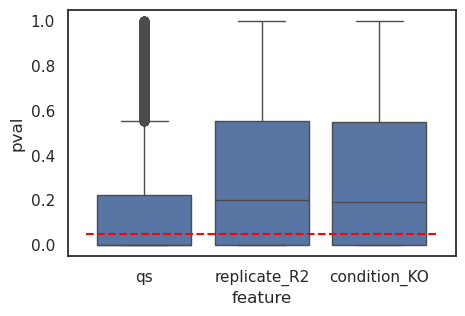

In [72]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(5,3.2))

features = ['qs','replicate_R2','condition_KO']

ax = sns.boxplot(data = shapiro_df, y = 'pval',x='feature',order = features)
ax.hlines(y=0.05,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)

In [83]:
shapiro_df_pivot = pd.pivot_table(data = shapiro_df,index='isoform_full_id',values='pval',columns='feature').reset_index().reset_index(drop=True)
rename_dict = {}
for feature in ['qs','replicate_R2','condition_KO']:
    rename_dict[feature] = feature+'_ShapiroPval'

shapiro_df_pivot = shapiro_df_pivot.rename(columns=rename_dict)

In [86]:
regr_results = L_df.groupby(['isoform_full_id']).agg({'qs':{np.mean,np.std},'replicate_R2':{np.mean,np.std},'condition_KO':{np.mean,np.std}}).reset_index()
regr_results.columns = [('-'.join(elem) if min([len(sub_elem) for sub_elem in elem])>0 else elem[0]) for elem in regr_results.columns]
regr_results = pd.merge(regr_results,shapiro_df_pivot,how='outer',on='isoform_full_id')

In [88]:
regr_results['condition_KO-z_score'] = regr_results['condition_KO-mean']/regr_results['condition_KO-std']

In [97]:
stats.spearmanr(regr_results['condition_KO-z_score'],regr_results['condition_KO_ShapiroPval'])

SignificanceResult(statistic=0.37641305076619724, pvalue=0.0)

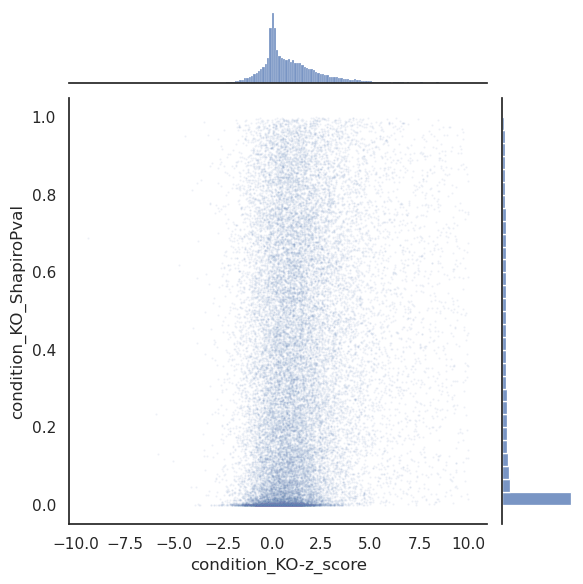

In [98]:
sns.set(font_scale=1)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(5,3.2))

g = sns.jointplot(data = regr_results.loc[(regr_results['condition_KO-z_score']<10)&(regr_results['condition_KO-z_score']>(-10))],x = 'condition_KO-z_score',y='condition_KO_ShapiroPval',s=2,alpha=0.1)

In [100]:
# there are many isoforms for which bootstrap estimates do not appear to have normal distribution
# however, signficant differences tend to have normal distribution

In [152]:
# so, let's estimate p-value in Z-test
regr_results['0'] = 0
for feature in ['qs','replicate_R2','condition_KO']:
    regr_results[feature+'-z_score'] = regr_results[feature+'-mean']/regr_results[feature+'-std']
    regr_results[feature+'-minus_log_padj'] = (-1)*(stats.norm.logcdf(abs(regr_results[feature+'-z_score'])*(-1), loc=0, scale=1)+np.log(2)+np.log(len(regr_results))) # corresponds to bonferroni-adjusted two-sided pval
    regr_results[feature+'-minus_log_padj'] = regr_results[['0',feature+'-minus_log_padj']].max(1) # pval can't be higher than 1
    regr_results[feature+'-minus_log_pval'] = (-1)*(stats.norm.logcdf(abs(regr_results[feature+'-z_score'])*(-1), loc=0, scale=1)+np.log(2))
    regr_results[feature+'-minus_log_pval'] = regr_results[['0',feature+'-minus_log_pval']].max(1) # pval can't be higher than 1
    regr_results[feature+'-padj'] = np.exp((-1)*regr_results[feature+'-minus_log_padj'])
    regr_results[feature+'-pval'] = np.exp((-1)*regr_results[feature+'-minus_log_pval'])

In [153]:
regr_results.head()

,isoform_full_id,qs-std,qs-mean,replicate_R2-std,replicate_R2-mean,condition_KO-std,condition_KO-mean,condition_KO_ShapiroPval,qs_ShapiroPval,replicate_R2_ShapiroPval,...,replicate_R2-minus_log10_padj,condition_KO-padj,condition_KO-minus_log10_padj,qs-minus_log_padj,qs-minus_log_pval,replicate_R2-minus_log_padj,replicate_R2-minus_log_pval,condition_KO-minus_log_padj,condition_KO-minus_log_pval,0
0,chr10_10023_+,0.080011,-0.018950,0.277675,-0.493768,0.263083,-0.095011,0.862145,5.353128e-02,0.778013,...,-0.0,1.0,-0.0,0.0,0.207293,0.0,2.585378,0.0,0.331298,0
1,chr10_1002_-,0.045537,0.028946,0.189343,-0.036634,0.171391,0.175237,0.033118,3.887499e-02,0.115271,...,-0.0,1.0,-0.0,0.0,0.644376,0.0,0.166545,0.0,1.182299,0
2,chr10_10049_+,0.034684,-0.020923,0.230939,0.260097,0.240754,-0.030462,0.000010,2.654416e-15,0.000081,...,-0.0,1.0,-0.0,0.0,0.604503,0.0,1.346858,0.0,0.106121,0
3,chr10_1005_+,0.009688,-0.018102,0.065925,-0.018824,0.066069,0.248483,0.988661,4.599221e-02,0.296910,...,-0.0,1.0,-0.0,0.0,2.785801,0.0,0.254599,0.0,8.684096,0
4,chr10_1006_+,0.009463,0.019928,0.073616,0.099956,0.067221,0.220735,0.476017,6.973553e-01,0.232784,...,-0.0,1.0,-0.0,0.0,3.346498,0.0,1.745687,0.0,6.883615,0


In [162]:
CTRL_mean_pt = pd.merge(gr.loc[gr['sample']=='CTRL_1'][['isoform_full_id','pt-mean','t-sum']].rename(columns={'pt-mean':'pt-mean;CTRL_1','t-sum':'t-sum;CTRL_1'}),
                        gr.loc[gr['sample']=='CTRL_2'][['isoform_full_id','pt-mean','t-sum']].rename(columns={'pt-mean':'pt-mean;CTRL_2','t-sum':'t-sum;CTRL_2'}),
                         how='outer',on='isoform_full_id')
regr_results = pd.merge(regr_results,CTRL_mean_pt,how='left',on='isoform_full_id')
regr_results = pd.merge(isoforms_all_df,regr_results,how='right',on='isoform_full_id')
regr_results['CTRL-mean pt'] = regr_results[['pt-mean;CTRL_1','pt-mean;CTRL_2']].mean(1)

# intersect with targets from CRISPR experiments

sign_thr = 0.05

new_crispr_screen_res = pd.read_csv(subdirs['other_experiments']+'gast146_Cnot8_vs_Ctrl_cluster_7_9.csv',delimiter=",",index_col=None,header=0)
old_crispr_screen_res = pd.read_csv(subdirs['other_experiments']+'Cnot8_vs_ctrl_NMPs_lfc0.1.csv',delimiter=",",index_col=None,header=0)

old_crispr_screen_res['fdr_old'] = multipletests(old_crispr_screen_res['p_val'],method = 'fdr_bh')[1]
old_crispr_screen_res = old_crispr_screen_res.rename(columns={'Unnamed: 0':'dirty_gene_name','avg_log2FC':'lfc_old','p_val':'pval_old'})
old_crispr_screen_res['DE_old'] = (((old_crispr_screen_res['lfc_old']>0).astype('int')*2-1)*(old_crispr_screen_res['fdr_old']<sign_thr).astype('int')).map({-1:'down',0:'NS',1:'up'})

new_crispr_screen_res['fdr_new'] = multipletests(new_crispr_screen_res['pval'],method = 'fdr_bh')[1]
new_crispr_screen_res = new_crispr_screen_res.rename(columns={'feature':'dirty_gene_name','avg_log2FC':'lfc_new','pval':'pval_new'})
new_crispr_screen_res['DE_new'] = (((new_crispr_screen_res['lfc_new']>0).astype('int')*2-1)*(new_crispr_screen_res['fdr_new']<sign_thr).astype('int')).map({-1:'down',0:'NS',1:'up'})

regr_results = pd.merge(regr_results,old_crispr_screen_res[['dirty_gene_name','lfc_old','pval_old','fdr_old','DE_old']],how='left',on='dirty_gene_name')
regr_results = pd.merge(regr_results,new_crispr_screen_res[['dirty_gene_name','lfc_new','pval_new','fdr_new','DE_new']],how='left',on='dirty_gene_name')

EXP_mean_read_number = pd.merge(gr.loc[gr['sample']=='Cnot8_KO_1'][['isoform_full_id','t-sum']].rename(columns={'t-sum':'t-sum;Cnot8_KO_1'}),
                        gr.loc[gr['sample']=='Cnot8_KO_2'][['isoform_full_id','t-sum']].rename(columns={'t-sum':'t-sum;Cnot8_KO_2'}),
                         how='outer',on='isoform_full_id')
regr_results = pd.merge(regr_results,EXP_mean_read_number,how='left',on='isoform_full_id')

# add normalized (TPM) expression

raw_expr_cols = ['t-sum;CTRL_1','t-sum;CTRL_2','t-sum;Cnot8_KO_1','t-sum;Cnot8_KO_2']

tmp = regr_results[raw_expr_cols].div(regr_results['total_transcript_length'],axis=0)
tmp[raw_expr_cols] = tmp[raw_expr_cols]/tmp[raw_expr_cols].sum()*10**6 # got TPM
tmp['TPM_CTRL'] = tmp[['t-sum;CTRL_1','t-sum;CTRL_2']].mean(1)
tmp['TPM_Cnot8_KO'] = tmp[['t-sum;Cnot8_KO_1','t-sum;Cnot8_KO_2']].mean(1)

regr_results = pd.concat([regr_results,tmp[['TPM_CTRL','TPM_Cnot8_KO']]],axis=1)

In [213]:
tmp = regr_results[raw_expr_cols]
tmp[raw_expr_cols] = tmp[raw_expr_cols]/tmp[raw_expr_cols].sum()*10**6 # got CPM
tmp['CPM_CTRL'] = tmp[['t-sum;CTRL_1','t-sum;CTRL_2']].mean(1)
tmp['CPM_Cnot8_KO'] = tmp[['t-sum;Cnot8_KO_1','t-sum;Cnot8_KO_2']].mean(1)

regr_results = pd.concat([regr_results,tmp[['CPM_CTRL','CPM_Cnot8_KO']]],axis=1)

In [189]:
regr_results['Diff_pt'] = ((regr_results['condition_KO-padj']<0.05).astype('int')*((regr_results['condition_KO-mean']>0).astype('int')*2-1)).map({-1:'down',1:'up',0:'NS'})

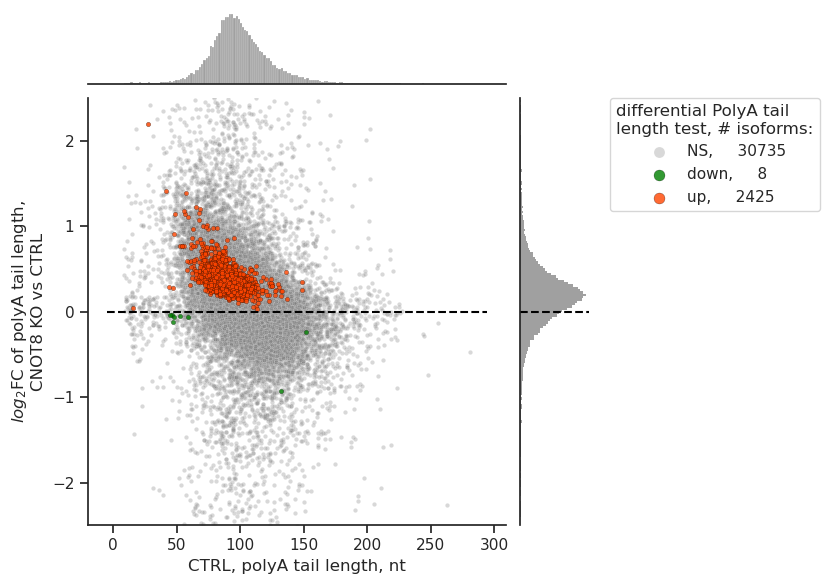

In [190]:
sns.set(font_scale=1)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

data = regr_results.copy()

x_feature,y_feature,hue_feature = 'CTRL-mean pt','condition_KO-mean','Diff_pt'
hue_order = ['NS','down','up']
palette = ['grey','green','orangered']

k=0
for val in hue_order:
    data_sub = data.loc[data[hue_feature]==val].reset_index(drop=True)
    if k==0:
        g = sns.jointplot(data = data_sub,
                          x=x_feature,y=y_feature,s=(10 if val=='NS' else 10),
                          label='NS,     '+str(len(data_sub)),color=palette[k],alpha=(0.3 if val=='NS' else 1))
    else:
        ax = g.ax_joint
        ax = sns.scatterplot(data = data_sub,x=x_feature,y=y_feature,
                             s=(10 if val=='NS' else 10),
                             label=val+',     '+str(len(data_sub)),color=palette[k],alpha=(0.3 if val=='NS' else 0.8),
                             edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

ax.set(ylim=(-2.5,2.5))
ax.tick_params(bottom=True,left=True)
ax.set(xlabel = 'CTRL, polyA tail length, nt',ylabel='$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL')
ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='black',lw=1.5)
ax.legend(bbox_to_anchor=(1.25, 1),loc=2,borderaxespad=0.0,title='differential PolyA tail\nlength test, # isoforms:',markerscale=2.5,ncol=1)

ax_x = g.ax_marg_y
ax_x.hlines(y=0,xmin=ax_x.get_xlim()[0],xmax=ax_x.get_xlim()[1],linestyle='--',color='black',lw=1.5)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
g.savefig(subdirs['figures_dir']+'differential_analysis_retake/1.lfc_pt.no_highlighted_genes.png',bbox_inches='tight',dpi=600)

In [214]:
# prepare out - table

out_table = regr_results.sort_values('condition_KO-minus_log_padj',ascending=False).copy()
out_table = out_table[['isoform_full_id','annotated_transcript_id','annotated_gene_name','dirty_gene_name',
                       'CPM_CTRL','CPM_Cnot8_KO',
                       'CTRL-mean pt',
                       'condition_KO-mean','condition_KO-std','condition_KO-z_score','condition_KO-minus_log_padj','condition_KO-minus_log_pval','condition_KO-padj','condition_KO-pval',
                        'lfc_old', 'pval_old', 'fdr_old', 'DE_old',
                       'lfc_new', 'pval_new', 'fdr_new', 'DE_new',
                       'chr', 'strand','isoform_start', 'isoform_end', 'contig'
                      ]]
rename_dict = {}
for col in list(out_table.columns):
    if 'condition_KO' in col:
        rename_dict[col] = col.replace('condition_KO','log2FC_pt')

out_table = out_table.rename(columns=rename_dict)

In [215]:
out_table.to_csv(subdirs['tables_dir']+'Differential_PolyAtail_x_scCRISPR_DE.v3.tsv',sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

In [38]:
### here, we tried bootstrap p-values

# L_df = pd.merge(L_df,regr_results[['isoform_full_id','qs-mean','replicate_R2-mean','condition_KO-mean']],how='left',on='isoform_full_id')
# L_df['t'] = 1

# groupby_dict = {}
# for feature in ['qs','replicate_R2','condition_KO']:
#     L_df[feature+'_centered'] = L_df[feature]-L_df[feature+'-mean']
#     L_df[feature+'_t'] = ((L_df[feature+'_centered']>=abs(L_df[feature+'-mean']))|(L_df[feature+'_centered']<=(-1)*abs(L_df[feature+'-mean']))).astype('int')
#     groupby_dict[feature+'_t'] = np.sum
# groupby_dict['t'] = np.sum
# tmp_results = L_df.groupby(['isoform_full_id']).agg(groupby_dict).reset_index()
# for feature in ['qs','replicate_R2','condition_KO']:
#     tmp_results[feature+'_pval'] = tmp_results[feature+'_t']/tmp_results['t']
# regr_results = pd.merge(regr_results,tmp_results[['isoform_full_id','qs_pval','replicate_R2_pval','condition_KO_pval']],how='left',on='isoform_full_id')

[Text(0.5, 0, '$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL'),
 Text(0, 0.5, '$-log~padj$')]

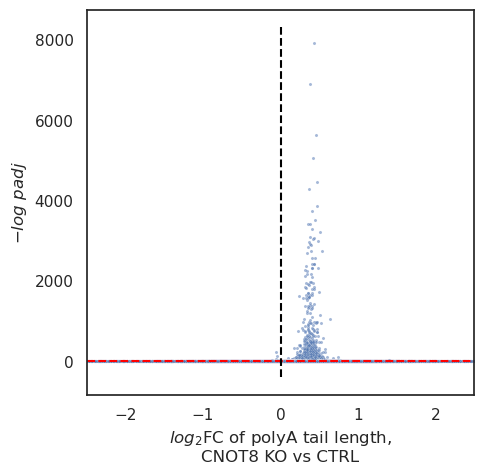

In [191]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(5,5))

ax = sns.scatterplot(data = regr_results,x='condition_KO-mean',y='condition_KO-minus_log_padj',s=5,alpha=0.5)

ax.hlines(y=(-1)*np.log10(0.05),xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)
ax.vlines(x=0,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='black',lw=1.5)

ax.set(xlim=(-2.5,2.5))
ax.set(xlabel = '$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL',ylabel = '$-log~padj$')

[Text(0.5, 0, '$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL'),
 Text(0, 0.5, '$Z-score$')]

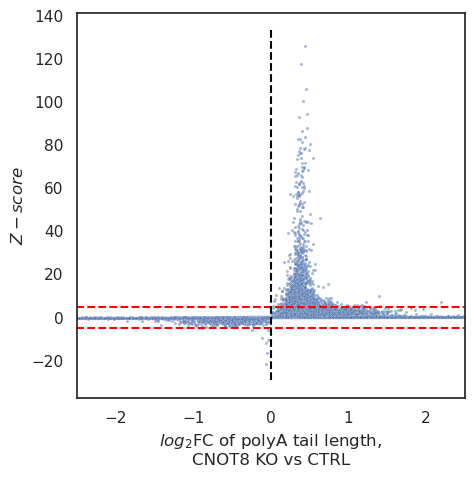

In [210]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(5,5))

ax = sns.scatterplot(data = regr_results,x='condition_KO-mean',y='condition_KO-z_score',s=5,alpha=0.5)

thr_pval = 0.05/len(regr_results)/2 # bonferroni-corrected, two-sided
thr_z_score = abs(stats.norm.ppf(thr_pval,0,1))

ax.hlines(y=thr_z_score,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)
ax.hlines(y=(-1)*thr_z_score,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)
ax.vlines(x=0,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='black',lw=1.5)

ax.set(xlim=(-2.5,2.5))
ax.set(xlabel = '$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL',ylabel = '$Z-score$')

In [196]:
regr_results['log2_TPM_CTRL'] = np.log2(regr_results['TPM_CTRL'])
regr_results['log2_TPM_Cnot8_KO'] = np.log2(regr_results['TPM_Cnot8_KO'])

In [216]:
regr_results['log2_CPM_CTRL'] = np.log2(regr_results['CPM_CTRL'])
regr_results['log2_CPM_Cnot8_KO'] = np.log2(regr_results['CPM_Cnot8_KO'])

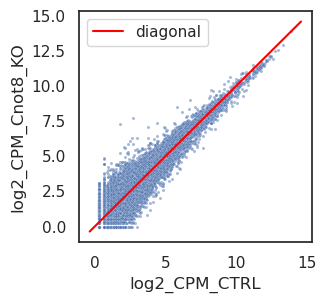

In [217]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3,3))

ax = sns.scatterplot(data = regr_results,y='log2_CPM_Cnot8_KO',x='log2_CPM_CTRL',s=5,alpha=0.5)
diag_df = pd.DataFrame([[ax.get_xlim()[0],ax.get_xlim()[0]],[ax.get_xlim()[1],ax.get_xlim()[1]]],columns = ['log2_CPM_CTRL','log2_CPM_Cnot8_KO'])

ax = sns.lineplot(data = diag_df,y='log2_CPM_Cnot8_KO',x='log2_CPM_CTRL',color='red',label='diagonal')

In [221]:
np.log2(66)

6.044394119358453

[Text(0, 0.5, '$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL')]

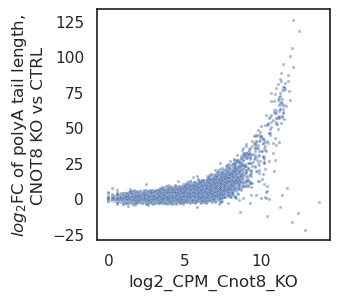

In [220]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3,3))

ax = sns.scatterplot(data = regr_results,y='condition_KO-z_score',x='log2_CPM_Cnot8_KO',s=5,alpha=0.5)
ax.set(ylabel = '$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL')

In [ ]:
### below are older results

In [51]:
len(regr_results.loc[regr_results['condition_KO_fdr']<0.05])

6226

In [26]:
thr_pval = 0.05/len(regr_results)/2 # bonferroni-corrected, two-sided
thr_z_score = abs(stats.norm.ppf(thr_pval,0,1))
for feature in ['qs','replicate_R2','condition_KO']:
    regr_results[feature+'-z_score'] = regr_results[feature+'-mean']/regr_results[feature+'-std']
    regr_results[feature+'-z_score;sign'] = (abs(regr_results[feature+'-z_score'])>thr_z_score).astype('int')*((regr_results[feature+'-mean']>0).astype('int')*2-1)
regr_results['Diff_pt'] = regr_results['condition_KO-z_score;sign'].map({-1:'down',1:'up',0:'NS'})

CTRL_mean_pt = pd.merge(gr.loc[gr['sample']=='CTRL_1'][['isoform_full_id','pt-mean','t-sum']].rename(columns={'pt-mean':'pt-mean;CTRL_1','t-sum':'t-sum;CTRL_1'}),
                        gr.loc[gr['sample']=='CTRL_2'][['isoform_full_id','pt-mean','t-sum']].rename(columns={'pt-mean':'pt-mean;CTRL_2','t-sum':'t-sum;CTRL_2'}),
                         how='outer',on='isoform_full_id')
regr_results = pd.merge(regr_results,CTRL_mean_pt,how='left',on='isoform_full_id')
regr_results = pd.merge(isoforms_all_df,regr_results,how='right',on='isoform_full_id')
regr_results['CTRL-mean pt'] = regr_results[['pt-mean;CTRL_1','pt-mean;CTRL_2']].mean(1)
regr_results['FC'] = 2**(regr_results['condition_KO-mean'])

# intersect with targets from CRISPR experiments

sign_thr = 0.05

new_crispr_screen_res = pd.read_csv(subdirs['other_experiments']+'gast146_Cnot8_vs_Ctrl_cluster_7_9.csv',delimiter=",",index_col=None,header=0)
old_crispr_screen_res = pd.read_csv(subdirs['other_experiments']+'Cnot8_vs_ctrl_NMPs_lfc0.1.csv',delimiter=",",index_col=None,header=0)

old_crispr_screen_res['fdr_old'] = multipletests(old_crispr_screen_res['p_val'],method = 'fdr_bh')[1]
old_crispr_screen_res = old_crispr_screen_res.rename(columns={'Unnamed: 0':'dirty_gene_name','avg_log2FC':'lfc_old','p_val':'pval_old'})
old_crispr_screen_res['DE_old'] = (((old_crispr_screen_res['lfc_old']>0).astype('int')*2-1)*(old_crispr_screen_res['fdr_old']<sign_thr).astype('int')).map({-1:'down',0:'NS',1:'up'})

new_crispr_screen_res['fdr_new'] = multipletests(new_crispr_screen_res['pval'],method = 'fdr_bh')[1]
new_crispr_screen_res = new_crispr_screen_res.rename(columns={'feature':'dirty_gene_name','avg_log2FC':'lfc_new','pval':'pval_new'})
new_crispr_screen_res['DE_new'] = (((new_crispr_screen_res['lfc_new']>0).astype('int')*2-1)*(new_crispr_screen_res['fdr_new']<sign_thr).astype('int')).map({-1:'down',0:'NS',1:'up'})

regr_results = pd.merge(regr_results,old_crispr_screen_res[['dirty_gene_name','lfc_old','pval_old','fdr_old','DE_old']],how='left',on='dirty_gene_name')
regr_results = pd.merge(regr_results,new_crispr_screen_res[['dirty_gene_name','lfc_new','pval_new','fdr_new','DE_new']],how='left',on='dirty_gene_name')

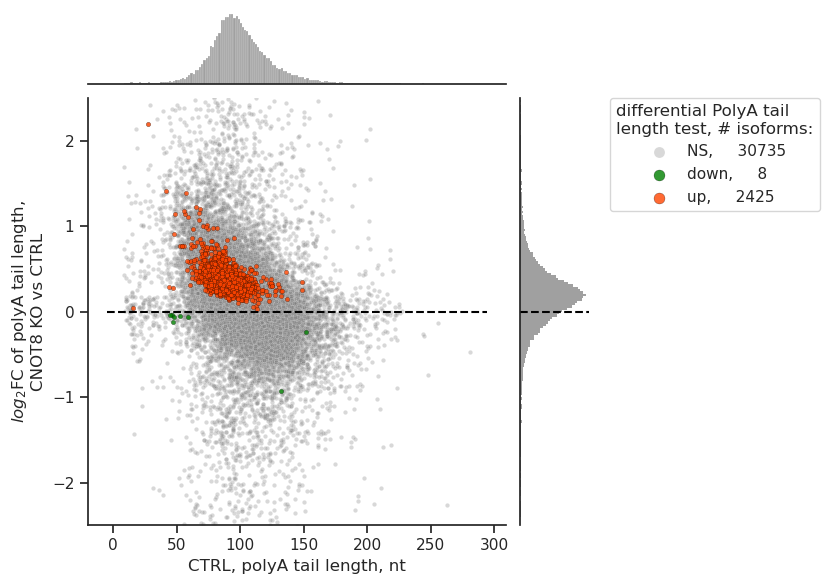

In [27]:
sns.set(font_scale=1)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

data = regr_results.copy()

x_feature,y_feature,hue_feature = 'CTRL-mean pt','condition_KO-mean','Diff_pt'
hue_order = ['NS','down','up']
palette = ['grey','green','orangered']

k=0
for val in hue_order:
    data_sub = data.loc[data[hue_feature]==val].reset_index(drop=True)
    if k==0:
        g = sns.jointplot(data = data_sub,
                          x=x_feature,y=y_feature,s=(10 if val=='NS' else 10),
                          label='NS,     '+str(len(data_sub)),color=palette[k],alpha=(0.3 if val=='NS' else 1))
    else:
        ax = g.ax_joint
        ax = sns.scatterplot(data = data_sub,x=x_feature,y=y_feature,
                             s=(10 if val=='NS' else 10),
                             label=val+',     '+str(len(data_sub)),color=palette[k],alpha=(0.3 if val=='NS' else 0.8),
                             edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

ax.set(ylim=(-2.5,2.5))
ax.tick_params(bottom=True,left=True)
ax.set(xlabel = 'CTRL, polyA tail length, nt',ylabel='$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL')
ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='black',lw=1.5)
ax.legend(bbox_to_anchor=(1.25, 1),loc=2,borderaxespad=0.0,title='differential PolyA tail\nlength test, # isoforms:',markerscale=2.5,ncol=1)

ax_x = g.ax_marg_y
ax_x.hlines(y=0,xmin=ax_x.get_xlim()[0],xmax=ax_x.get_xlim()[1],linestyle='--',color='black',lw=1.5)

out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
g.savefig(subdirs['figures_dir']+'differential_analysis_retake/1.lfc_pt.no_highlighted_genes.png',bbox_inches='tight',dpi=600)

CPU times: user 1.4 s, sys: 4.26 ms, total: 1.41 s
Wall time: 189 ms
CPU times: user 1.46 s, sys: 0 ns, total: 1.46 s
Wall time: 1.46 s


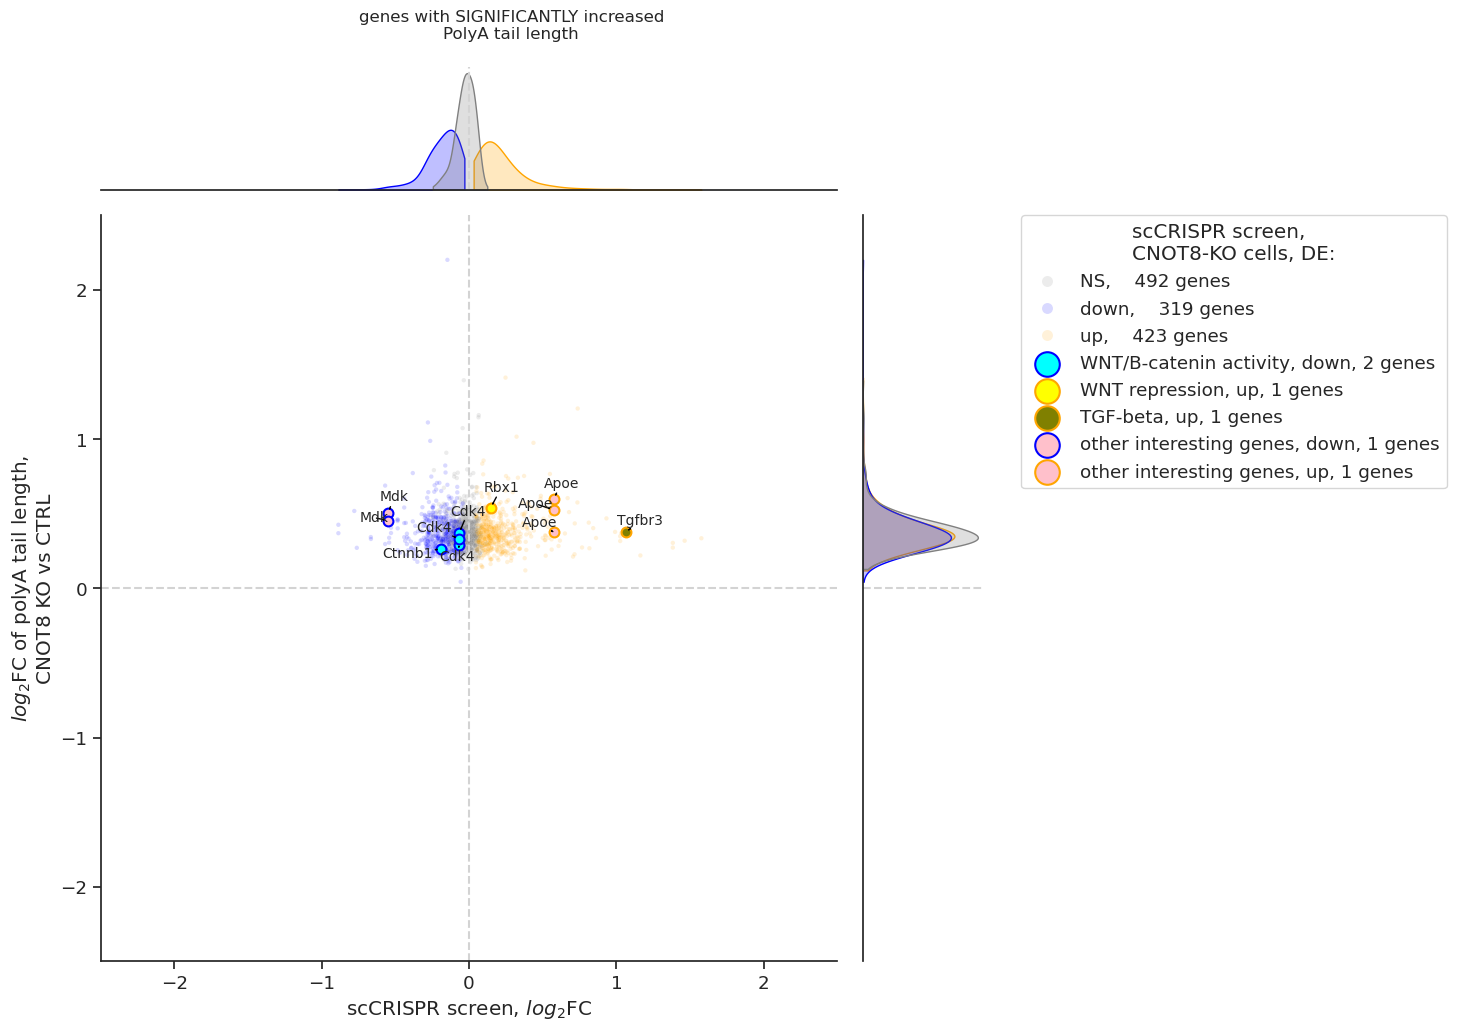

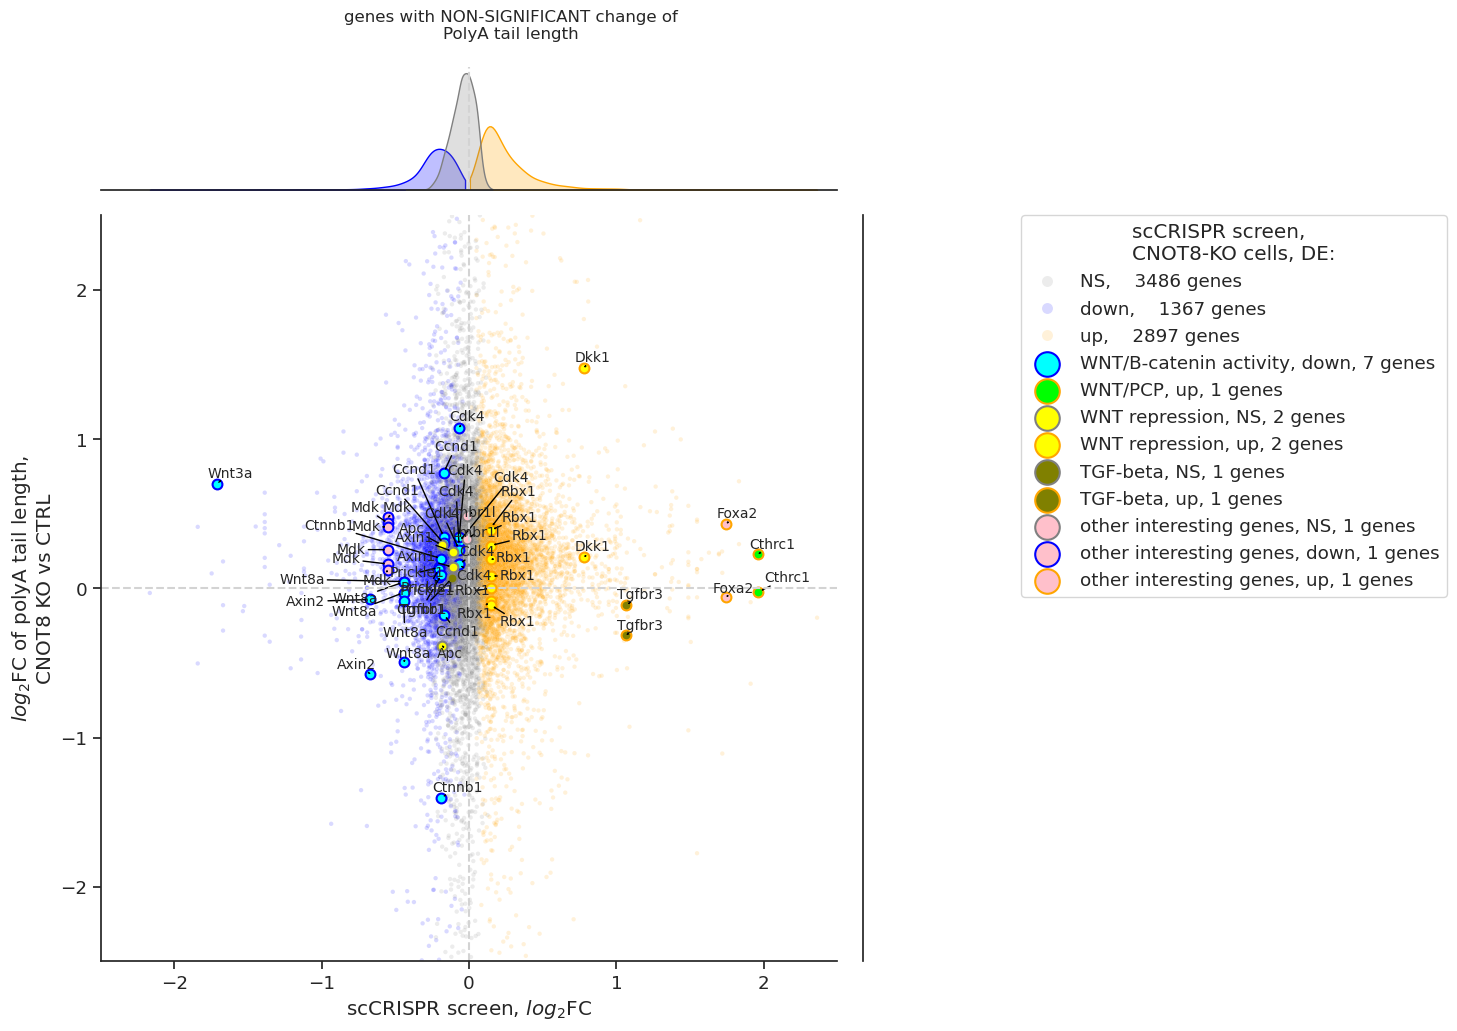

In [27]:
sns.set(font_scale=1.2)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

genes_of_interest_dict = {
                        # 'Cnot complex':['Cnot8, Cnot7, Cnot9','white'],
                     'WNT/B-catenin activity':['Ctnnb1, Axin2, Wnt1, Wnt8a, Wnt3a, Cdkn2b, Ccnd1, Cdk4, Prickle1','cyan'],
                    'WNT/PCP':['Cthrc1','lime'],
                     'WNT repression':['Axin1, Apc, Dkk1, Sox9, Rbx1','yellow'],
                     'TGF-beta':['Tgfb1, Tgfb2, Tgfb3, Tgfbr1, Tgfbr3','olive'],
                    'other interesting genes':['Foxa2, Tbxt, Sox2, Lmbr1l, Mdk, Nog, Apoe','pink']
                        }

version = 'new'
cohorts = [['up'],['NS']]
cohort_labels = ['SIGNIFICANTLY increased','NON-SIGNIFICANT change of']
j=0
for cohort in cohorts:
    data = regr_results.loc[(~regr_results['lfc_'+version].isna())&(regr_results['Diff_pt'].isin(cohort))].reset_index(drop=True).copy()
    
    x_feature,y_feature,hue_feature = 'lfc_'+version,'condition_KO-mean','DE_'+version
    hue_order = ['NS','down','up']
    palette = ['grey','blue','orange']

    new_hue_order = []
    map_dict = {}
    for val in hue_order:
        new_val = str(val)+',    '+str(len(data.loc[data[hue_feature]==val]['dirty_gene_name'].unique()))+' genes'
        new_hue_order.append(new_val)
        map_dict[val]=new_val
    data[hue_feature] = data[hue_feature].map(map_dict)
    hue_order = new_hue_order
    
    g = sns.jointplot(data = data,
                      x=x_feature,y=y_feature,hue=hue_feature,
                      palette = palette,hue_order = hue_order,
                      marginal_kws={'common_norm': True,'cut':0,'bw_adjust':1.5},
                      alpha=0.15,s=10,ratio=5,height=10,)
    ax = g.ax_joint
    
    iqr_y = data[y_feature].quantile(0.75)-data[y_feature].quantile(0.25)
    # data[y_feature].quantile(0.25)-1.5*iqr_y,data[y_feature].quantile(0.75)+iqr_y*1.5
    ax.set(ylim=(-2.5,2.5),xlim=(-2.5,2.5))
    
    ax.tick_params(bottom=True,left=True)
    ax.set(xlabel = 'scCRISPR screen, $log_2$FC',ylabel='$log_2$FC of polyA tail length,\nCNOT8 KO vs CTRL')
    ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='lightgrey',lw=1.5)
    ax.vlines(x=0,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='lightgrey',lw=1.5)

    texts = []
    for gene_category in genes_of_interest_dict:
        genes_of_interest = genes_of_interest_dict[gene_category][0].split(', ')
        fill_color = genes_of_interest_dict[gene_category][1]
        data_sel = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_of_interest))].reset_index()
        
        k=0
        for val in hue_order:
            ax = sns.scatterplot(data = data_sel.loc[data_sel[hue_feature]==val],
                                 x=x_feature,y=y_feature,s=(50 if val=='NS' else 50),
                                 color=fill_color,label=gene_category+', '+val.split(', ')[0]+', '+str(len(data_sel.loc[data_sel[hue_feature]==val]['dirty_gene_name'].unique()))+' genes',
                                 alpha=(1 if val=='NS' else 1),edgecolor=(palette[k] if val!='NS' else None),linewidth=1.5)
            k=k+1
        
        for index,row in data_sel.iterrows():
            texts.append(ax.annotate(row['dirty_gene_name'],(row[x_feature],row[y_feature]),ha='right',va='bottom',size=10))
    %time adjust_text(texts,arrowprops=dict(arrowstyle='->', color='black'),ax=ax,min_arrow_len=1,)
    
    ax.legend(bbox_to_anchor=(1.25, 1),loc=2,borderaxespad=0.0,title='scCRISPR screen,\nCNOT8-KO cells, DE:',markerscale=2.5,ncol=1)
    
    g.fig.suptitle('genes with '+cohort_labels[j]+'\nPolyA tail length', x = 0.5, y = 1.03, fontsize = 12)

    ax_y = g.ax_marg_y
    ax_y.hlines(y=0,xmin=ax_y.get_xlim()[0],xmax=ax_y.get_xlim()[1],linestyle='--',color='lightgrey',lw=1.5)
    if j!=0:
        ax_y.set(xlim=(-0.02,-0.01))
    ax_x = g.ax_marg_x
    ax_x.vlines(x=0,ymin=ax_x.get_ylim()[0],ymax=ax_x.get_ylim()[1],linestyle='--',color='lightgrey',lw=1.5)

    out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
    g.savefig(subdirs['figures_dir']+'differential_analysis_retake/tmp.'+str(j)+'.png',bbox_inches='tight',dpi=300)
    j=j+1

# combine images
from PIL import Image

images = [Image.open(subdirs['figures_dir']+'differential_analysis_retake/'+'tmp.'+str(x)+'.png') for x in range(0,len(cohorts))]
widths, heights = zip(*(i.size for i in images))

total_width = sum(widths)
max_height = max(heights)

new_im = Image.new('RGB', (total_width, max_height))

x_offset = 0
for im in images:
  new_im.paste(im, (x_offset,0))
  x_offset += im.size[0]

new_im.save(subdirs['figures_dir']+'differential_analysis_retake/2.scCRISPRde_vs_PolyAtail_length_lfc.png')
out = subprocess.check_output('rm '+' '.join([subdirs['figures_dir']+'differential_analysis_retake/'+'tmp.'+str(x)+'.png' for x in range(0,len(cohorts))]), shell=True)

CPU times: user 1.53 s, sys: 8 μs, total: 1.53 s
Wall time: 1.53 s


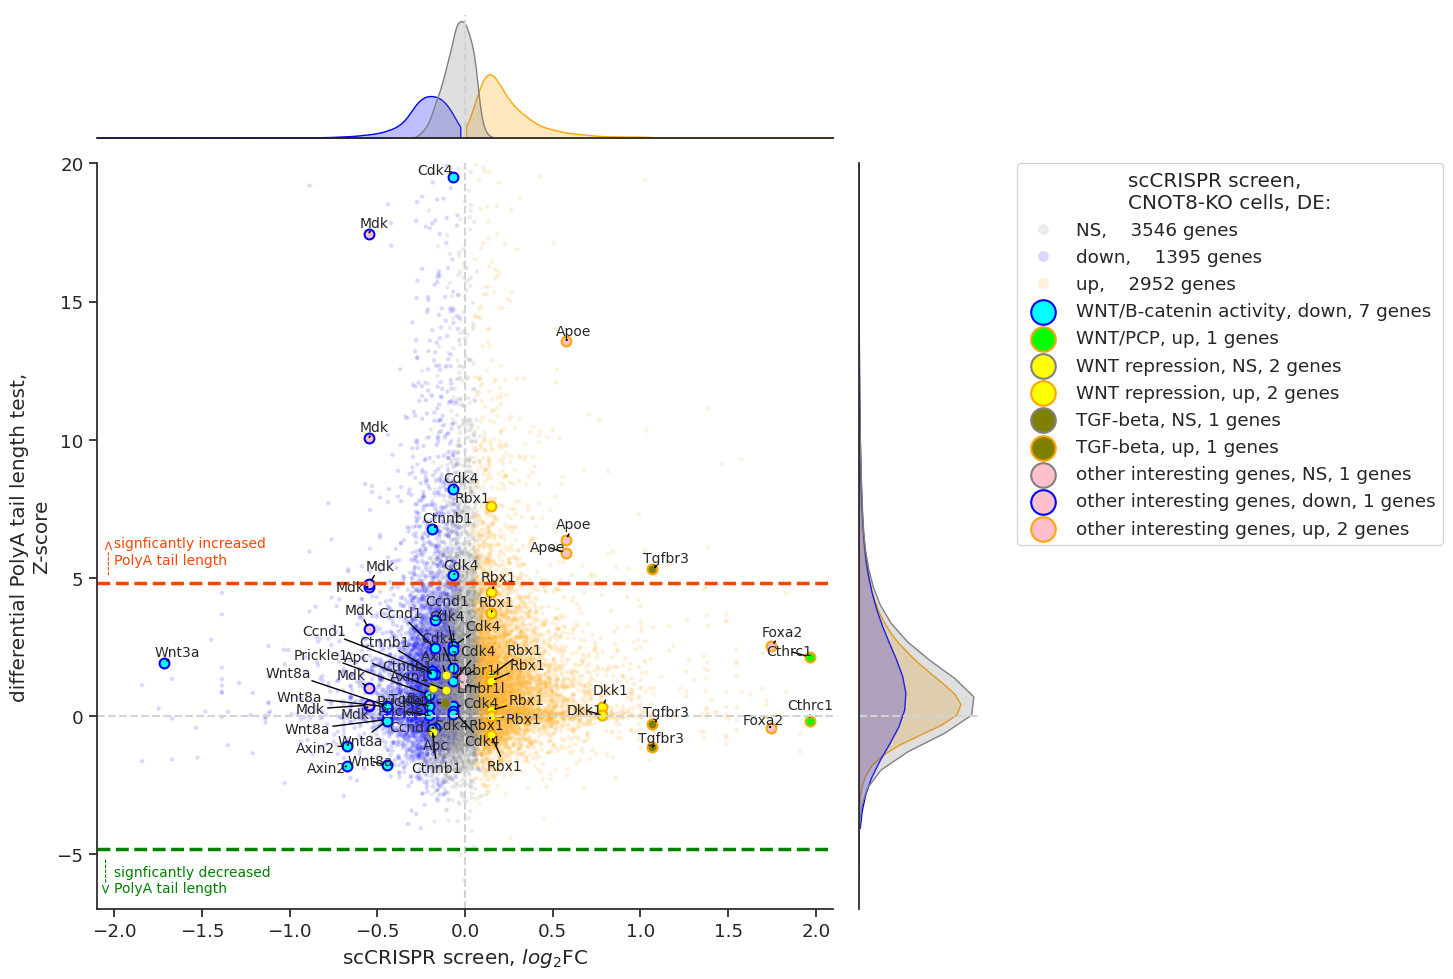

In [28]:
sns.set(font_scale=1.2)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

genes_of_interest_dict = {
                        # 'Cnot complex':['Cnot8, Cnot7, Cnot9','white'],
                     'WNT/B-catenin activity':['Ctnnb1, Axin2, Wnt1, Wnt8a, Wnt3a, Cdkn2b, Ccnd1, Cdk4, Prickle1','cyan'],
                    'WNT/PCP':['Cthrc1','lime'],
                     'WNT repression':['Axin1, Apc, Dkk1, Sox9, Rbx1','yellow'],
                     'TGF-beta':['Tgfb1, Tgfb2, Tgfb3, Tgfbr1, Tgfbr3','olive'],
                    'other interesting genes':['Foxa2, Tbxt, Sox2, Lmbr1l, Mdk, Nog, Apoe','pink']
                        }

version = 'new'
cohorts = [['up','down','NS']]
cohort_labels = ['ALL']
j=0
for cohort in cohorts:
    data = regr_results.loc[(~regr_results['lfc_'+version].isna())&(regr_results['Diff_pt'].isin(cohort))].reset_index(drop=True).copy()
    
    x_feature,y_feature,hue_feature = 'lfc_'+version,'condition_KO-z_score','DE_'+version
    hue_order = ['NS','down','up']
    palette = ['grey','blue','orange']

    new_hue_order = []
    map_dict = {}
    for val in hue_order:
        new_val = str(val)+',    '+str(len(data.loc[data[hue_feature]==val]['dirty_gene_name'].unique()))+' genes'
        new_hue_order.append(new_val)
        map_dict[val]=new_val
    data[hue_feature] = data[hue_feature].map(map_dict)
    hue_order = new_hue_order
    
    g = sns.jointplot(data = data,
                      x=x_feature,y=y_feature,hue=hue_feature,
                      palette = palette,hue_order = hue_order,
                      marginal_kws={'common_norm': True,'cut':0,'bw_adjust':1.5},
                      alpha=0.15,s=10,ratio=5,height=10,)
    ax = g.ax_joint
    ax.set(ylim=(-7,20),xlim=(-2.1,2.1))
    iqr_y = data[y_feature].quantile(0.75)-data[y_feature].quantile(0.25)
    # data[y_feature].quantile(0.25)-1.5*iqr_y,data[y_feature].quantile(0.75)+iqr_y*1.5
    
    ax.tick_params(bottom=True,left=True)
    ax.set(xlabel = 'scCRISPR screen, $log_2$FC',ylabel='differential PolyA tail length test,\nZ-score')
    
    ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='lightgrey',lw=1.5)
    ax.vlines(x=0,ymin=ax.get_ylim()[0],ymax=ax.get_ylim()[1],linestyle='--',color='lightgrey',lw=1.5)
    
    ax.hlines(y=thr_z_score,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='orangered',lw=2.5)
    ax.annotate('signficantly increased\nPolyA tail length\n',(ax.get_xlim()[0]+0.1,thr_z_score),ha='left',va='bottom',size=10,color='orangered')
    ax.annotate('<-----  ',(ax.get_xlim()[0]+0.1,thr_z_score),ha='right',va='bottom',size=10,color='orangered',rotation=270)

    ax.hlines(y=(-1)*thr_z_score,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='green',lw=2.5)
    ax.annotate('\nsignficantly decreased\nPolyA tail length',(ax.get_xlim()[0]+0.1,(-1)*thr_z_score),ha='left',va='top',size=10,color='green')
    ax.annotate('<-----  ',(ax.get_xlim()[0]+0.1,(-1)*thr_z_score),ha='right',va='top',size=10,color='green',rotation=90)
    

    texts = []
    for gene_category in genes_of_interest_dict:
        genes_of_interest = genes_of_interest_dict[gene_category][0].split(', ')
        fill_color = genes_of_interest_dict[gene_category][1]
        data_sel = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_of_interest))].reset_index()
        
        k=0
        for val in hue_order:
            ax = sns.scatterplot(data = data_sel.loc[data_sel[hue_feature]==val],
                                 x=x_feature,y=y_feature,s=(50 if val=='NS' else 50),
                                 color=fill_color,label=gene_category+', '+val.split(', ')[0]+', '+str(len(data_sel.loc[data_sel[hue_feature]==val]['dirty_gene_name'].unique()))+' genes',
                                 alpha=(1 if val=='NS' else 1),edgecolor=(palette[k] if val!='NS' else None),linewidth=1.5)
            k=k+1
        
        for index,row in data_sel.iterrows():
            texts.append(ax.annotate(row['dirty_gene_name'],(row[x_feature],row[y_feature]),ha='right',va='bottom',size=10))
    %time adjust_text(texts,arrowprops=dict(arrowstyle='->', color='black'),ax=ax,min_arrow_len=1,)
    
    ax.legend(bbox_to_anchor=(1.25, 1),loc=2,borderaxespad=0.0,title='scCRISPR screen,\nCNOT8-KO cells, DE:',markerscale=2.5,ncol=1)

    ax_y = g.ax_marg_y
    ax_y.hlines(y=0,xmin=ax_y.get_xlim()[0],xmax=ax_y.get_xlim()[1],linestyle='--',color='lightgrey',lw=1.5)
    # ax_y.set(xlim=(-0.02,-0.01))
    ax_x = g.ax_marg_x
    ax_x.vlines(x=0,ymin=ax_x.get_ylim()[0],ymax=ax_x.get_ylim()[1],linestyle='--',color='lightgrey',lw=1.5)

    out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
    g.savefig(subdirs['figures_dir']+'differential_analysis_retake/3.scCRISPRde_vs_PolyAtail_length_Z_score.png',bbox_inches='tight',dpi=300)
    j=j+1

In [29]:
regr_results.columns

Index(['chr', 'strand', 'contig', 'cluster_id', 'isoform_start', 'isoform_end',
       'isoform_id', 'num_of_splice_sites', 'total_transcript_length',
       'annotated_transcript_id', 'annotated_gene_name', 't',
       'dirty_gene_name', 'isoform_full_id', 'qs-std', 'qs-mean',
       'replicate_R2-std', 'replicate_R2-mean', 'condition_KO-std',
       'condition_KO-mean', 'qs-z_score', 'qs-z_score;sign',
       'replicate_R2-z_score', 'replicate_R2-z_score;sign',
       'condition_KO-z_score', 'condition_KO-z_score;sign', 'Diff_pt',
       'pt-mean;CTRL_1', 't-sum;CTRL_1', 'pt-mean;CTRL_2', 't-sum;CTRL_2',
       'CTRL-mean pt', 'FC', 'lfc_old', 'pval_old', 'fdr_old', 'DE_old',
       'lfc_new', 'pval_new', 'fdr_new', 'DE_new'],
      dtype='object')

In [30]:
regr_results.head()

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id,...,CTRL-mean pt,FC,lfc_old,pval_old,fdr_old,DE_old,lfc_new,pval_new,fdr_new,DE_new
0,chr10,+,NaN,5260,127629687,127629874,10023_+,0,188,NaN,...,131.115385,0.936265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr10,-,"121590220,121593667,121593723,121596184,121596...",10664,121587380,121626509,1002_-,48,6176,NaN,...,101.679487,1.129150,NaN,NaN,NaN,NaN,0.056758,0.147914,0.213180,NS
2,chr10,+,NaN,5324,128017621,128017835,10049_+,0,215,NaN,...,138.236111,0.979107,0.221762,0.019274,0.13368,NS,-0.117732,0.089643,0.138604,NS
3,chr10,+,"127281401,127278408,127278317,127278222,127278...",5209,127266283,127281807,1005_+,26,1745,NaN,...,90.505000,1.187957,-0.102737,0.818618,0.84869,NS,0.012607,0.094889,0.145446,NS
4,chr10,+,"127281401,127278408,127278317,127278222,127278...",5211,127266290,127281968,1006_+,26,1899,NaN,...,102.619142,1.165328,-0.102737,0.818618,0.84869,NS,0.012607,0.094889,0.145446,NS


In [45]:
rename_dict = {'condition_KO-mean':'Diff_pt-lfc',
               'condition_KO-std':'Diff_pt-std',
               'condition_KO-z_score':'Diff_pt-Z_score'}

out_table = regr_results[[
    'isoform_full_id','annotated_transcript_id','annotated_gene_name','dirty_gene_name',
    'Diff_pt','condition_KO-mean','condition_KO-std','condition_KO-z_score',
       'CTRL-mean pt',
        'lfc_old', 'pval_old', 'fdr_old', 'DE_old',
       'lfc_new', 'pval_new', 'fdr_new', 'DE_new',
        'chr', 'strand','isoform_start', 'isoform_end', 'contig']].rename(columns=rename_dict)
out_table.to_csv(subdirs['tables_dir']+'Differential_PolyAtail_x_scCRISPR_DE.tsv',sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

In [186]:
2897/1367,423/319

(2.119239209948793, 1.3260188087774294)

In [129]:
regr_results.columns

Index(['chr', 'strand', 'contig', 'cluster_id', 'isoform_start', 'isoform_end',
       'isoform_id', 'num_of_splice_sites', 'total_transcript_length',
       'annotated_transcript_id', 'annotated_gene_name', 't',
       'dirty_gene_name', 'isoform_full_id', 'qs-std', 'qs-mean',
       'replicate_R2-std', 'replicate_R2-mean', 'condition_KO-std',
       'condition_KO-mean', 'qs-z_score', 'qs-z_score;sign',
       'replicate_R2-z_score', 'replicate_R2-z_score;sign',
       'condition_KO-z_score', 'condition_KO-z_score;sign', 'Diff_pt',
       'pt-mean;CTRL_1', 't-sum;CTRL_1', 'pt-mean;CTRL_2', 't-sum;CTRL_2',
       'CTRL-mean pt', 'FC', 'condition_KO-z_score_div10'],
      dtype='object')

In [149]:
new_crispr_screen_res.head()

,feature,dirty_gene_name,avgExpr,statistic,auc,pval_new,padj,pct_in,pct_out,ko,ctrl,lfc_new,log2FC,fdr_new,DE_new
0,0610009B22Rik,Cnot8,0.365549,3071289.0,0.554380,7.763173e-14,6.359195e-13,41.880809,30.703202,0.624968,0.457224,0.379662,0.138550,6.359195e-13,up
1,0610010F05Rik,Cnot8,0.224542,2874451.0,0.518850,3.302863e-03,7.408016e-03,26.899945,22.449653,0.379560,0.333289,0.146381,0.040649,7.408016e-03,up
2,0610012G03Rik,Cnot8,0.436324,2925389.5,0.528045,3.030009e-04,8.429385e-04,48.879169,41.069660,0.762270,0.696943,0.113662,0.069597,8.429385e-04,up
3,0610030E20Rik,Cnot8,0.101720,2758865.5,0.497986,6.892333e-01,7.539421e-01,13.231274,13.238693,0.161366,0.187116,-0.135562,-0.016072,7.539421e-01,NS
4,1110002L01Rik,Cnot8,0.184735,2750485.5,0.496474,5.743712e-01,6.533150e-01,22.689995,22.812810,0.304041,0.328683,-0.085411,-0.016135,6.533150e-01,NS


In [150]:
Counter(new_crispr_screen_res['DE_new'])

Counter({'NS': 3903, 'up': 3385, 'down': 1567})

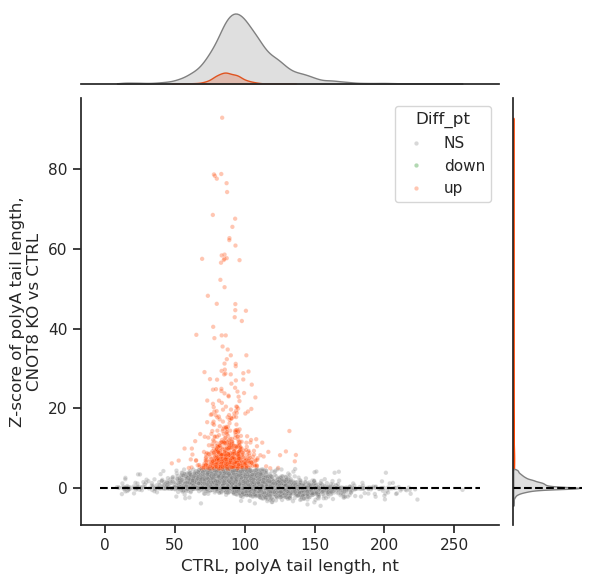

In [113]:
sns.set(font_scale=1)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

data = regr_results.copy()

x_feature,y_feature,hue_feature = 'CTRL-mean pt','condition_KO-z_score','Diff_pt'
hue_order = ['NS','down','up']
palette = ['grey','green','orangered']

g = sns.jointplot(data = data.sample(10000),
                  x=x_feature,y=y_feature,hue=hue_feature,
                  palette = palette,hue_order = hue_order,
                  marginal_kws={'common_norm': True,'cut':0},
                  alpha=0.3,s=10,)
ax = g.ax_joint
# ax.set(ylim=(-2.5,2.5))
ax.tick_params(bottom=True,left=True)
ax.set(xlabel = 'CTRL, polyA tail length, nt',ylabel='Z-score of polyA tail length,\nCNOT8 KO vs CTRL')
ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='black',lw=1.5)
# ax.legend(bbox_to_anchor=(1.25, 1),loc=2,borderaxespad=0.0,title='differential PolyA tail\nlength analysis:',markerscale=2.5,ncol=1)

ax_x = g.ax_marg_y
ax_x.hlines(y=0,xmin=ax_x.get_xlim()[0],xmax=ax_x.get_xlim()[1],linestyle='--',color='black',lw=1.5)

# out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
# fig.savefig(subdirs['figures_dir']+'differential_analysis_retake/2.z_score_pt.no_highlighted_genes.png',bbox_inches='tight',dpi=600)

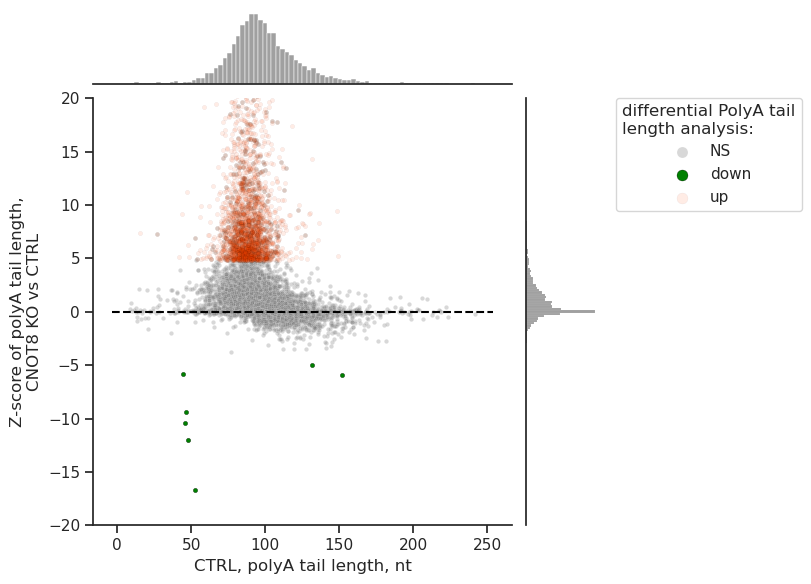

In [109]:
sns.set(font_scale=1)
sns.set_style("white")
# fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

data = regr_results.copy()

x_feature,y_feature,hue_feature = 'CTRL-mean pt','condition_KO-z_score','Diff_pt'
hue_order = ['NS','down','up']
palette = ['grey','green','orangered']

k=0
for val in hue_order:
    if k==0:
        g = sns.jointplot(data = data.sample(5000),
                          x=x_feature,y=y_feature,s=(10 if val=='NS' else 10),
                          label='NS',color=palette[k],alpha=(0.3 if val=='NS' else 1))
    else:
        ax = g.ax_joint
        ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,
                             s=(10 if val=='NS' else 10),label=val,color=palette[k],alpha=(1 if val=='down' else 0.1),
                             edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

ax.set(ylim=(-20,20))
ax.tick_params(bottom=True,left=True)
ax.set(xlabel = 'CTRL, polyA tail length, nt',ylabel='Z-score of polyA tail length,\nCNOT8 KO vs CTRL')
ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='black',lw=1.5)
ax.legend(bbox_to_anchor=(1.25, 1),loc=2,borderaxespad=0.0,title='differential PolyA tail\nlength analysis:',markerscale=2.5,ncol=1)

# ax_x = g.ax_marg_y
# ax_x.hlines(y=0,xmin=ax_x.get_xlim()[0],xmax=ax_x.get_xlim()[1],linestyle='--',color='black',lw=1.5)

# out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
# fig.savefig(subdirs['figures_dir']+'differential_analysis_retake/2.z_score_pt.no_highlighted_genes.png',bbox_inches='tight',dpi=600)

In [55]:
data.loc[data['dirty_gene_name'].str.contains('Cnot8')].head()[['isoform_id','annotated_transcript_id','annotated_gene_name','dirty_gene_name','Diff_pt',
        'qs-mean','qs-std', 'qs-z_score',
       'replicate_R2-mean','replicate_R2-std','replicate_R2-z_score',
       'condition_KO-mean',  'condition_KO-std','condition_KO-z_score',
       'pt-mean;CTRL_1', 't-sum;CTRL_1', 'pt-mean;CTRL_2', 't-sum;CTRL_2']]

,isoform_id,annotated_transcript_id,annotated_gene_name,dirty_gene_name,Diff_pt,qs-mean,qs-std,qs-z_score,replicate_R2-mean,replicate_R2-std,replicate_R2-z_score,condition_KO-mean,condition_KO-std,condition_KO-z_score,pt-mean;CTRL_1,t-sum;CTRL_1,pt-mean;CTRL_2,t-sum;CTRL_2
3753,6717_+,NaN,NaN,Cnot8,NS,-0.080254,0.049173,-1.632073,-0.391531,0.215787,-1.814433,0.535459,0.225706,2.372374,125.625,16,107.625,24


In [ ]:
k=0
for val in hue_order:
    ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,s=(5 if val=='NS' else 10),label=val,color=palette[k],alpha=(0.1 if val=='NS' else 1),edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

genes_of_interest = 'Wnt1, Wnt2, Wnt2B, Wnt3, Wnt3A, Wnt4, Wnt5A, Wnt5B, Wnt6, Wnt7A, Wnt7B, Wnt8A, Wnt8B, Wnt9A, Wnt9B, Wnt10A, Wnt10B, Wnt11, Wnt16'
genes_of_interest = genes_of_interest.split(', ')

data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')
data = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_of_interest))].reset_index()

x_feature,y_feature,hue_feature = 'CTRL_pt','delta_pt','DGE_label'
hue_order = ['NS','down','up']
palette = ['black','green','orangered']

k=0
for val in hue_order:
    ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,s=(10 if val=='NS' else 10),label='Wnt genes, '+val,color=palette[k],alpha=(1 if val=='NS' else 1),edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)
ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='Diff expr\nresult:',markerscale=3)
ax.set(ylim=(-100,100),xlim=(0,200),xlabel='CTRL, polyA tail length, nt',ylabel='$\Delta$, CNOT8 KO vs CTRL')

texts = []
for index,row in data.loc[abs(data['delta_pt'])>25].iterrows():
    texts.append(ax.annotate(row['dirty_gene_name'],(row[x_feature],row[y_feature]),ha='right',va='bottom',size=10))
%time adjust_text(texts,arrowprops=dict(arrowstyle='-', color='black'),ax=ax,min_arrow_len=15)


In [94]:
regr_results.loc[regr_results['condition_KO-z_score;sign']==True].head()

,chr,strand,contig,cluster_id,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,annotated_transcript_id,...,qs-z_score,qs-z_score;sign,replicate_R2-z_score,replicate_R2-z_score;sign,condition_KO-z_score,condition_KO-z_score;sign,pt-mean;CTRL_1,t-sum;CTRL_1,pt-mean;CTRL_2,t-sum;CTRL_2
33,chr10,+,"128011930,128011859",5323,128011742,128012221,1123_+,2,410,NaN,...,-1.948976,False,-1.720171,False,5.795684,True,93.252874,87,90.019417,103
51,chr10,+,"128048493,128048367,128048245,128048127,128047...",5345,128035655,128048633,1210_+,12,10412,NaN,...,-4.460497,False,-2.407982,False,7.574605,True,91.648352,182,84.764706,187
55,chr10,+,"128048493,128048367,128048245,128048127,128047...",5345,128034163,128048633,1228_+,16,1561,NaN,...,-23.789927,True,-5.067718,True,36.809966,True,89.602618,1910,87.503660,2186
75,chr10,+,"128076067,128075362,128075338,128074284,128074...",5363,128058993,128076992,1327_+,10,2959,NaN,...,1.502842,False,0.375666,False,9.354166,True,102.565041,246,102.920000,275
80,chr10,+,"128076067,128075362,128075338,128074284,128074...",5365,127932045,128077255,1362_+,20,3143,NaN,...,3.984016,False,1.277444,False,7.997819,True,106.659649,285,109.058296,223


In [85]:
gr.head()

,isoform_full_id,sample,t-sum,pt-max,pt-median,pt-std,pt-mean,pt-min,sigma_sq
0,chr10_0_+,CTRL_1,0,NaN,NaN,NaN,NaN,NaN,NaN
1,chr10_0_+,CTRL_2,1,62.0,62.0,NaN,62.0,62.0,NaN
2,chr10_0_+,Cnot8_KO_1,0,NaN,NaN,NaN,NaN,NaN,NaN
3,chr10_0_+,Cnot8_KO_2,0,NaN,NaN,NaN,NaN,NaN,NaN
4,chr10_0_-,CTRL_1,0,NaN,NaN,NaN,NaN,NaN,NaN


In [87]:
CTRL_mean_pt.head()

,isoform_full_id,pt-mean;CTRL_1,t-sum;CTRL_1,pt-mean;CTRL_2,t-sum;CTRL_2
0,chr10_0_+,NaN,0,62.0,1
1,chr10_0_-,NaN,0,87.0,1
2,chr10_10000_+,NaN,0,NaN,0
3,chr10_10001_+,80.0,1,NaN,0
4,chr10_10002_+,NaN,0,NaN,0


In [37]:
gr_gr.loc[gr_gr['t-sum']==5].head()

,isoform_full_id,t-sum
352,chr10_1093_+,5
379,chr10_1104_-,5
418,chr10_1124_+,5
722,chr10_1264_-,5
879,chr10_1338_-,5


In [74]:
from statsmodels.regression.linear_model import OLS
a = []
k=0
for b in range(0,200):
    x = stats.norm.rvs(5,10,250)
    e = stats.norm.rvs(0,1,250)
    y = 10+5*x+e
    X = sm.add_constant(x)
    
    mod = OLS(endog = y,exog = X)
    reg = mod.fit()
    resid = y-reg.predict(X)
    a.append([k,np.mean(resid),np.std(resid)]+list(reg.params))
    k=k+1

(-4.5843329132821966e-15, 0.9990626111024363)

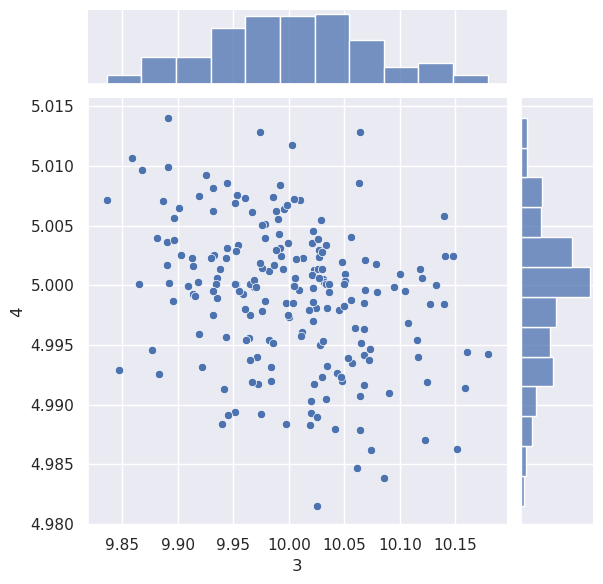

In [75]:
a = pd.DataFrame(a)
sns.jointplot(data = a,x = 3,y=4)
a[1].mean(),a[2].mean()

In [ ]:
# data['null'] = False
# X_pred = np.concatenate((data[['c']].values,data[['replicate']].values,data[['condition']].values),axis=1)
# data['log2_pt_pred'] = reg.predict(X_pred)
# data['pt_pred'] = 2**data['log2_pt_pred']
    
# ax = sns.swarmplot(data = data_cur,x='sample_label',y='log2_pt',color='grey')
# ax = sns.swarmplot(data = data_cur,x='sample',y='log2_pt_pred',color='black')

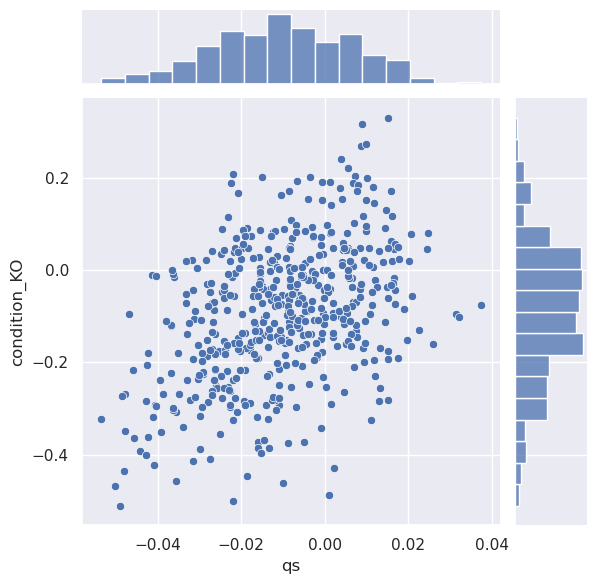

In [41]:
# r_df = pd.DataFrame(r,columns=['boot_id','const','qs','replicate_R2','condition_KO'])
sns.jointplot(data = L_df.loc[L_df['isoform_full_id']=='chr10_1093_+'],x='qs',y='condition_KO')

<Axes: xlabel='log2_pt_centered', ylabel='Count'>

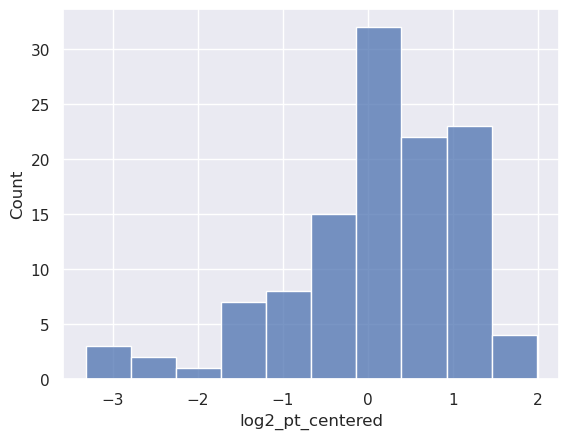

In [83]:
sns.histplot(data_cur['log2_pt_centered'])

In [82]:
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.217
Date:                Wed, 26 Feb 2025   Prob (F-statistic):              0.303
Time:                        14:28:06   Log-Likelihood:                -89.135
No. Observations:                  64   AIC:                             184.3
Df Residuals:                      61   BIC:                             190.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1285      0.216     -0.595      0.554      -0.560       0.303
x1            -0.0286      0.249     -0.115      0.909      -0.527       0.470
x2             0.3882      0.249      1.556      0.125      -0.111       0.887
==============================================================================
Omnibus:                        7.918   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.019   Jarque-Bera (JB):                7.226
Skew:                          -0.715   Prob(JB):                       0.0270
Kurtosis:                       3.816   Cond. No.                         3.19
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

[6.070533092668416, 0.11643720422057102, 0.8115707540034163]

In [24]:
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:                      y   Pseudo R-squared:              0.07858
Model:                       QuantReg   Bandwidth:                       1.317
Method:                 Least Squares   Sparsity:                        2.057
Date:                Wed, 26 Feb 2025   No. Observations:                   16
Time:                        13:41:29   Df Residuals:                       13
                                        Df Model:                            2
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1652      0.418     14.745      0.000       5.262       7.069
x1             0.4083      0.525      0.777      0.451      -0.727       1.543
x2             0.5762      0.538      1.070      0.304      -0.587       1.739
==============================================================================
"""

In [ ]:
from scipy.stats import t
(1-t.cdf(abs(0.466),189))*2

In [187]:
A = np.identity(len(reg.params))
reg.f_test(A)

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=0.7726151971543641, p=0.5442682076782013, df_denom=188, df_num=4>

In [190]:
B = np.array(([1,-1,0,0],[0,0,1,-1])) # inhomogeneity
reg.f_test(B)

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=0.00048038025281406225, p=0.9995197363381901, df_denom=188, df_num=2>

In [201]:
C = np.array(([1,0,-1,0],[0,1,0,-1])) # effect in at least one replicate
reg.f_test(C)

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=0.0006081394716495898, p=0.9993920473736694, df_denom=188, df_num=2>

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:                      y   Pseudo R-squared:              0.01176
Model:                       QuantReg   Bandwidth:                      0.7512
Method:                 Least Squares   Sparsity:                        2.252
Date:                Wed, 26 Feb 2025   No. Observations:                  192
Time:                        09:56:06   Df Residuals:                      188
                                        Df Model:                            3
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             6.3750      6.849      0.931      0.353      -7.136      19.886
x2             6.6149      6.369      1.039      0.300      -5.950      19.180
x3             6.7415      8.350      0.807      0.420      -9.731      23.214
x4             6.5240      9.285      0.703      0.483     -11.792      24.840
==============================================================================
"""

In [171]:
reg.summary() # epa

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:                      y   Pseudo R-squared:            0.0007214
Model:                       QuantReg   Bandwidth:                       48.14
Method:                 Least Squares   Sparsity:                        148.9
Date:                Wed, 26 Feb 2025   No. Observations:                  192
Time:                        09:46:58   Df Residuals:                      189
                                        Df Model:                            2
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         92.9764     10.268      9.055      0.000      72.722     113.230
x1            -3.9764     10.796     -0.368      0.713     -25.274      17.321
x2             6.0000     11.241      0.534      0.594     -16.174      28.174
==============================================================================
"""

In [145]:
np.shape(X)

(192, 2)

<Axes: xlabel='pt', ylabel='Count'>

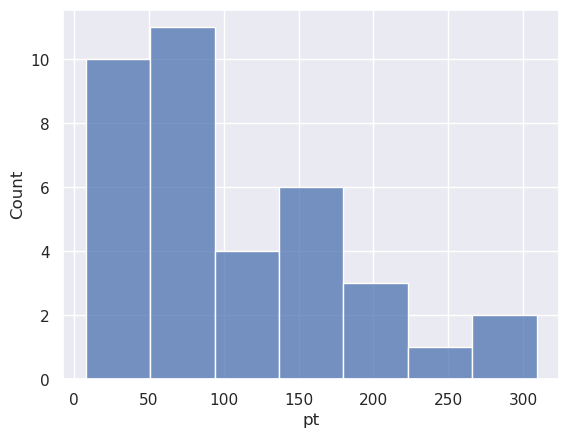

In [126]:
sns.histplot(reads_all_df.loc[(reads_all_df['sample']=='CTRL_1')&(reads_all_df['isoform_full_id']=='chr7_1635_-')]['pt'])

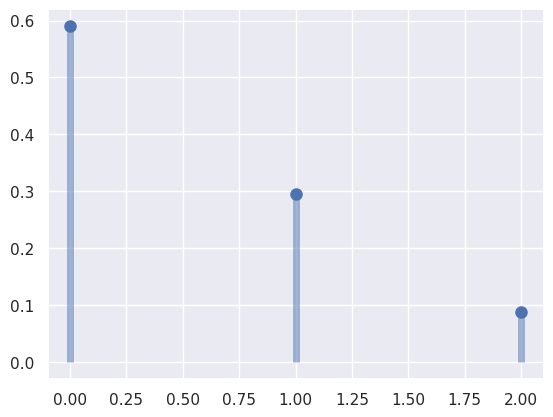

In [100]:
import numpy as np
from scipy.stats import nbinom
fig, ax = plt.subplots(1, 1)
n, p = 5, 0.9
mean, var, skew, kurt = nbinom.stats(n, p, moments='mvsk')

x = np.arange(nbinom.ppf(0.01, n, p),
              nbinom.ppf(0.99, n, p))
ax.plot(x, nbinom.pmf(x, n, p), 'bo', ms=8, label='nbinom pmf')
ax.vlines(x, 0, nbinom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)

<Axes: xlabel='pt', ylabel='Count'>

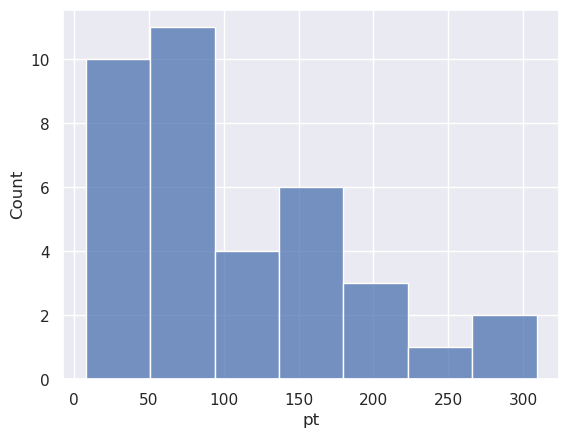

In [8]:
# differential polyA tail lengths

reads_all_df['pt']=reads_all_df['pt'].astype('float')
gr = reads_all_df.groupby(['isoform_full_id','sample']).agg({'pt':np.mean}).reset_index()
gr['pt'] = gr['pt'].fillna(-1) # we have NA when there is no read for that isoform in a sample

length_matrix = pd.pivot_table(gr[['isoform_full_id','sample','pt']],index='isoform_full_id',columns='sample',aggfunc=sum).reset_index()
length_matrix.columns = length_matrix.columns.droplevel(0)
length_matrix = length_matrix.rename(columns={'':'isoform_full_id'})

length_matrix = length_matrix.loc[length_matrix[sample_cols].min(axis=1)>=0].reset_index(drop=True)
length_matrix['delta_pt'] = length_matrix[['Cnot8_KO_1','Cnot8_KO_2']].mean(axis=1)-length_matrix[['CTRL_1','CTRL_2']].mean(axis=1)
length_matrix['CTRL_pt'] = length_matrix[['CTRL_1','CTRL_2']].mean(axis=1)

KeyError: 'isoform_full_id'

CPU times: user 45.3 ms, sys: 44 μs, total: 45.4 ms
Wall time: 45.4 ms


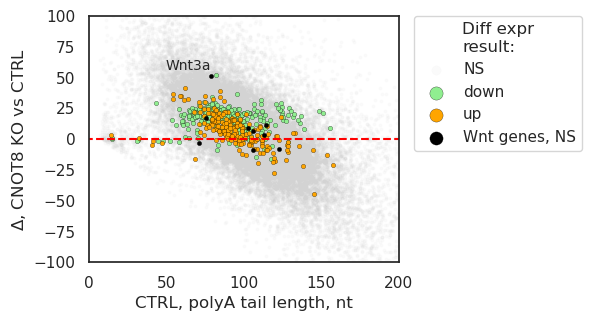

In [275]:
data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')

x_feature,y_feature,hue_feature = 'CTRL_pt','delta_pt','DGE_label'
hue_order = ['NS','down','up']
palette = ['lightgrey','lightgreen','orange']

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

k=0
for val in hue_order:
    ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,s=(5 if val=='NS' else 10),label=val,color=palette[k],alpha=(0.1 if val=='NS' else 1),edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

genes_of_interest = 'Wnt1, Wnt2, Wnt2B, Wnt3, Wnt3A, Wnt4, Wnt5A, Wnt5B, Wnt6, Wnt7A, Wnt7B, Wnt8A, Wnt8B, Wnt9A, Wnt9B, Wnt10A, Wnt10B, Wnt11, Wnt16'
genes_of_interest = genes_of_interest.split(', ')

data = pd.merge(DE_table,length_matrix[['isoform_full_id','CTRL_pt','delta_pt']],how='inner',on='isoform_full_id')
data = data.loc[data['dirty_gene_name'].str.contains('|'.join(genes_of_interest))].reset_index()

x_feature,y_feature,hue_feature = 'CTRL_pt','delta_pt','DGE_label'
hue_order = ['NS','down','up']
palette = ['black','green','orangered']

k=0
for val in hue_order:
    ax = sns.scatterplot(data = data.loc[data[hue_feature]==val],x=x_feature,y=y_feature,s=(10 if val=='NS' else 10),label='Wnt genes, '+val,color=palette[k],alpha=(1 if val=='NS' else 1),edgecolor=('black' if val!='NS' else None),linewidth=0.2)
    k=k+1

ax.hlines(y=0,xmin=ax.get_xlim()[0],xmax=ax.get_xlim()[1],linestyle='--',color='red',lw=1.5)
ax.legend(bbox_to_anchor=(1.05, 1),loc=2,borderaxespad=0.0,title='Diff expr\nresult:',markerscale=3)
ax.set(ylim=(-100,100),xlim=(0,200),xlabel='CTRL, polyA tail length, nt',ylabel='$\Delta$, CNOT8 KO vs CTRL')

texts = []
for index,row in data.loc[abs(data['delta_pt'])>25].iterrows():
    texts.append(ax.annotate(row['dirty_gene_name'],(row[x_feature],row[y_feature]),ha='right',va='bottom',size=10))
%time adjust_text(texts,arrowprops=dict(arrowstyle='-', color='black'),ax=ax,min_arrow_len=15)

# out = subprocess.check_output('mkdir -p '+subdirs['figures_dir']+'differential_analysis_retake/', shell=True)
# fig.savefig(subdirs['figures_dir']+'differential_analysis_retake/1.PolyA_tail_length.scatter.png',bbox_inches='tight',dpi=600)

In [305]:
Counter(data['DGE_label'])

Counter({'NS': 46614, 'down': 332, 'up': 209})

In [302]:
reads_all_df.loc[reads_all_df['isoform_full_id']=='chr11_6716_+']

,chr,start,end,strand,qs,pt,read_id,isoform_id,sample_index,isoform_full_id,t,sample,sample_label
4700356,chr11,58103992,58117847,+,16.750505,154.0,0;64595,6716_+,0,chr11_6716_+,1,Cnot8_KO_1,Cnot8-KO R1
4900236,chr11,58104056,58117847,+,16.496298,58.0,1;78294,6716_+,1,chr11_6716_+,1,Cnot8_KO_2,Cnot8-KO R2
4900238,chr11,58104113,58117847,+,20.606598,200.0,1;78296,6716_+,1,chr11_6716_+,1,Cnot8_KO_2,Cnot8-KO R2
4900241,chr11,58104128,58117847,+,18.943430,86.0,1;78299,6716_+,1,chr11_6716_+,1,Cnot8_KO_2,Cnot8-KO R2
5096591,chr11,58104011,58117847,+,17.743629,19.0,2;51734,6716_+,2,chr11_6716_+,1,CTRL_1,CTRL R1
5096593,chr11,58104021,58117847,+,19.821604,76.0,2;51736,6716_+,2,chr11_6716_+,1,CTRL_1,CTRL R1
5096594,chr11,58104021,58117843,+,15.371362,54.0,2;51737,6716_+,2,chr11_6716_+,1,CTRL_1,CTRL R1
5096596,chr11,58104023,58117847,+,20.636787,12.0,2;51739,6716_+,2,chr11_6716_+,1,CTRL_1,CTRL R1
5096598,chr11,58104043,58117847,+,22.667927,36.0,2;51741,6716_+,2,chr11_6716_+,1,CTRL_1,CTRL R1
5096600,chr11,58104060,58117847,+,22.137480,116.0,2;51743,6716_+,2,chr11_6716_+,1,CTRL_1,CTRL R1


In [300]:
length_matrix.loc[length_matrix['isoform_full_id']=='chr11_6716_+']

sample,isoform_full_id,CTRL_1,CTRL_2,Cnot8_KO_1,Cnot8_KO_2,delta_pt,CTRL_pt
5322,chr11_6716_+,80.842105,83.764706,154.0,114.666667,52.029928,82.303406


In [297]:
data = data.loc[data['dirty_gene_name'].str.contains('|'.join(['Cnot8']))].reset_index()
data

,level_0,index,isoform_full_id,baseMean,log2FoldChange,pvalue,padj,fdr,log2_mean,sign,sign_label,DGE,DGE_label,annotated_transcript_id,dirty_gene_name,gene_name,CTRL_pt,delta_pt
0,0,1063,chr11_6714_+,20.156984,-0.764308,0.009071,0.098041,0.361571,4.403062,0,NS,0,NS,NaN,Cnot8,NaN,97.352273,46.686189
1,1,15493,chr11_6711_+,3.071340,-0.025076,0.468597,NaN,0.998682,2.025504,0,NS,0,NS,NaN,Cnot8,NaN,204.500000,-20.250000
2,2,15495,chr11_6716_+,11.434155,-3.154724,0.000113,NaN,0.014513,3.636237,1,FDR<0.05,-1,down,NaN,Cnot8,NaN,82.303406,52.029928
3,3,15496,chr11_6717_+,15.078685,-1.131902,0.005405,NaN,0.260085,4.007078,0,NS,0,NS,NaN,Cnot8,NaN,116.625000,46.851190
4,4,15499,chr11_6720_+,6.714167,-0.153241,0.008969,NaN,0.360111,2.947510,0,NS,0,NS,NaN,Cnot8,NaN,69.916667,51.416667


In [ ]:
# try deseq2 approach

reads_all_df['pt']=reads_all_df['pt'].astype('float')
gr = reads_all_df.groupby(['isoform_full_id','sample']).agg({'pt':np.mean}).reset_index()
gr['pt'] = gr['pt'].fillna(-1) # we have NA when there is no read for that isoform in a sample

length_matrix = pd.pivot_table(gr[['isoform_full_id','sample','pt']],index='isoform_full_id',columns='sample',aggfunc=sum).reset_index()
length_matrix.columns = length_matrix.columns.droplevel(0)
length_matrix = length_matrix.rename(columns={'':'isoform_full_id'})

counts_df = length_matrix.loc[length_matrix[sample_cols].min(axis=1)>=0].reset_index(drop=True) # analyze further like counts
counts_df[sample_cols] = np.round(counts_df[sample_cols],0).astype('int')

WF_version = 'v2_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'
expression_quantification_dir = general_output_dir+'expression_quantification/'
quantification_dir = expression_quantification_dir+'polyATailLength_quantification/'
deseq_dir = quantification_dir+'deseq/'

out = subprocess.check_output('mkdir -p '+deseq_dir, shell=True)

counts_file_path = deseq_dir+'counts.tsv'
metadata_file_path = deseq_dir+'metadata.tsv'
outdir_path = deseq_dir

counts_df.to_csv(counts_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)
metadata_df[['sample','EXP_CTL']].to_csv(metadata_file_path,sep=str('\t'),header=True,index=None,quoting=csv.QUOTE_NONE)

command = """Rscript """+subdirs['wf_dir']+'scripts/run_deseq2.r'+' '+counts_file_path+' '+metadata_file_path+' EXP '+outdir_path+' fake_gene; '
command

In [167]:
DE_table_path = deseq_dir+'DE_table.tsv'
fdr_thr = 0.05

DE_table = pd.read_csv(DE_table_path,delimiter="\t",index_col=None,header=0)
DE_table = DE_table.rename(columns={'gene_name':'isoform_full_id'})
DE_table['log2FoldChange'] = DE_table['log2FoldChange'].fillna(0)
DE_table['pvalue'] = DE_table['pvalue'].fillna(1)
DE_table['fdr'] = multipletests(DE_table['pvalue'],method='fdr_bh')[1]
DE_table['log2_mean'] = np.log2(DE_table['baseMean']+1)
# DE_table['sign'] = ((DE_table['fdr']<fdr_thr)&(~((abs(DE_table['log2_mean'])<7)&(abs(DE_table['log2FoldChange'])<1)))).astype('int')
DE_table['sign'] = ((DE_table['fdr']<fdr_thr)).astype('int')
DE_table['sign_label'] = DE_table['sign'].astype('str').str.replace('1','FDR<'+str(fdr_thr)).replace('0','NS').astype('category')
DE_table['DGE'] = (DE_table['sign']==1).astype('int')*((DE_table['log2FoldChange']>0).astype('int')*2-1)

DE_table['isoform_full_id'] = DE_table['isoform_full_id'].astype('category')
DE_table = pd.merge(DE_table,isoforms_all_df[['isoform_full_id','annotated_transcript_id','dirty_gene_name']],how='left',on='isoform_full_id')
DE_table = pd.merge(DE_table,transcripts_all_df[['annotated_transcript_id','gene_name']],how='left',on='annotated_transcript_id')

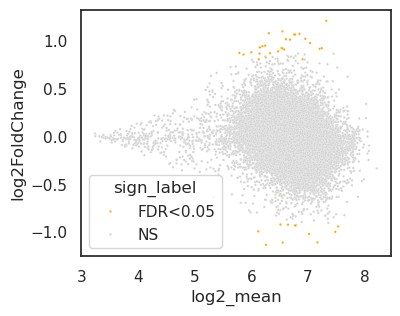

In [171]:
genes_to_show = ['Cnot8']
x_feature,y_feature,hue_feature = 'log2_mean','log2FoldChange','sign_label'
data = DE_table.copy()

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(4,3.2))

ax = sns.scatterplot(data = data,x=x_feature,y=y_feature,hue=hue_feature,s=3,palette=['orange','lightgrey'])

In [160]:
DE_table.loc[DE_table['sign']==1].head()

,isoform_full_id,baseMean,log2FoldChange,pvalue,padj,fdr,log2_mean,sign,sign_label,DGE,annotated_transcript_id,dirty_gene_name,gene_name
0,chr11_9020_-,75.381806,-3.363981,1.721931e-08,0.000812,0.000812,6.255157,1,FDR<0.05,-1,NaN,Top3a,NaN
1,chr16_6324_+,92.838270,-3.142946,4.048194e-08,0.000823,0.000823,6.552105,1,FDR<0.05,-1,NaN,,NaN
2,chr9_9840_+,159.100771,2.257324,5.233918e-08,0.000823,0.000823,7.322836,1,FDR<0.05,1,NaN,Gm16845,NaN
3,chr15_2694_-,142.613703,-2.646238,1.657373e-07,0.001718,0.001718,7.166050,1,FDR<0.05,-1,NaN,"AW549877,Gm49286",NaN
4,chrY_184_-,118.840431,3.969567,1.821531e-07,0.001718,0.001718,6.904971,1,FDR<0.05,1,NaN,,NaN


In [162]:
counts_df.loc[counts_df['isoform_full_id']=='chr11_9020_-']

sample,isoform_full_id,CTRL_1,CTRL_2,Cnot8_KO_1,Cnot8_KO_2
5940,chr11_9020_-,164,105,9,15


In [147]:
gr.head()

,isoform_full_id,sample,pt
0,chr10_0_+,CTRL_1,NaN
1,chr10_0_+,CTRL_2,62.0
2,chr10_0_+,Cnot8_KO_1,NaN
3,chr10_0_+,Cnot8_KO_2,NaN
4,chr10_0_-,CTRL_1,NaN


In [35]:
expr_matrix.head()

sample,isoform_full_id,CTRL_1,CTRL_2,Cnot8_KO_1,Cnot8_KO_2
0,chr10_0_+,0,1,0,0
1,chr10_0_-,0,1,0,0
2,chr10_10000_+,0,0,0,1
3,chr10_10001_+,1,0,0,0
4,chr10_10002_+,0,0,0,1


In [31]:
counts_df['']

sample,isoform_full_id,Cnot8_KO_1,Cnot8_KO_2,CTRL_1,CTRL_2
0,chr10_10023_+,11,15,15,13
1,chr10_1002_-,23,27,13,12
2,chr10_10030_+,2,2,1,1
3,chr10_10049_+,26,25,9,12
4,chr10_1005_+,92,110,60,75


In [103]:
len(a_start),len(a_end),len(a)

(500, 500, 9000)

In [97]:
a[:10]

[0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066,
 0.1791134896975066]

In [75]:
data.iloc[window:].tail()

,gene_id,ONT:Cnot8-KO R2,ONT:Cnot8-KO R1,ONT:CTRL R2,ONT:CTRL R1,Illumina:CTRL R1,Illumina:CTRL R2,Illumina:Cnot8-KO R1,Illumina:Cnot8-KO R2,mean_raw_norm,std_raw_norm,Illumina:log2FC R1,log2_mean,log2fc_abs,lfc,lfc_abs,qcut_mean,cut_mean,lfc_std
447682,Ccnb1ip1.5,6.676304,7.971971,7.803848,7.892578,16.137717,15.623100,15.390878,15.673256,27325.324709,30116.017980,-0.746839,15.880409,0.746839,-0.514617,0.514617,"(3.624, 17.966]","(15.42, 16.693]",0.363889
447683,Rpph1.1,6.676304,7.971971,7.803848,7.892578,16.139975,15.626960,15.395328,15.678107,27394.926921,30185.516175,-0.744647,15.883467,0.744647,-0.513015,0.513015,"(3.624, 17.966]","(15.42, 16.693]",0.362757
447684,mt-Rnr2.1,16.679385,16.550949,17.450909,17.225160,16.736167,17.478375,16.730941,17.139305,134780.374529,34669.046193,-0.005226,17.107271,0.005226,0.742209,0.742209,"(3.624, 17.966]","(16.693, 17.966]",0.524821
447685,Rn7sk.1,6.783061,6.488396,5.721884,5.728246,17.485925,17.707902,16.894648,17.365638,86086.000287,95328.444366,-0.591277,17.596914,0.591277,0.221977,0.221977,"(3.624, 17.966]","(16.693, 17.966]",0.156962
447686,mt-Co1.1,18.613839,18.478276,19.004728,18.766146,17.854509,18.077419,17.542095,17.756299,333005.075536,119955.375022,-0.312414,17.965964,0.312414,0.222910,0.222910,"(3.624, 17.966]","(16.693, 17.966]",0.157621


In [67]:
norm_expr_matrix['cut_mean'] = pd.cut(norm_expr_matrix['log2_mean'],bins=20)

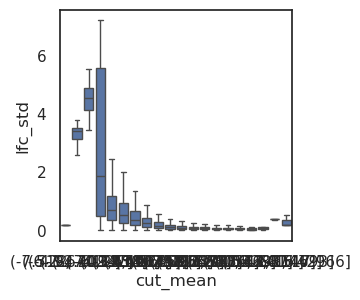

In [70]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=False, figsize=(3,3))

ax = sns.boxplot(data = norm_expr_matrix,x='cut_mean',y='lfc_std',showfliers=False)

In [39]:
norm_expr_matrix

,gene_id,ONT:Cnot8-KO R2,ONT:Cnot8-KO R1,ONT:CTRL R2,ONT:CTRL R1,Illumina:CTRL R1,Illumina:CTRL R2,Illumina:Cnot8-KO R1,Illumina:Cnot8-KO R2,mean_raw_norm,std_raw_norm,Illumina:log2FC R1
0,0610005C13Rik.1,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-4.356146,-3.617572,0.125511,0.105808,3.262982
1,0610005C13Rik.10,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-4.356146,-3.617572,0.125511,0.105808,3.262982
2,0610005C13Rik.11,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-2.356146,-3.617572,0.143821,0.103287,5.262982
3,0610005C13Rik.12,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-7.815578,-3.132146,0.124035,0.110402,-0.196450
4,0610005C13Rik.13,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-4.356146,-3.617572,0.125511,0.105808,3.262982
...,...,...,...,...,...,...,...,...,...,...,...,...
447682,n-R5s96.1,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-7.815578,1.444204,0.449919,0.924314,-0.196450
447683,n-R5s97.1,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-7.815578,-7.524463,0.110457,0.118208,-0.196450
447684,n-R5s98.1,-2.670209,-2.480271,-1.929168,-1.922805,-7.619128,-7.365823,-7.815578,-7.524463,0.110457,0.118208,-0.196450
447685,n-TSaga9.1,-2.670209,-2.480271,-1.929168,-1.922805,1.028330,-7.365823,-1.157367,-7.524463,0.420265,0.670140,-2.185697


In [36]:
sample_EXP,sample_CTL

('Illumina:Cnot8-KO R1', 'Illumina:CTRL R1')

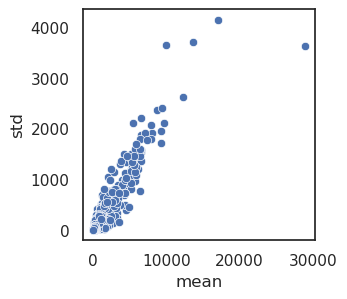

In [233]:
sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(3,3))

ax = sns.scatterplot(data=norm_expr_matrix,x='mean',y='std')

In [237]:
norm_expr_matrix.head()

,isoform_full_id,Cnot8-KO R1,Cnot8-KO R2,CTRL R1,CTRL R2,mean,std
0,chr10_0_+,0.916667,0.8,1.255102,2.43750,1.352317,0.748759
1,chr10_0_-,0.916667,0.8,1.255102,2.43750,1.352317,0.748759
2,chr10_10000_+,0.916667,1.6,1.255102,1.21875,1.247630,0.279637
3,chr10_10001_+,0.916667,0.8,2.510204,1.21875,1.361405,0.785930
4,chr10_10002_+,0.916667,1.6,1.255102,1.21875,1.247630,0.279637


In [220]:
expr_matrix[samples].head()

sample_label,Cnot8-KO R1,Cnot8-KO R2,CTRL R1,CTRL R2
0,0,0,0,1
1,0,0,0,1
2,0,1,0,0
3,0,0,1,0
4,0,1,0,0


In [222]:
1/0.8

1.25

In [221]:
SFs

[1.1, 1.2669039145907472, 0.775, 0.8]

In [ ]:
# Differential analysis for isoform expression vs 

[(0.0, 250.0)]

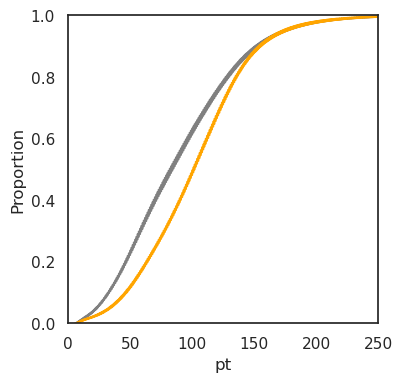

In [79]:
num_rows = len(metadata_df['condition'].unique())
condition_cats,condition_colors = ['CTRL','Cnot8_KO'],['grey','orange']
sample_replicates,replicate_colors = [1,2],['royalblue','green']

x_feature,x_feature_label = 'pt','polyA tail length, nt'

sns.set(font_scale=1)
sns.set_style("white")
fig, axes = plt.subplots(1, 1, sharey=False, sharex=True, figsize=(4,4))

i=0
for condition_cat in condition_cats:
    cur_metadata = metadata_df.loc[metadata_df['condition']==condition_cat]
    k=0
    for sample_replicate in sample_replicates:
        replicate_metadata = cur_metadata.loc[cur_metadata['replicate']==sample_replicate].reset_index(drop=True)
        sample_index = replicate_metadata.iloc[0]['sample_index']
        
        data = reads_all_df.loc[reads_all_df['sample_index']==sample_index].reset_index(drop=True)

        ax = sns.ecdfplot(data = data,x=x_feature,color=condition_colors[i])
        k=k+1
    i=i+1
ax.set(xlim=(0,250))

In [66]:
metadata_df

,sample,sample_index,condition
0,Cnot8_KO_1,0,Cnot8_KO
1,Cnot8_KO_2,1,Cnot8_KO
2,CTRL_1,2,CTRL
3,CTRL_2,3,CTRL


In [49]:

reads_all_df

,chr,start,end,strand,qs,pt,read_id,isoform_id,sample_index
0,chr1,3322816,3421903,-,14.375256,137,0;0,5273_-,0
1,chr1,3630788,3630903,-,17.092749,53,0;1,9020_-,0
2,chr1,3670016,3671595,-,9.283449,80,0;2,5572_-,0
3,chr1,3670445,3670641,-,18.171364,202,0;3,9024_-,0
4,chr1,3670549,3671604,-,14.375256,137,0;4,9025_-,0


# Drafts

In [200]:
# make a test bam file
command = """samtools view --with-header --subsample 0.01 -b -u \
/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/CTRL_1.sorted.uniquely_mapped.bam | \
samtools sort -@ 10 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_CTL_1.bam; \
samtools index -@ 10 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_CTL_1.bam"""
command

'samtools view --with-header --subsample 0.01 -b -u /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/CTRL_1.sorted.uniquely_mapped.bam | samtools sort -@ 10 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_CTL_1.bam; samtools index -@ 10 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_CTL_1.bam'

In [201]:
# make a test bam file
command = """samtools view --with-header --subsample 0.01 -b -u \
/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/Cnot8_KO_1.sorted.uniquely_mapped.bam | \
samtools sort -@ 10 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_Cnot8_KO_1.bam; \
samtools index -@ 10 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_Cnot8_KO_1.bam"""
command

'samtools view --with-header --subsample 0.01 -b -u /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/Cnot8_KO_1.sorted.uniquely_mapped.bam | samtools sort -@ 10 -o /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_Cnot8_KO_1.bam; samtools index -@ 10 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_Cnot8_KO_1.bam'

In [137]:


almnt_file_paths = pd.read_csv('/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/lists_of_files/chrM.txt',delimiter="\t",index_col=None,header=None)
almnt_file_paths = list(almnt_file_paths[0])
# for further compact storage, assign integer ids to input bam files
sample_ids = list(range(0,len(almnt_file_paths)))


In [140]:
# get annotation file and extract annotated transcript isoforms in the same manner as observed ones

gtf = pd.read_csv('/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/gtf_over_chromosomes/chrM.gtf',delimiter="\t",index_col=None,header=None,skiprows=0)

In [142]:
transcripts = gtf.loc[gtf[2]=='transcript'].reset_index(drop=True)
transcripts['transcript_id'] = transcripts[8].str.split('transcript_id "',expand=True)[1].str.split('";',expand=True)[0]

transcript_ends_bed = pd.concat([transcripts.loc[transcripts[6]=='+'][[0,4,'transcript_id',6]].reset_index(drop=True),
                           transcripts.loc[transcripts[6]=='-'][[0,3,'transcript_id',6]].reset_index(drop=True).rename(columns={3:4})]).reset_index(drop=True)
transcript_ends_bed.columns = ['chr','end','read_id','strand']

In [143]:
exons = gtf.loc[gtf[2]=='exon'].reset_index(drop=True)
exons['transcript_id'] = exons[8].str.split('transcript_id "',expand=True)[1].str.split('";',expand=True)[0]

In [144]:
# obtain introns on + strand
exons_plus = exons.loc[exons[6]=='+'].sort_values([0,'transcript_id',3,4],ascending=[True,True,True,True]).reset_index(drop=True)

cur_transcript = ''
a = []
for elem in exons_plus[[0,3,4,6,'transcript_id']].values:
    if elem[4]==cur_transcript:
        a.append([elem[0],pred_end,elem[1],elem[3],cur_transcript])
    cur_transcript = elem[4]
    pred_end = elem[2]
introns_plus = pd.DataFrame(a,
                            columns=['chr','start','end','strand','read_id']).sort_values(
    ['chr','strand','read_id','end','start'],ascending=[True,True,True,False,False]).reset_index(drop=True)
introns_plus['coords'] = introns_plus['end'].astype('str')+','+introns_plus['start'].astype('str')
introns_plus = pd.concat([introns_plus[['read_id','chr','strand']],introns_plus.groupby('read_id')['coords'].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True)

introns_plus = pd.merge(introns_plus,
                        transcripts[['transcript_id',3,4]].rename(columns={'transcript_id':'read_id',3:'start',4:'end'}),
                        how='left',on='read_id')

In [145]:
# obtain introns on - strand
exons_minus = exons.loc[exons[6]=='-'].sort_values([0,'transcript_id',3,4],ascending=[True,True,True,True]).reset_index(drop=True)

cur_transcript = ''
a = []
for elem in exons_minus[[0,3,4,6,'transcript_id']].values:
    if elem[4]==cur_transcript:
        a.append([elem[0],pred_end,elem[1],elem[3],cur_transcript])
    cur_transcript = elem[4]
    pred_end = elem[2]
introns_minus = pd.DataFrame(a,
                            columns=['chr','start','end','strand','read_id']).sort_values(
    ['chr','strand','read_id','start','end'],ascending=[True,True,True,True,True]).reset_index(drop=True)
introns_minus['coords'] = introns_minus['end'].astype('str')+','+introns_minus['start'].astype('str')
introns_minus = pd.concat([introns_minus[['read_id','chr','strand']],introns_minus.groupby('read_id')['coords'].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True)

introns_minus = pd.merge(introns_minus,
                        transcripts[['transcript_id',3,4]].rename(columns={'transcript_id':'read_id',3:'start',4:'end'}),
                        how='left',on='read_id')

In [149]:
print("""parsing reads from bam files using HTSeq package\n""")
k = 0
read_coords = []
read_introns = []
for almnt_file_path in almnt_file_paths:
    print('processing bam file: '+almnt_file_path+'\n')
    almnt_file = HTSeq.SAM_Reader( almnt_file_path )
    # all .iv elements follow bed format
    j=0
    for almnt in almnt_file:
        pt = almnt.optional_field("pt")
        qs = almnt.optional_field("qs")
        read_coords.append([k,j,almnt.iv.chrom,almnt.iv.start+1,almnt.iv.end,almnt.iv.strand,qs,pt]) # convert start coordinates to 1-based format
        for cigar_elem in almnt.cigar:
            if cigar_elem.type=='N': # splice junction
                reference_region = cigar_elem.ref_iv
                read_introns.append([k,j,reference_region.start,reference_region.end+1]) # splice junstion coordinates are defined as last and first 1-based positions of flanking exons
        j=j+1
        if j%10000==0:
            print(str(j)+' reads done\n')
    k=k+1
    print('Done with bam file: '+almnt_file_path+'\n')

parsing reads from bam files using HTSeq package

processing bam file: /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chrM.sorted.bam

10000 reads done

20000 reads done

30000 reads done

40000 reads done

50000 reads done

60000 reads done

70000 reads done

80000 reads done

Done with bam file: /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chrM.sorted.bam

processing bam file: /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_2.chrM.sorted.bam

10000 reads done

20000 reads done

30000 reads done

40000 reads done

50000 reads done

60000 reads done

70000 reads done

80000 reads done

90000 reads done

100000 reads done

Done with bam file: /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_2.chrM.sorted.bam

processing bam file: /scicore/home/zavo

In [150]:
###
# get read information as data frame
# this is done both for + and - strands
###
read_coords_df = pd.DataFrame(read_coords,columns=['sample_id','within_sample_read_id','chr','start','end','strand','qs','pt'])
read_coords_df['read_id'] = read_coords_df['sample_id'].astype('str')+';'+read_coords_df['within_sample_read_id'].astype('str')

###
# get split-read information as data frame
# this is done both for + and - strands
###

read_introns_df = pd.DataFrame(read_introns,columns=['sample_id','within_sample_read_id','start','end'])
read_introns_df['read_id'] = read_introns_df['sample_id'].astype('str')+';'+read_introns_df['within_sample_read_id'].astype('str')

# print important info
k=0
for almnt_file_path in almnt_file_paths:
    info = almnt_file_path+'\nnumber of reads: '+str(len(read_coords_df.loc[read_coords_df['sample_id']==k]))
    info = info+'\n'
    info = info+'among them, number of split reads: '+str(len(read_introns_df.loc[read_introns_df['sample_id']==k]['within_sample_read_id'].unique()))
    print(info)
    k=k+1 

print('#################\n\
We then merged reads from samples\n\
#################\n')

read_coords_df = read_coords_df.drop(['sample_id','within_sample_read_id'],axis=1)
read_introns_df = read_introns_df.drop(['sample_id','within_sample_read_id'],axis=1)
read_introns_df = pd.merge(read_introns_df,read_coords_df[['read_id','strand','chr']],how='left',on='read_id')
print('Total number of reads: '+str(len(read_coords_df))+'\n')

/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_1.chrM.sorted.bam
number of reads: 82301
among them, number of split reads: 442
/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/Cnot8_KO_2.chrM.sorted.bam
number of reads: 101282
among them, number of split reads: 565
/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/CTRL_1.chrM.sorted.bam
number of reads: 78464
among them, number of split reads: 326
/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_over_chromosomes/CTRL_2.chrM.sorted.bam
number of reads: 92350
among them, number of split reads: 437
#################
We then merged reads from samples
#################

Total number of reads: 354397



In [151]:
###
# first, cluster the 3'end coordinates of reads
# this is done both for + and - strands
###

read_ends_bed = pd.concat([read_coords_df.loc[read_coords_df['strand']=='+'][['chr','end','read_id','strand']].reset_index(drop=True),
                           read_coords_df.loc[read_coords_df['strand']=='-'][['chr','start','read_id','strand']].reset_index(drop=True).rename(columns={'start':'end'})]).reset_index(drop=True)
# add annotated isoforms
read_ends_bed = pd.concat([read_ends_bed,transcript_ends_bed]).reset_index(drop=True)

read_ends_bed['start'] = read_ends_bed['end']-1
read_ends_bed['score'] = 0
read_ends_bed[['chr','start','end','read_id','score','strand']].to_csv(subdirs['temp_dir']+'read_ends.bed', sep=str('\t'),header=False,index=None)

print("""sorting 3'ends of reads with bedtools sort\n""")
command = 'bedtools sort -i '+subdirs['temp_dir']+'read_ends.bed'+' > '+subdirs['temp_dir']+'read_ends.sorted.bed'
out = subprocess.check_output(command, shell=True)

print("""clustering 3'ends of reads with bedtools cluster\n""")
command = 'bedtools cluster -d 25 -s -i '+subdirs['temp_dir']+'read_ends.sorted.bed > '+subdirs['temp_dir']+'read_ends.clustered.bed'
out = subprocess.check_output(command, shell=True)

read_ends_clustered = pd.read_csv(subdirs['temp_dir']+'read_ends.clustered.bed',delimiter="\t",index_col=None,header=None)

sorting 3'ends of reads with bedtools sort

clustering 3'ends of reads with bedtools cluster



In [152]:
###
# Define splice isoforms, based on split reads and annotated transcripts with introns
# isoforms are defined by the cluser_id of 3'end, combination of splice sites (contig), and most upstream start site
###

###
## process positive (+) strand
###

print('#################\n\
process positive (+) strand\n\
#################\n')

# sort splits in reads from closest to 3' to farthest from 3', because reads are sequenced in 3' -> 5' direction, 
# so 5' end of the read is not informative, it may not necessarily reflect true transcript end, rather just sequencing abruption, or also RNA degradation
tmp_plus = read_introns_df.loc[read_introns_df['strand']=='+'].sort_values(['read_id','end','start'],ascending=[True,False,False]).reset_index(drop=True)
tmp_plus['coords'] = tmp_plus['end'].astype('str')+','+tmp_plus['start'].astype('str')
# now, each row corresponds to one intron in the read
# get the sequence of splice sites within reads (those are expected to be 1-based coordinates of exon ends)
tmp_plus = pd.concat([tmp_plus[['read_id','chr','strand']],tmp_plus.groupby('read_id')['coords'].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True)
# now, each row corresponds to one read
tmp_plus = pd.merge(tmp_plus,read_coords_df[['read_id','start','end']],how='left',on='read_id')
tmp_plus = pd.merge(tmp_plus,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads

if 'cluster_id' in list(introns_plus.columns):
    introns_plus = introns_plus.drop(['cluster_id'],axis=1)
introns_plus = pd.merge(introns_plus,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads

# append annotated introns on + strand, but only from the transcripts that have the same cluster ids as actual split reads 
tmp_plus = pd.concat([tmp_plus,
                      introns_plus.loc[introns_plus['cluster_id'].isin(list(tmp_plus['cluster_id'].unique()))]]).reset_index(drop=True) 


tmp_plus = tmp_plus.sort_values(['chr','strand','cluster_id','coords']).reset_index(drop=True) # coords are sorted lexicographically

# create isoforms, taking advantage of lexicographic sorting

cur_cluster,cur_contig,contigs = -1,'',[] 
# here, "contig" is referred to the longest combination of splice sites that fully contains one or more preceeding (in terms of sorting) combinations
for elem in tmp_plus[['coords','cluster_id']].values:
    if (not elem[0].startswith(cur_contig)) or (elem[1]!=cur_cluster and cur_cluster!=(-1)):
        contigs.append([cur_contig,cur_cluster])
    cur_contig,cur_cluster = elem[0],elem[1]
contigs.append([cur_contig,cur_cluster])
contigs_df = pd.DataFrame(contigs,columns = ['contig','cluster_id'])
isoforms_df = pd.merge(contigs_df,
        tmp_plus[['coords','cluster_id','chr','strand','start','end']].rename(columns={'coords':'contig'}),
        how='left',
        on=['contig','cluster_id']).groupby(['chr','strand','contig','cluster_id']).agg({'start':min,'end':max}).reset_index()

isoforms_df['isoform_id'] = (isoforms_df.index).astype('str')+'_+'
isoforms_df = isoforms_df.rename(columns={'start':'isoform_start','end':'isoform_end'})
isoforms_df['num_of_splice_sites'] = isoforms_df.apply(lambda x:len(x['contig'].split(',')),1)

#################
process positive (+) strand
#################



In [153]:
def get_transcript_length(x):
    total_len = 0
    prev_pos = x['isoform_end']
    i=0
    for pos in x['contig'].split(','):
        if i==0:
            total_len = total_len+(prev_pos-int(pos)+1)
        elif i%2==0:
            total_len = total_len+(prev_pos-int(pos)+1)
        prev_pos = int(pos)
        i=i+1
    total_len = total_len+(prev_pos-x['isoform_start']+1)
    return total_len
isoforms_df['total_transcript_length'] = isoforms_df.apply(lambda x:get_transcript_length(x),1)

In [156]:
tmp_plus = pd.merge(tmp_plus,isoforms_df,how='left',on=['chr','strand','cluster_id']) # (1) match reads to isoforms by cluser_id of 3'end
tmp_plus['splice_compatible'] = tmp_plus.apply(lambda x:x['contig'].startswith(x['coords']),1) 
tmp_plus_sel = tmp_plus.loc[tmp_plus['splice_compatible']].reset_index(drop=True) # (2) match reads to isoforms by splice contig compatibility

# (3) finally, assign to longest compatible isoform; if several isoforms meet the criteria, randomly assign to one of them
read_to_isoform_assignment = pd.merge(tmp_plus_sel,
         tmp_plus_sel.groupby(['read_id']).agg({'total_transcript_length':max}).reset_index(),
        how='inner',
         on=['read_id','total_transcript_length'])[['read_id','isoform_id']].drop_duplicates(['read_id']).reset_index(drop=True)

isoform_annotated = pd.merge(read_to_isoform_assignment.loc[read_to_isoform_assignment['read_id'].str.startswith('ENSMUS')],
                            tmp_plus_sel[['read_id','start','end','coords']],
                            how='left',
                            on = ['read_id'])

isoform_annotated = pd.merge(isoform_annotated,isoforms_df[['isoform_id','isoform_start','isoform_end']],how='left',on='isoform_id')
# require that the start of annotated isoform is equal or longer relative to isoform start 
isoform_annotated = isoform_annotated.loc[isoform_annotated['start']<=isoform_annotated['isoform_start']].reset_index(drop = True)

In [52]:


# to resolve possible duplicates, select the longest compatible annotated transcript
def get_transcript_length(x):
    total_len = 0
    prev_pos = x['end']
    i=0
    for pos in x['coords'].split(','):
        if i==0:
            total_len = total_len+(prev_pos-int(pos)+1)
        elif i%2==0:
            total_len = total_len+(prev_pos-int(pos)+1)
        prev_pos = int(pos)
        i=i+1
    total_len = total_len+(prev_pos-x['start']+1)
    return total_len
isoform_annotated['total_transcript_length'] = isoform_annotated.apply(lambda x:get_transcript_length(x),1)
isoform_annotated = pd.merge(isoform_annotated,
                            isoform_annotated.groupby(['isoform_id']).agg({'total_transcript_length':max}).reset_index(),
                            how='inner',on=['isoform_id','total_transcript_length']).drop_duplicates('isoform_id').reset_index(drop=True)

# add annotated transcripts that correspond to the isoform
isoforms_df = pd.merge(isoforms_df,
            isoform_annotated[['isoform_id','read_id']].rename(columns={'read_id':'annotated_transcript_id'}),
            how = 'left',
            on='isoform_id')
isoforms_df['annotated_transcript_id'] = isoforms_df['annotated_transcript_id'].fillna('')

# remove annotated transcripts from data frame with isoform assignment
read_to_isoform_assignment = read_to_isoform_assignment.loc[~read_to_isoform_assignment['read_id'].str.startswith('ENSMUS')].reset_index(drop=True)

# fraction of isoforms without assigned transcript
print('fraction of spliced isoforms without assigned transcript: '+str(len(isoforms_df.loc[isoforms_df['annotated_transcript_id']==''])/len(isoforms_df)))

# check that there are no transcripts to which multimple isoforms are assigned
isoforms_df['t']=1
gr = isoforms_df.groupby('annotated_transcript_id').agg({'t':sum}).reset_index()
print('max number of transcripts assigned to an isoform: '+str(gr.loc[gr['annotated_transcript_id']!='']['t'].max()))
isoforms_df = isoforms_df.drop(['t'],axis=1)

# take reads on + strand that were not assigned yet -> try to assign them to compatible splice isoforms 
# (under assumption that those reads are due to sequencing abruption / RNA degradation in 5'->3' direction)

tmp_plus_rest = read_coords_df.loc[(read_coords_df['strand']=='+')&(~read_coords_df['read_id'].isin(list(read_to_isoform_assignment['read_id'])))].reset_index(drop=True)
tmp_plus_rest = pd.merge(tmp_plus_rest,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads
tmp_plus_rest = pd.merge(tmp_plus_rest,isoforms_df,how='left',on=['chr','strand','cluster_id']) # (1) match reads to existing splice isoforms by cluser_id of 3'end
tmp_plus_rest = tmp_plus_rest.loc[~tmp_plus_rest['contig'].isna()].reset_index(drop=True)

tmp_plus_rest['terminal_exon_start_coord'] = tmp_plus_rest.apply(lambda x:int(x['contig'].split(',')[0]),1)
tmp_plus_rest = tmp_plus_rest.loc[tmp_plus_rest['start']>=tmp_plus_rest['terminal_exon_start_coord']].reset_index(drop=True) # require that reads do not contradict the splice contig
read_to_isoform_assignment_chunk = pd.merge(tmp_plus_rest,
                    tmp_plus_rest.groupby(['read_id']).agg({'total_transcript_length':max}).reset_index(),
                    how='inner',
                     on=['read_id','total_transcript_length'])[['read_id','isoform_id']].drop_duplicates(['read_id']).reset_index(drop=True)
read_to_isoform_assignment = pd.concat([read_to_isoform_assignment,read_to_isoform_assignment_chunk]).reset_index(drop=True) # append to assigned reads

# take reads on + strand that were still not assigned yet
tmp_plus_rest = read_coords_df.loc[(read_coords_df['strand']=='+')&(
    ~read_coords_df['read_id'].isin(list(read_to_isoform_assignment['read_id'])))].reset_index(drop=True)[['chr','start','end','strand','read_id']]
tmp_plus_rest = pd.merge(tmp_plus_rest,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads
# take single-exon annotated transcripts
single_exon_transcripts = transcripts.loc[(transcripts[6]=='+')&(transcripts['transcript_id'].isin(list(introns_plus['read_id'].unique())))][[0,3,4,6,'transcript_id']]
single_exon_transcripts.columns = ['chr','start','end','strand','read_id']
single_exon_transcripts = pd.merge(single_exon_transcripts,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads
# leave only those annotated single-exon transcripts whose cluster ids (3'ends) are among those that reads have
single_exon_transcripts = single_exon_transcripts.loc[single_exon_transcripts['cluster_id'].isin(list(tmp_plus_rest['cluster_id'].unique()))].reset_index(drop=True)
# make a union of reads with single-exon transcripts
tmp_plus_rest = pd.concat([tmp_plus_rest,single_exon_transcripts]).reset_index(drop=True)

# create isoforms
isoforms_df_chunk = tmp_plus_rest.groupby(['chr','strand','cluster_id']).agg({'start':min,'end':max}).reset_index().rename(columns={'start':'isoform_start','end':'isoform_end'})
isoforms_df_chunk['contig'] = ''
isoforms_df_chunk['num_of_splice_sites'] = 0
isoforms_df_chunk['total_transcript_length'] = (isoforms_df_chunk['isoform_end']-isoforms_df_chunk['isoform_start']+1)
isoforms_df_chunk['isoform_id'] = (max(isoforms_df.index)+1+isoforms_df_chunk.index).astype('str')+'_+'

isoform_annotated = pd.merge(tmp_plus_rest.loc[tmp_plus_rest['read_id'].str.startswith('ENSMUS')],
        isoforms_df_chunk[['cluster_id','isoform_start','isoform_end','isoform_id']],
        how='left',on='cluster_id')
isoform_annotated = isoform_annotated.loc[isoform_annotated['start']<=isoform_annotated['isoform_start']].reset_index(drop=True)
isoform_annotated['total_transcript_length'] = isoform_annotated['end']-isoform_annotated['start']+1
isoform_annotated = pd.merge(isoform_annotated,
                            isoform_annotated.groupby(['isoform_id']).agg({'total_transcript_length':max}).reset_index(),
                            how='inner',on=['isoform_id','total_transcript_length']).drop_duplicates('isoform_id').reset_index(drop=True)

# add annotated transcripts that correspond to the isoform
isoforms_df_chunk = pd.merge(isoforms_df_chunk,
            isoform_annotated[['isoform_id','read_id']].rename(columns={'read_id':'annotated_transcript_id'}),
            how = 'left',
            on='isoform_id')
isoforms_df_chunk['annotated_transcript_id'] = isoforms_df_chunk['annotated_transcript_id'].fillna('')

print('fraction of single-exon isoforms without an assigned transcript: '+str(len(isoforms_df_chunk.loc[isoforms_df_chunk['annotated_transcript_id']==''])/len(isoforms_df_chunk)))

isoforms_df = pd.concat([isoforms_df,isoforms_df_chunk[list(isoforms_df.columns)]]).reset_index(drop=True) # append to existing ones

read_to_isoform_assignment_chunk = pd.merge(tmp_plus_rest.loc[~tmp_plus_rest['read_id'].str.startswith('ENSMUS')],
                                            isoforms_df,
                                            how='left',
                                            on=['chr','strand','cluster_id'])[['read_id','isoform_id']].drop_duplicates(['read_id']).reset_index(drop=True)
read_to_isoform_assignment_plus = pd.concat([read_to_isoform_assignment,read_to_isoform_assignment_chunk]).reset_index(drop=True) # append to assigned reads
# here, for final assingment, separate plus and minus strands

print('number of reads on + strand without assigned isoform: '+str(len(read_coords_df.loc[(read_coords_df['strand']=='+')&(
    ~read_coords_df['read_id'].isin(list(read_to_isoform_assignment_plus['read_id'])))].reset_index(drop=True))))

# only keep isoforms that were assigned to at least one read
isoforms_df_plus = isoforms_df.loc[isoforms_df['isoform_id'].isin(list(read_to_isoform_assignment_plus['isoform_id'].unique()))].reset_index(drop=True)

print('number of: \n(1) reads on + strand, \n\
(2) reads on + strand with assigned isoform, \n\
(3) assigned isoform ids for reads on + strand, \n\
(4) retrieved isoforms on + strand: \n'+str([len(read_coords_df.loc[(read_coords_df['strand']=='+')]),
    len(read_to_isoform_assignment_plus['read_id'].unique()),
    len(read_to_isoform_assignment_plus['isoform_id'].unique()),
    len(isoforms_df_plus)]))

print('\n#################\n\
process negative (-) strand\n\
#################\n')


/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_CTL_1.bam
number of reads: 16756
among them, number of split reads: 10392
/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/wf_runs/v2_ONT/output/bam_merged/test_Cnot8_KO_1.bam
number of reads: 21195
among them, number of split reads: 13441
#################
We then merged reads from samples
#################

Total number of reads: 37951

sorting 3'ends of reads with bedtools sort

clustering 3'ends of reads with bedtools cluster

#################
process positive (+) strand
#################

fraction of spliced isoforms without assigned transcript: 0.4179326287978864
max number of transcripts assigned to an isoform: 1
fraction of single-exon isoforms without an assigned transcript: 0.7027300303336703
number of reads on + strand without assigned isoform: 0
number of: 
(1) reads on + strand, 
(2) reads on + strand with assigned isoform, 
(3) assigned isoform ids for reads on + strand, 
(

In [53]:
# sort splits in reads from closest to 3' to farthest from 3', because reads are sequenced in 3' -> 5' direction, 
# so 5' end of the read is not informative, it may not necessarily reflect true transcript end, rather just sequencing abruption, or also RNA degradation
tmp_minus = read_introns_df.loc[read_introns_df['strand']=='-'].sort_values(['read_id','start','end'],ascending=[True,True,True]).reset_index(drop=True)
tmp_minus['coords'] = tmp_minus['start'].astype('str')+','+tmp_minus['end'].astype('str')
# now, each row corresponds to one intron in the read
# get the sequence of splice sites within reads (those are expected to be 1-based coordinates of exon ends)
tmp_minus = pd.concat([tmp_minus[['read_id','chr','strand']],tmp_minus.groupby('read_id')['coords'].transform(lambda x: ','.join(x))],axis=1).drop_duplicates().reset_index(drop=True)
# now, each row corresponds to one read
tmp_minus = pd.merge(tmp_minus,read_coords_df[['read_id','start','end']],how='left',on='read_id')
tmp_minus = pd.merge(tmp_minus,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads

if 'cluster_id' in list(introns_minus.columns):
    introns_minus = introns_minus.drop(['cluster_id'],axis=1)
introns_minus = pd.merge(introns_minus,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads

# append annotated introns on - strand, but only from the transcripts that have the same cluster ids as actual split reads 
tmp_minus = pd.concat([tmp_minus,
                      introns_minus.loc[introns_minus['cluster_id'].isin(list(tmp_minus['cluster_id'].unique()))]]).reset_index(drop=True) 

tmp_minus = tmp_minus.sort_values(['chr','strand','cluster_id','coords']).reset_index(drop=True) # coords are sorted lexicographically

# create isoforms, taking advantage of lexicographic sorting

cur_cluster,cur_contig,contigs = -1,'',[] 
# here, "contig" is referred to the longest combination of splice sites that fully contains one or more preceeding (in terms of sorting) combinations
for elem in tmp_minus[['coords','cluster_id']].values:
    if (not elem[0].startswith(cur_contig)) or (elem[1]!=cur_cluster and cur_cluster!=(-1)):
        contigs.append([cur_contig,cur_cluster])
    cur_contig,cur_cluster = elem[0],elem[1]
contigs.append([cur_contig,cur_cluster])
contigs_df = pd.DataFrame(contigs,columns = ['contig','cluster_id'])

isoforms_df = pd.merge(contigs_df,
        tmp_minus[['coords','cluster_id','chr','strand','start','end']].rename(columns={'coords':'contig'}),
        how='left',
        on=['contig','cluster_id']).groupby(['chr','strand','contig','cluster_id']).agg({'start':min,'end':max}).reset_index()

isoforms_df['isoform_id'] = (isoforms_df.index).astype('str')+'_-'
isoforms_df = isoforms_df.rename(columns={'start':'isoform_start','end':'isoform_end'})
isoforms_df['num_of_splice_sites'] = isoforms_df.apply(lambda x:len(x['contig'].split(',')),1)

def get_transcript_length(x):
    total_len = 0
    prev_pos = x['isoform_start']
    i=0
    for pos in x['contig'].split(','):
        if i==0 or i%2==0:
            total_len = total_len+(int(pos)-prev_pos+1)
        prev_pos = int(pos)
        i=i+1
    total_len = total_len+(x['isoform_end']-prev_pos+1)
    return total_len
isoforms_df['total_transcript_length'] = isoforms_df.apply(lambda x:get_transcript_length(x),1)

tmp_minus = pd.merge(tmp_minus,isoforms_df,how='left',on=['chr','strand','cluster_id']) # (1) match reads to isoforms by cluser_id of 3'end
tmp_minus['splice_compatible'] = tmp_minus.apply(lambda x:x['contig'].startswith(x['coords']),1)

tmp_minus_sel = tmp_minus.loc[tmp_minus['splice_compatible']].reset_index(drop=True) # (2) match reads to isoforms by splice contig compatibility

# (3) finally, assign to longest compatible isoform; if several isoforms meet the criteria, randomly assign to one of them
read_to_isoform_assignment = pd.merge(tmp_minus_sel,
         tmp_minus_sel.groupby(['read_id']).agg({'total_transcript_length':max}).reset_index(),
        how='inner',
         on=['read_id','total_transcript_length'])[['read_id','isoform_id']].drop_duplicates(['read_id']).reset_index(drop=True)

isoform_annotated = pd.merge(read_to_isoform_assignment.loc[read_to_isoform_assignment['read_id'].str.startswith('ENSMUS')],
                            tmp_minus_sel[['read_id','start','end','coords']],
                            how='left',
                            on = ['read_id'])

isoform_annotated = pd.merge(isoform_annotated,isoforms_df[['isoform_id','isoform_start','isoform_end']],how='left',on='isoform_id')
# require that the end of annotated isoform is equal or longer relative to isoform end 
isoform_annotated = isoform_annotated.loc[isoform_annotated['end']>=isoform_annotated['isoform_end']].reset_index(drop = True)

# to resolve possible duplicates, select the longest compatible annotated transcript
def get_transcript_length(x):
    total_len = 0
    prev_pos = x['start']
    i=0
    for pos in x['coords'].split(','):
        if i==0 or i%2==0:
            total_len = total_len+(int(pos)-prev_pos+1)
        prev_pos = int(pos)
        i=i+1
    total_len = total_len+(x['end']-prev_pos+1)
    return total_len
isoform_annotated['total_transcript_length'] = isoform_annotated.apply(lambda x:get_transcript_length(x),1)
isoform_annotated = pd.merge(isoform_annotated,
                            isoform_annotated.groupby(['isoform_id']).agg({'total_transcript_length':max}).reset_index(),
                            how='inner',on=['isoform_id','total_transcript_length']).drop_duplicates('isoform_id').reset_index(drop=True)

# add annotated transcripts that correspond to the isoform
isoforms_df = pd.merge(isoforms_df,
            isoform_annotated[['isoform_id','read_id']].rename(columns={'read_id':'annotated_transcript_id'}),
            how = 'left',
            on='isoform_id')
isoforms_df['annotated_transcript_id'] = isoforms_df['annotated_transcript_id'].fillna('')

# remove annotated transcripts from data frame with isoform assignment
read_to_isoform_assignment = read_to_isoform_assignment.loc[~read_to_isoform_assignment['read_id'].str.startswith('ENSMUS')].reset_index(drop=True)

# fraction of isoforms without assigned transcript
print('fraction of spliced isoforms without assigned transcript: '+str(len(isoforms_df.loc[isoforms_df['annotated_transcript_id']==''])/len(isoforms_df)))

# check that there are no transcripts to which multimple isoforms are assigned
isoforms_df['t']=1
gr = isoforms_df.groupby('annotated_transcript_id').agg({'t':sum}).reset_index()
print('max number of transcripts assigned to an isoform: '+str(gr.loc[gr['annotated_transcript_id']!='']['t'].max()))
isoforms_df = isoforms_df.drop(['t'],axis=1)

# take reads on - strand that were not assigned yet -> try to assign them to compatible splice isoforms 
# (under assumption that those reads are due to sequencing abruption / RNA degradation in 5'->3' direction)

tmp_minus_rest = read_coords_df.loc[(read_coords_df['strand']=='-')&(~read_coords_df['read_id'].isin(list(read_to_isoform_assignment['read_id'])))].reset_index(drop=True)
tmp_minus_rest = pd.merge(tmp_minus_rest,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads
tmp_minus_rest = pd.merge(tmp_minus_rest,isoforms_df,how='left',on=['chr','strand','cluster_id']) # (1) match reads to existing splice isoforms by cluser_id of 3'end
tmp_minus_rest = tmp_minus_rest.loc[~tmp_minus_rest['contig'].isna()].reset_index(drop=True)

tmp_minus_rest['terminal_exon_end_coord'] = tmp_minus_rest.apply(lambda x:int(x['contig'].split(',')[0]),1)
tmp_minus_rest = tmp_minus_rest.loc[tmp_minus_rest['end']<=tmp_minus_rest['terminal_exon_end_coord']].reset_index(drop=True) # require that reads do not contradict the splice contig
read_to_isoform_assignment_chunk = pd.merge(tmp_minus_rest,
                    tmp_minus_rest.groupby(['read_id']).agg({'total_transcript_length':max}).reset_index(),
                    how='inner',
                     on=['read_id','total_transcript_length'])[['read_id','isoform_id']].drop_duplicates(['read_id']).reset_index(drop=True) # assign to longest compatible splice isoform
read_to_isoform_assignment = pd.concat([read_to_isoform_assignment,read_to_isoform_assignment_chunk]).reset_index(drop=True) # append to assigned reads

# take reads on - strand that were still not assigned yet
tmp_minus_rest = read_coords_df.loc[(read_coords_df['strand']=='-')&(
    ~read_coords_df['read_id'].isin(list(read_to_isoform_assignment['read_id'])))].reset_index(drop=True)[['chr','start','end','strand','read_id']]
tmp_minus_rest = pd.merge(tmp_minus_rest,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads
# take single-exon annotated transcripts
single_exon_transcripts = transcripts.loc[(transcripts[6]=='-')&(transcripts['transcript_id'].isin(list(introns_minus['read_id'].unique())))][[0,3,4,6,'transcript_id']]
single_exon_transcripts.columns = ['chr','start','end','strand','read_id']
single_exon_transcripts = pd.merge(single_exon_transcripts,read_ends_clustered[[3,6]].rename(columns = {3:'read_id',6:'cluster_id'}),how='left',on='read_id') # add cluster ids of 3'ends of reads
# leave only those annotated single-exon transcripts whose cluster ids (3'ends) are among those that reads have
single_exon_transcripts = single_exon_transcripts.loc[single_exon_transcripts['cluster_id'].isin(list(tmp_minus_rest['cluster_id'].unique()))].reset_index(drop=True)
# make a union of reads with single-exon transcripts
tmp_minus_rest = pd.concat([tmp_minus_rest,single_exon_transcripts]).reset_index(drop=True)

# create isoforms
isoforms_df_chunk = tmp_minus_rest.groupby(['chr','strand','cluster_id']).agg({'start':min,'end':max}).reset_index().rename(columns={'start':'isoform_start','end':'isoform_end'})
isoforms_df_chunk['contig'] = ''
isoforms_df_chunk['num_of_splice_sites'] = 0
isoforms_df_chunk['total_transcript_length'] = (isoforms_df_chunk['isoform_end']-isoforms_df_chunk['isoform_start']+1)
isoforms_df_chunk['isoform_id'] = (max(isoforms_df.index)+1+isoforms_df_chunk.index).astype('str')+'_-'

isoform_annotated = pd.merge(tmp_minus_rest.loc[tmp_minus_rest['read_id'].str.startswith('ENSMUS')],
        isoforms_df_chunk[['cluster_id','isoform_start','isoform_end','isoform_id']],
        how='left',on='cluster_id')
isoform_annotated = isoform_annotated.loc[isoform_annotated['end']>=isoform_annotated['isoform_end']].reset_index(drop=True)
isoform_annotated['total_transcript_length'] = isoform_annotated['end']-isoform_annotated['start']+1
isoform_annotated = pd.merge(isoform_annotated,
                            isoform_annotated.groupby(['isoform_id']).agg({'total_transcript_length':max}).reset_index(),
                            how='inner',on=['isoform_id','total_transcript_length']).drop_duplicates('isoform_id').reset_index(drop=True)

# add annotated transcripts that correspond to the isoform
isoforms_df_chunk = pd.merge(isoforms_df_chunk,
            isoform_annotated[['isoform_id','read_id']].rename(columns={'read_id':'annotated_transcript_id'}),
            how = 'left',
            on='isoform_id')
isoforms_df_chunk['annotated_transcript_id'] = isoforms_df_chunk['annotated_transcript_id'].fillna('')

print('fraction of single-exon isoforms without an assigned transcript: '+str(len(isoforms_df_chunk.loc[isoforms_df_chunk['annotated_transcript_id']==''])/len(isoforms_df_chunk)))

isoforms_df = pd.concat([isoforms_df,isoforms_df_chunk[list(isoforms_df.columns)]]).reset_index(drop=True) # append to existing ones

read_to_isoform_assignment_chunk = pd.merge(tmp_minus_rest.loc[~tmp_minus_rest['read_id'].str.startswith('ENSMUS')],
                                            isoforms_df,
                                            how='left',
                                            on=['chr','strand','cluster_id'])[['read_id','isoform_id']].drop_duplicates(['read_id']).reset_index(drop=True)
read_to_isoform_assignment_minus = pd.concat([read_to_isoform_assignment,read_to_isoform_assignment_chunk]).reset_index(drop=True) # append to assigned reads
# here, for final assingment, separate plus and minus strands

print('number of reads on - strand without assigned isoform: '+str(len(read_coords_df.loc[(read_coords_df['strand']=='-')&(
    ~read_coords_df['read_id'].isin(list(read_to_isoform_assignment_minus['read_id'])))].reset_index(drop=True))))

# only keep isoforms that were assigned to at least one read
isoforms_df_minus = isoforms_df.loc[isoforms_df['isoform_id'].isin(list(read_to_isoform_assignment_minus['isoform_id'].unique()))].reset_index(drop=True)

print('number of: \n(1) reads on - strand, \n\
(2) reads on - strand with assigned isoform, \n\
(3) assigned isoform ids for reads on - strand, \n\
(4) retrieved isoforms on - strand: \n'+str([len(read_coords_df.loc[(read_coords_df['strand']=='-')]),
    len(read_to_isoform_assignment_minus['read_id'].unique()),
    len(read_to_isoform_assignment_minus['isoform_id'].unique()),
    len(isoforms_df_minus)]))

read_coords_df_final = pd.merge(read_coords_df,
            pd.concat([read_to_isoform_assignment_plus,read_to_isoform_assignment_minus]).reset_index(drop=True),
             how='left',
             on='read_id')
isoforms_df_final = pd.concat([isoforms_df_plus,isoforms_df_minus]).reset_index(drop=True)



fraction of spliced isoforms without assigned transcript: 0.49901042353872543
max number of transcripts assigned to an isoform: 1
fraction of single-exon isoforms without an assigned transcript: 0.7049891540130152
number of reads on - strand without assigned isoform: 0
number of: 
(1) reads on - strand, 
(2) reads on - strand with assigned isoform, 
(3) assigned isoform ids for reads on - strand, 
(4) retrieved isoforms on - strand: 
[17925, 17925, 6118, 6118]


In [56]:
read_coords_df_final.columns

Index(['chr', 'start', 'end', 'strand', 'qs', 'pt', 'read_id', 'isoform_id'], dtype='object')

In [57]:
isoforms_df_final.columns

Index(['chr', 'strand', 'contig', 'cluster_id', 'isoform_start', 'isoform_end',
       'isoform_id', 'num_of_splice_sites', 'total_transcript_length',
       'annotated_transcript_id'],
      dtype='object')

In [22]:
+'\n'
output = output+' '.join([' _ _']*apfel)
output = output+'\n'
output = output+' '.join([' o o ']*apfel)+'\n'
output = output+' '.join(['  | ']*apfel)+'\n'
output = output+' '.join([' --- ']*apfel)
print(output)

  
 _ _  _ _
 o o   o o 
  |    | 
 ---   --- 


In [2]:
apfel = 10
output = ' '.join(['  ____ ']*apfel)+'\n'
output = output+'-'.join(['<|____|']*apfel)
output = output+'\n'
output = output+' '.join(['  o--o ']*apfel)
print(output)

  ____    ____    ____    ____    ____    ____    ____    ____    ____    ____ 
<|____|-<|____|-<|____|-<|____|-<|____|-<|____|-<|____|-<|____|-<|____|-<|____|
  o--o    o--o    o--o    o--o    o--o    o--o    o--o    o--o    o--o    o--o 


In [182]:
apfel = 5
output = ' '.join([' . ']*apfel)+'\n'
output = output+' '.join([' o ']*apfel)
output = output+'\n'
output = output+' '.join([' O ']*apfel)
print(output)

 .   .   .   .   . 
 o   o   o   o   o 
 O   O   O   O   O 


In [132]:
len(isoforms_df_chunk),len(tmp_plus_rest)

(1108, 3175)

In [74]:
len(read_to_isoform_assignment),len(read_to_isoform_assignment['read_id'].unique())

(5249, 5249)

In [75]:
read_to_isoform_assignment

,read_id,isoform_id
0,2,58_+
1,3,58_+
2,4,58_+
3,17,21_+
4,76,32_+
...,...,...
5244,15978,2063_+
5245,15972,2063_+
5246,15977,2064_+
5247,15974,2065_+


In [41]:
tmp_plus.head(20)

,read_id,chr,strand,coords,start,end,cluster_id,contig,isoform_start,isoform_end,isoform_id,num_of_splice_sites,total_transcript_length,splice_compatible
0,2,chr1,+,"5162104,5150061,5149947,5143851,5143749,513593...",5083096,5162448,5,"5162104,5150061,5149947,5143851,5143749,513593...",5083096,5162448,58_+,26,1939,True
1,3,chr1,+,"5162104,5150061,5149947,5143851,5143749,513593...",5083100,5162448,5,"5162104,5150061,5149947,5143851,5143749,513593...",5083096,5162448,58_+,26,1939,True
2,4,chr1,+,"5162104,5150061,5149947,5143851,5143749,513593...",5083138,5162448,5,"5162104,5150061,5149947,5143851,5143749,513593...",5083096,5162448,58_+,26,1939,True
3,17,chr1,+,"15842920,15838288,15838181,15833489,15833400,1...",15805683,15843426,11,"15842920,15838288,15838181,15833489,15833400,1...",15805683,15843426,21_+,18,1596,True
4,76,chr1,+,"16676967,16667773,16667667,16665505",16665227,16677803,12,"16676967,16667773,16667667,16665505",16665227,16677803,32_+,4,1219,True
5,109,chr1,+,"33739252,33738380,33738287,33736882",33736813,33742564,16,"33739252,33738380,33738287,33736882",33736813,33742564,46_+,4,3473,True
6,115,chr1,+,"36693196,36692550,36692450,36692284,36692210,3...",36691464,36693384,18,"36693196,36692550,36692450,36692284,36692210,3...",36691464,36693388,47_+,6,589,True
7,116,chr1,+,"36693196,36692550,36692450,36692284,36692210,3...",36691551,36693388,18,"36693196,36692550,36692450,36692284,36692210,3...",36691464,36693388,47_+,6,589,True
8,117,chr1,+,"36693196,36692550,36692450,36692284,36692210,3...",36691556,36693388,18,"36693196,36692550,36692450,36692284,36692210,3...",36691464,36693388,47_+,6,589,True
9,118,chr1,+,"36693196,36692550,36692450,36692284,36692210,3...",36691557,36693388,18,"36693196,36692550,36692450,36692284,36692210,3...",36691464,36693388,47_+,6,589,True


In [196]:
contigs_df.head()

,contig_id,contig,cluster_id,start,end
0,0,"4017403,4008375",2,4008363,4018361
1,1,"4772290,4772245",7,4772078,4772539
2,2,"4840955,4839488,4839386,4837074,4837000,483238...",9,4807903,4841270
3,3,"4844962,4841132",11,4841116,4845184
4,4,"4844962,4841132,4840955,4839488,4839386,483707...",12,4807905,4845267


In [192]:
contigs_df.head()

,contig_id,contig,cluster_id,start,end
0,0,"4017403,4008375",2,4008363,4018361
1,1,"4772290,4772245",7,4772078,4772539
2,2,"4840955,4839488,4839386,4837074,4837000,483238...",9,4807903,4841270
3,3,"4844962,4841132",11,4841116,4845184
4,4,"4844962,4841132,4840955,4839488,4839386,483707...",12,4807905,4845267


In [131]:

tmp_plus['contig_id'] = contig_ids

tmp_plus = pd.merge(tmp_plus,contigs_df,how='left',on='contig_id')



tmp_plus = pd.merge(tmp_plus,
         tmp_plus.loc[tmp_plus['coords']==tmp_plus['contig']].groupby(['cluster_id','contig_id']).agg({'start':min}).reset_index().rename(columns={'start':'most_upstream_start'}),
         how='left',on=['contig_id','cluster_id'])

# now, we define isoforms: most_distal_end (cluster_id), contig, most_upstream_start
isoforms_df = tmp_plus[['chr','strand','contig','most_upstream_start','cluster_id','contig_id']].drop_duplicates().reset_index(drop=True)
isoforms_df = pd.merge(isoforms_df,
                        read_ends_clustered[[6,2]].rename(columns = {2:'most_distal_end',6:'cluster_id'}).groupby('cluster_id').agg({'most_distal_end':max}).reset_index(),
                        how='left',on='cluster_id')
isoforms_df = isoforms_df[['chr','most_upstream_start','most_distal_end','contig','strand','cluster_id','contig_id']]

isoforms_df['isoform_id'] = (isoforms_df.index).astype('str')+'_+'

read_to_isoform_assignment = pd.merge(tmp_plus,
                                      isoforms_df[['most_upstream_start','cluster_id','contig_id','isoform_id']],
                                      how='left',
                                      on=['most_upstream_start','cluster_id','contig_id'])[['read_id','isoform_id']] # so far, assignment is only done for reads with introns

# we need to additionally assign reads without introns to isoforms, if compatible. If not possible, create additional isoforms.



In [165]:
isoforms_df.head(20)

,chr,most_upstream_start,most_distal_end,contig,strand,cluster_id,contig_id,isoform_id
0,chr1,4008363,4018361,"4017403,4008375",+,2,0,0_+
1,chr1,4772078,4772567,"4772290,4772245",+,7,1,1_+
2,chr1,4807903,4841270,"4840955,4839488,4839386,4837074,4837000,483238...",+,9,2,2_+
3,chr1,4841116,4845184,"4844962,4841132",+,11,3,3_+
4,chr1,4807905,4845267,"4844962,4841132,4840955,4839488,4839386,483707...",+,12,4,4_+
5,chr1,4807888,4845296,"4844962,4841132,4840955,4839488,4839386,483707...",+,13,5,5_+
6,chr1,4807898,4845401,"4844962,4841132,4840955,4839488,4839386,483707...",+,14,6,6_+
7,chr1,4807883,4845830,"4844962,4841132,4840955,4839488,4839386,483707...",+,15,7,7_+
8,chr1,4807887,4846173,"4844962,4841132,4840955,4839488,4839386,483707...",+,16,8,8_+
9,chr1,4807888,4846681,"4844962,4841132,4840955,4839488,4839386,483707...",+,17,9,9_+


In [168]:
read_to_isoform_assignment.loc[read_to_isoform_assignment['isoform_id']=='10_+']

,read_id,isoform_id
10,406,10_+
11,407,10_+
12,343,10_+
13,363,10_+
14,385,10_+


In [169]:
read_coords_df.loc[read_coords_df['read_id'].isin([406,407,343,363,385])]

,read_id,chr,start,end,strand,qs,pt
343,343,chr1,4807863,4846735,+,20.815599,119
363,363,chr1,4807896,4846730,+,23.625000,125
385,385,chr1,4807904,4846735,+,21.566299,46
406,406,chr1,4840975,4846735,+,17.538799,86
407,407,chr1,4841031,4846735,+,22.220900,127


,read_id,isoform_id
1,40,1_+


In [ ]:
4772567

In [158]:
read_ends_clustered.loc[read_ends_clustered[6]==7]

,0,1,2,3,4,5,6
6,chr1,4772538,4772539,40,0,+,7
7,chr1,4772539,4772540,49,0,+,7
8,chr1,4772543,4772544,44,0,+,7
9,chr1,4772550,4772551,39,0,+,7
10,chr1,4772551,4772552,45,0,+,7
11,chr1,4772554,4772555,36,0,+,7
12,chr1,4772558,4772559,37,0,+,7
13,chr1,4772566,4772567,47,0,+,7
14,chr1,4772566,4772567,46,0,+,7
15,chr1,4772566,4772567,43,0,+,7


In [123]:
tmp_plus.head(20)

,read_id,chr,strand,coords,cluster_id
0,3,chr1,+,"4017403,4008375",2
1,40,chr1,+,"4772290,4772245",7
2,380,chr1,+,"4840955,4839488,4839386,4837074,4837000,483238...",9
3,408,chr1,+,"4844962,4841132",11
4,390,chr1,+,"4844962,4841132,4840955,4839488,4839386,483707...",12
5,352,chr1,+,"4844962,4841132,4840955,4839488,4839386,483707...",13
6,368,chr1,+,"4844962,4841132,4840955,4839488,4839386,483707...",14
7,348,chr1,+,"4844962,4841132,4840955,4839488,4839386,483707...",15
8,350,chr1,+,"4844962,4841132,4840955,4839488,4839386,483707...",16
9,354,chr1,+,"4844962,4841132,4840955,4839488,4839386,483707...",17


In [ ]:
read_coords_df.loc[read_coords_df['read_id'].isin([1559,1558])]

,read_id,chr,start,end,strand,qs,pt
0,0,chr1,3155847,3156012,+,16.827400,89
1,1,chr1,3499494,3501612,-,19.334600,196
2,2,chr1,3670211,3671264,-,14.560900,28
3,3,chr1,4008363,4018361,+,16.753099,177
4,4,chr1,4489551,4489651,+,17.046900,109


In [109]:
tmp_plus['isoform_id'] = tmp_plus.

,read_id,chr,strand,coords,contig_id,contig,cluster_id
0,1542,chr1,+,"10058719,10047526,10047423,10045184,10045075,1...",0,"10058719,10047526,10047423,10045184,10045075,1...",105
1,1541,chr1,+,"10066425,10065421,10065322,10064413,10064332,1...",1,"10066425,10065421,10065322,10064413,10064332,1...",106
2,1544,chr1,+,"10085746,10083558,10083500,10082346,10082252,1...",2,"10085746,10083558,10083500,10082346,10082252,1...",107
3,1546,chr1,+,"10088881,10088184",3,"10088881,10088184",108
4,1550,chr1,+,"10108368,10104364,10104211,10096013",4,"10108368,10104364,10104211,10096013",109
...,...,...,...,...,...,...,...
503,1138,chr1,+,"9898719,9891450,9891360,9889025,9888869,988614...",103,"9898719,9891450,9891360,9889025,9888869,988614...",97
504,1139,chr1,+,"9898719,9891450,9891360,9889025,9888869,988614...",103,"9898719,9891450,9891360,9889025,9888869,988614...",99
505,1141,chr1,+,"9898719,9891450,9891360,9889025,9888869,988614...",103,"9898719,9891450,9891360,9889025,9888869,988614...",99
506,1142,chr1,+,"9898719,9891450,9891360,9889025,9888869,988614...",104,"9898719,9891450,9891360,9889025,9888869,988614...",95


In [18]:
read_introns_df.sort_values()

,read_id,start,end,strand
0,3,4008375,4017403,+
1,5,4492668,4493099,-
2,7,4492668,4493099,-
3,10,4492668,4493099,-
4,10,4493529,4493767,-


In [85]:
pd.DataFrame(read_introns,columns=['read_id','intron_start','intron_end'])

,read_id,intron_start,intron_end
0,3,4008375,4017403
1,5,4492668,4493099
2,7,4492668,4493099
3,10,4492668,4493099
4,10,4493529,4493767
...,...,...,...
19759,4348,16101936,16102489
19760,4348,16102599,16102691
19761,4348,16102829,16103167
19762,4348,16103334,16103509


In [70]:
almnt.iv

<GenomicInterval object 'chr1', [16101294,16104387), strand '-'>

In [60]:
almnt.cigar

[< CigarOperation: 25 base(s) soft-clipped on ref iv chr1:[16101294,16101294)/-, query iv [0,25) >,
 < CigarOperation: 65 base(s) matched on ref iv chr1:[16101294,16101359)/-, query iv [25,90) >,
 < CigarOperation: 367 base(s) skipped on ref iv chr1:[16101359,16101726)/-, query iv [90,90) >,
 < CigarOperation: 210 base(s) matched on ref iv chr1:[16101726,16101936)/-, query iv [90,300) >,
 < CigarOperation: 553 base(s) skipped on ref iv chr1:[16101936,16102489)/-, query iv [300,300) >,
 < CigarOperation: 110 base(s) matched on ref iv chr1:[16102489,16102599)/-, query iv [300,410) >,
 < CigarOperation: 92 base(s) skipped on ref iv chr1:[16102599,16102691)/-, query iv [410,410) >,
 < CigarOperation: 138 base(s) matched on ref iv chr1:[16102691,16102829)/-, query iv [410,548) >,
 < CigarOperation: 338 base(s) skipped on ref iv chr1:[16102829,16103167)/-, query iv [548,548) >,
 < CigarOperation: 167 base(s) matched on ref iv chr1:[16103167,16103334)/-, query iv [548,715) >,
 < CigarOperatio

In [42]:
almnt.cigar[1].ref_iv

<GenomicInterval object 'chr1', [3155847,3155966), strand '+'>

In [57]:
almnt.cigar[2].ref_iv

<GenomicInterval object 'chr1', [3155966,3155966), strand '+'>

In [35]:
almnt.cigar[0].ref_iv

<GenomicInterval object 'chr1', [3155847,3155847), strand '+'>

In [ ]:
###
# get last 300 nt with seqkit
###

WF_version = 'v1_ONT'
general_output_dir = subdirs['wf_runs_dir']+WF_version+'/output/'

command = ''
command = command+'mkdir -p '+general_output_dir+'; '

for index,row in metadata.loc[metadata['sample']=='Cnot8_KO_1'].reset_index(drop=True).iterrows():
    sample = row['sample']
    cur_output_dir = general_output_dir+'3ends_of_fastq_reads/'
    command = command+'mkdir -p '+cur_output_dir+'; '
    
    fastq_file = subdirs['fastq_dir']+'nanopore/'+row['file_id']+'.pass.fastq.gz'
    out_file = cur_output_dir+sample+'.fastq.gz'
    command = command+'seqkit seq -m 300 '+fastq_file+' | seqkit subseq -r -300:-1 | seqkit seq --rna2dna | gzip > '+out_file+' & '
        
command

## seq mean quality vs read length

In [ ]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]

command = ''
command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/; '
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/'+sample+'.fastq.gz'
    out_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.txt'
    command = command+'seqkit sample -p 0.1 '+fastq_file+' | seqkit head -n 30000 | seqkit seq -q > '+out_file+' & '
command

Gast123_CNOT8_KO done
Gast125_CNOT8_KO done
Gast123_CTL done
Gast125_CTL done
mESC_WT_SRP166020_1 done
mESC_WT_SRP166020_2 done


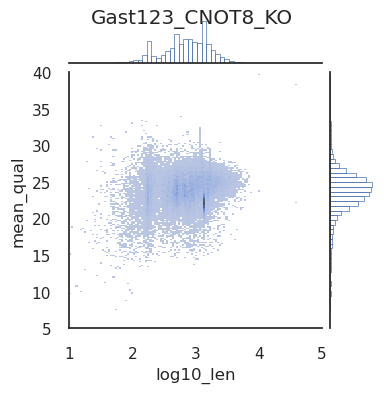

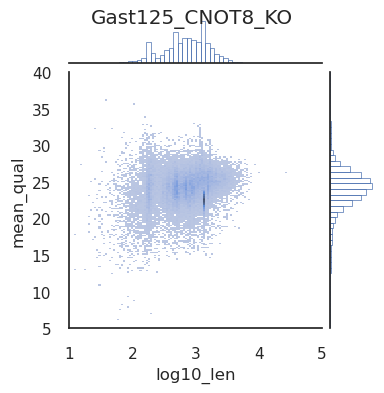

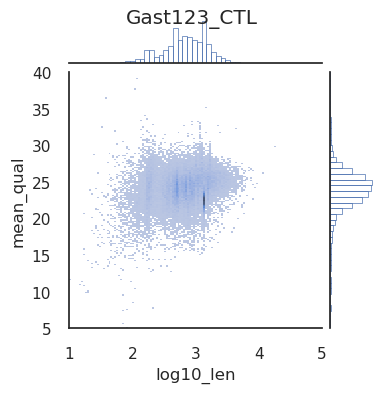

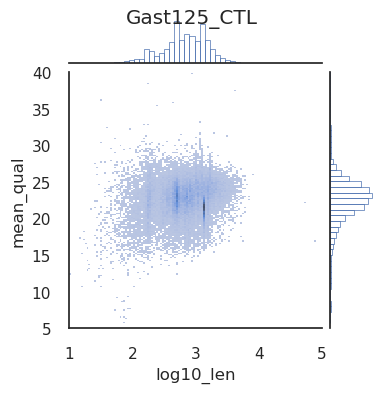

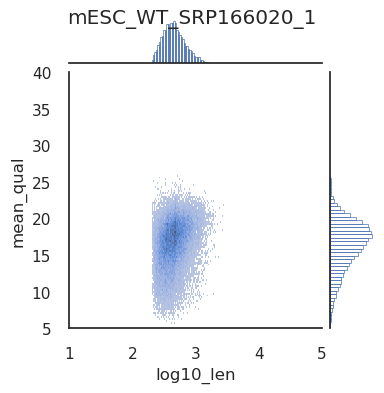

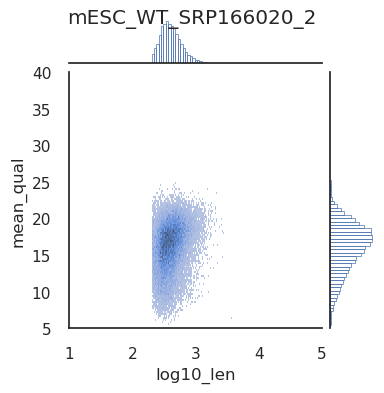

In [116]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]
sample_labels = ['Gast123_CNOT8_KO','Gast125_CNOT8_KO','Gast123_CTL','Gast125_CTL','mESC_WT_SRP166020_1','mESC_WT_SRP166020_2']
b=[]

figs_tmp_dir = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/tmp/'
figs_out_dir = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/'

out = subprocess.check_output('mkdir -p '+figs_tmp_dir+' '+figs_out_dir, shell=True)

fig_paths = []
i = 0
for sample in input_samples:
    seqQual_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.txt'
    seqQuals = pd.read_csv(seqQual_file,delimiter="\t",index_col=None,header=None,quoting=csv.QUOTE_NONE)
    ascii_anchor = 33
    a = []
    for elem in seqQuals.values:
        qual_string = elem[0]
        a.append([len(qual_string),np.mean([ord(c)-ascii_anchor for c in qual_string])])
    df = pd.DataFrame(a,columns=['len','mean_qual'])
    df['sample'] = sample_labels[i]
    df['log10_len'] = np.log10(df['len']+1)
    b.append(df)

    sns.set(font_scale=1)
    sns.set_style("white")
    g = sns.jointplot(data=df, x="log10_len", y="mean_qual",kind='hist',marginal_kws=dict(bins=50, fill=False, alpha=1),xlim=(1,5),ylim=(5,40),height=4, ratio=5,)
    
    g.fig.suptitle(sample_labels[i])
    fig_path = figs_tmp_dir+sample_labels[i]+'.png'
    g.savefig(fig_path,bbox_inches='tight',dpi=600)
    fig_paths.append(fig_path)
    print(str(sample_labels[i])+' done')
    i=i+1
df = pd.concat(b,axis=0)
df['sample'] = df['sample'].astype('category')

# arrange all figures horizontally
images = [Image.open(x) for x in fig_paths]
widths, heights = zip(*(i.size for i in images))

total_width = sum(widths)
max_height = max(heights)

new_im = Image.new('RGB', (total_width, max_height))

x_offset = 0
for im in images:
  new_im.paste(im, (x_offset,0))
  x_offset += im.size[0]

new_im.save(figs_out_dir+'readLength_vs_meanQual.png')

## get reverse complements of read, get first 300 nt of them, run FastqC on them

In [142]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]

command = ''
command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/; '
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/'+sample+'.fastq.gz'
    out_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.rc.fastq.gz'
    command = command+'seqkit sample -p 0.3 '+fastq_file+' | head -n 200000 | seqkit seq -m 300 -r -p | head -n 50000 | seqkit subseq -r 1:300 | seqkit seq --rna2dna | gzip > '+out_file+' & '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/; seqkit sample -p 0.3 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz | head -n 200000 | seqkit seq -m 300 -r -p | head -n 50000 | seqkit subseq -r 1:300 | seqkit seq --rna2dna | gzip > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc.fastq.gz & seqkit sample -p 0.3 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.fastq.gz | head -n 200000 | seqkit seq -m 300 -r -p | head -n 50000 | seqkit subseq -r 1:300 | seqkit seq --rna2dna | gzip > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.rc.fastq.gz & seqkit sample -p 0.3 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nano

In [143]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]

threads = 12

command = ''
command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/fastqc_on_reverse_complement/; '
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.rc.fastq.gz'
    out_dir = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/fastqc_on_reverse_complement/'
    command = command+'fastqc --outdir '+out_dir+' --threads '+str(threads)+' '+fastq_file+'; '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/fastqc_on_reverse_complement/; fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/fastqc_on_reverse_complement/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc.fastq.gz; fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/fastqc_on_reverse_complement/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.rc.fastq.gz; fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/custom_QC/nanopore/fastqc_on_reverse_complement/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1749_X3_FAZ60875_f215937e.pass.rc.fastq.gz; fastqc --outdir /scicor

## map with minimap2 first 300 nt of reverse complements

In [145]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]

command = ''
command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/; '
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/'+sample+'.fastq.gz'
    out_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.rc_full.fastq.gz'
    command = command+'seqkit seq -m 300 -r -p '+fastq_file+' | seqkit subseq -r 1:300 | seqkit seq --rna2dna | gzip > '+out_file+' & '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/; seqkit seq -m 300 -r -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz | seqkit subseq -r 1:300 | seqkit seq --rna2dna | gzip > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc_full.fastq.gz & seqkit seq -m 300 -r -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.fastq.gz | seqkit subseq -r 1:300 | seqkit seq --rna2dna | gzip > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.rc_full.fastq.gz & seqkit seq -m 300 -r -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X3_FAZ60875_f215937e.pass.fastq.gz | seqkit subseq -r 1:300 | seqkit seq --rna2d

In [148]:
genome_file = '/scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa'

threads = 12

input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]

command = ''
command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/; '
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.rc_full.fastq.gz'
    bam_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/'+sample+'.rc_300.minimap2.sorted.bam'
    command = command+'minimap2 -ax splice -L -k14 -secondary=no --sam-hit-only '+genome_file+' '+fastq_file+' | samtools sort -@ '+str(threads)+' -O bam > '+bam_file
    command = command+' && samtools index -@ '+str(threads)+' '+bam_file+'; '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/; minimap2 -ax splice -L -uf -k14 -secondary=no --sam-hit-only /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc_full.fastq.gz | samtools sort -@ 12 -O bam > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc_300.minimap2.sorted.bam && samtools index -@ 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc_300.minimap2.sorted.bam; minimap2 -ax splice -L -uf -k14 -secondary=no --sam-hit-only /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.rc_

## map with STAR first 300 nt of reverse complements

In [151]:
genome_file = '/scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa'
gtf_file = '/scicore/home/zavolan/GROUP/Genomes/mus_musculus/gencode.vM25.annotation.gtf'
star_index = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/STAR_index'

command = 'STAR \
--runMode genomeGenerate \
--sjdbOverhang 299 \
--genomeDir '+star_index+' \
--genomeFastaFiles '+genome_file+' \
--runThreadN 12 \
--sjdbGTFfile '+gtf_file
command

'STAR --runMode genomeGenerate --sjdbOverhang 299 --genomeDir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/STAR_index --genomeFastaFiles /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa --runThreadN 12 --sjdbGTFfile /scicore/home/zavolan/GROUP/Genomes/mus_musculus/gencode.vM25.annotation.gtf'

In [153]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b.pass',
'20240813_1749_X2_FAZ60547_f5851842.pass',
'20240813_1749_X3_FAZ60875_f215937e.pass',
'20240813_1749_X4_FAZ61052_010889e2.pass',
'SRR11550233',
'SRR11550261'
]

threads = 12

command = ''
command = command+'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/; '
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/'+sample+'.rc_full.fastq.gz'
    bam_prefix = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/'+sample+'.rc_300.star.'
    bam_file = bam_prefix+'Aligned.sortedByCoord.out.bam'
    command = command+'STAR \
--runMode alignReads \
--alignEndsType Local \
--runThreadN '+str(threads)+' \
--genomeDir '+star_index+' \
--readFilesIn '+fastq_file+' \
--readFilesCommand zcat \
--outFileNamePrefix '+bam_prefix+' \
--genomeLoad NoSharedMemory \
--outSAMtype BAM SortedByCoordinate \
--outFilterType BySJout \
--seedSearchStartLmax 20 \
--seedSearchStartLmaxOverLread 0.15 \
--outFilterMatchNmin 35 \
--outSJfilterOverhangMin 15 15 15 15 \
--alignSJDBoverhangMin 15 \
--alignSJoverhangMin 15 \
--outFilterMismatchNmax 15 \
--outFilterMismatchNoverReadLmax 1 \
--outFilterMatchNminOverLread 0 \
--outFilterScoreMinOverLread 0 \
--twopassMode None \
--outBAMsortingThreadN '+str(threads)+' \
--outFilterMultimapNmax 500000000 \
--outSAMattributes NH HI AS nM MD \
--limitOutSJcollapsed 5000000; '
    command = command+'samtools index -@ '+str(threads)+' '+bam_file+'; '
command

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/; STAR --runMode alignReads --alignEndsType Local --runThreadN 12 --genomeDir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/STAR_index --readFilesIn /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc_full.fastq.gz --readFilesCommand zcat --outFileNamePrefix /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.rc_300.star. --genomeLoad NoSharedMemory --outSAMtype BAM SortedByCoordinate --outFilterType BySJout --seedSearchStartLmax 20 --seedSearchStartLmaxOverLread 0.15 --outFilterMatchNmin 35 --outSJfilterOverhangMin 15 15 15 15 --alignSJDBoverhangMin 15 --alignSJoverhangMin 15 --outFilterMismatchNmax 15 --outFilterMismatchNoverReadLmax 1 --outFilterMatchNminOverLread 0 --outFilterScoreMinOverLread 0 --twopassMode None --outBAMsortingThrea

In [ ]:
-ax splice -k14 -uf -secondary=no --eqx --sam-hit-only

In [1]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b',
'20240813_1749_X2_FAZ60547_f5851842',
'20240813_1749_X3_FAZ60875_f215937e',
'20240813_1749_X4_FAZ61052_010889e2'
]

threads = 12

command = ''
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/'+sample+'.pass.fastq.gz'
    
    command = command+'fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads '+str(threads)+' '+fastq_file+' && '
command

'fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz && fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.fastq.gz && fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X3_FAZ60875_f215937e.pass.fastq.gz && fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X4_FAZ61052_010889e2.pass.fastq.gz && '

'mkdir -p /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/; seqkit sample -p 0.1 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz | seqkit head -n 10000 | seqkit seq -q > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.txt & seqkit sample -p 0.1 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.fastq.gz | seqkit head -n 10000 | seqkit seq -q > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/nanopore/20240813_1749_X2_FAZ60547_f5851842.txt & seqkit sample -p 0.1 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X3_FAZ60875_f215937e.pass.fastq.gz | seqkit head -n 10000 | seqkit seq -q > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastq_samples/na

In [30]:
fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/test.fastq.gz'
command = 'fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads '+str(threads)+' '+fastq_file
out_png_meanQual = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/seqkit/nanopore/test.meanQuals.png'
# command = 'seqkit watch -Q --fields MeanQual '+fastq_file+' -O '+out_png_meanQual
command

'fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/test.fastq.gz'

In [28]:
qual_str = "#')*((++&&-/22000ACCDF+*+-//41*&&$$%'1>A=ABCEIC574+,)1,DEEB@999456@@DAAL;AC<9;6573337<AB?<;<200018100&%%%++-:BB--.C;;=>DFFEGIHGCDKKJNHGA>2/'()<BBA@<6;<BEDHE?;A=3**+,)&#"
np.mean([ord(c)-33 for c in qual_str])

22.339285714285715

In [15]:
input_samples = [
'20240813_1724_X1_FAZ60491_8451cb8b',
'20240813_1749_X2_FAZ60547_f5851842',
'20240813_1749_X3_FAZ60875_f215937e',
'20240813_1749_X4_FAZ61052_010889e2'
]

threads = 12

command = ''
for sample in input_samples:
    fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/'+sample+'.pass.fastq.gz'
    out_png_lengths = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/seqkit/nanopore/'+sample+'.lengths.png'
    out_png_meanQual = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/seqkit/nanopore/'+sample+'.meanQuals.png'
    # command = command+'seqkit sample -p 0.1 '+fastq_file+' | seqkit head -n 30000 | seqkit watch -Q --log --fields ReadLen -O '+out_png_lengths+' & '
    command = command+'seqkit sample -p 0.1 '+fastq_file+' | seqkit head -n 30000 | seqkit watch -Q --fields MeanQual -O '+out_png_meanQual+' & '
command

'seqkit sample -p 0.1 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz | seqkit head -n 30000 | seqkit watch -Q -b 50 --fields MeanQual -O /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/seqkit/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.meanQuals.png & seqkit sample -p 0.1 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.fastq.gz | seqkit head -n 30000 | seqkit watch -Q -b 50 --fields MeanQual -O /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/seqkit/nanopore/20240813_1749_X2_FAZ60547_f5851842.meanQuals.png & seqkit sample -p 0.1 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X3_FAZ60875_f215937e.pass.fastq.gz | seqkit head -n 30000 | seqkit watch -Q -b 50 --fields MeanQual -O /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/seqkit/nanopore/20240813_174

In [1]:
genome_file = '/scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa'
fastq_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz'
bam_file = '/scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.sorted.bam'

threads = 12

command = 'minimap2 -ax splice -L -uf -k14 '+genome_file+' '+fastq_file+' | samtools sort -@ '+str(threads)+' -O bam > '+bam_file
command = command+' && samtools index -@ '+str(threads)+' '+bam_file
command

'minimap2 -ax splice -L -uf -k14 /scicore/home/zavolan/GROUP/Genomes/mus_musculus/GRCm38.primary_assembly.genome.fa /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.fastq.gz | samtools sort -@ 8 -O bam > /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.sorted.bam && samtools index -@ 8 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.sorted.bam'

In [ ]:
# samtools index /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.bam

In [ ]:
# fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/bam/nanopore/20240813_1724_X1_FAZ60491_8451cb8b.pass.sorted.bam

'fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X2_FAZ60547_f5851842.pass.fastq.gz && fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X3_FAZ60875_f215937e.pass.fastq.gz && fastqc --outdir /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/WF_output/fastqc/ --threads 12 /scicore/home/zavolan/GROUP/Regulation_of_gastrulation/input_fastq/nanopore/20240813_1749_X4_FAZ61052_010889e2.pass.fastq.gz && '

In [ ]:
1f4097c4-b8f0-4193-9f52-89902e830f81